### Genes analysis for fig 1

In [37]:
import glob, re
import os
import pandas as pd

ANNOT_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/annotate_censat_prajnas_list'

COL_NAMES = ['contig', 'source', 'feature', 'start', 'end',
             'score', 'strand', 'phase', 'attributes', 'contig2', 'overlap_bp', 'censat_annot']

def parse_attr(attr_str, key):
    m = re.search(rf'{key}=([^;]+)', attr_str)
    return m.group(1) if m else None

records = []
for path in glob.glob(f'{ANNOT_DIR}/*_censat_annot.tsv'):
    fname  = os.path.basename(path)
    m      = re.match(r'(.+?)_(hap\d+|mat|pat)_(chr\w+)_censat_annot\.tsv', fname)
    if not m: continue
    sample_id  = m.group(1)
    hap_raw    = m.group(2)
    chrom      = m.group(3)
    haplotype  = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')

    df = pd.read_csv(path, sep='\t', header=None, names=COL_NAMES, low_memory=False)
    df = df[df['feature'] == 'gene'].copy()

    df['sample_id']  = sample_id
    df['haplotype']  = haplotype
    df['chrom']      = chrom
    df['gene_name']  = df['attributes'].apply(lambda x: parse_attr(x, 'gene_name'))
    df['gene_biotype'] = df['attributes'].apply(lambda x: parse_attr(x, 'gene_biotype'))

    records.append(df[['sample_id', 'haplotype', 'chrom', 'contig',
                        'start', 'end', 'strand', 'gene_name', 'gene_biotype',
                        'censat_annot']])

annot_df = pd.concat(records, ignore_index=True)
annot_df['start'] = annot_df['start'].astype(int)
annot_df['end']   = annot_df['end'].astype(int)

print(annot_df.shape)
display(annot_df.head())


(170894, 10)


,sample_id,haplotype,chrom,contig,start,end,strand,gene_name,gene_biotype,censat_annot
0,HG03540,1,chr18,CM088058.1,14179394,14180956,+,FRG2LP,processed_pseudogene,ct(100.0%)
1,HG03540,1,chr18,CM088058.1,14194685,14199045,-,NF1P5,transcribed_processed_pseudogene,ct(100.0%)
2,HG03540,1,chr18,CM088058.1,14220598,14263255,+,ANKRD20A5P,lncRNA,ct(100.0%)
3,HG03540,1,chr18,CM088058.1,14221095,14286500,+,ANKRD20A5P,transcribed_unprocessed_pseudogene,ct(100.0%)
4,HG03540,1,chr18,CM088058.1,14232400,14232506,+,RNU6-316P,snRNA,ct(100.0%)


In [38]:
IG_TR = {"IG_V_gene", "IG_D_gene", "IG_J_gene", "IG_C_gene",
         "TR_V_gene", "TR_D_gene", "TR_J_gene", "TR_C_gene"}

def classify_biotype(b):
    if pd.isna(b):                                                   return "other"
    if b == "protein_coding" or b in IG_TR:                         return "protein-coding"
    if b == "lncRNA":                                                return "lncRNA"
    if b in ("snRNA", "snoRNA", "miRNA", "rRNA", "misc_RNA"):       return "other ncRNA"
    if "pseudogene" in b:                                            return "pseudogene"
    return "other"

annot_df["biotype_class"] = annot_df["gene_biotype"].apply(classify_biotype)

KEEP = {"protein-coding", "lncRNA", "other ncRNA"}
annot_filt = annot_df[annot_df["biotype_class"].isin(KEEP)].copy()

print(annot_filt["biotype_class"].value_counts())
print(f"\n{len(annot_filt):,} genes kept from {len(annot_df):,} total")


biotype_class
protein-coding    28580
lncRNA            17494
other ncRNA       13143
Name: count, dtype: int64

59,217 genes kept from 170,894 total


In [39]:
import re

def parse_dominant_annot(annot_str):
    """Extract the raw annotation name with the highest % overlap."""
    if pd.isna(annot_str) or annot_str == '.':
        return None
    hits = re.findall(r'([^;(]+)\(([0-9.]+)%\)', annot_str)
    if not hits:
        return None
    return max(hits, key=lambda x: float(x[1]))[0].strip()

def map_to_sat_category(raw):
    """Map raw BED annotation name to standardized SAT_ORDER category."""
    if raw is None:
        return "other"
    r = raw.lower()
    if   re.match(r'active_hor', raw, re.I):   return "active_hor"
    elif re.match(r'dhor',       raw, re.I):   return "dhor"
    elif re.match(r'hor',        raw, re.I):   return "hor"
    elif re.match(r'mixedalpha', raw, re.I):   return "mixedAlpha"
    elif re.match(r'mon',        raw, re.I):   return "mon"
    elif re.search(r'hsat1|hsat1', raw, re.I): return "HSAT1"
    elif re.search(r'hsat2|hsat2', raw, re.I): return "HSAT2"
    elif re.search(r'hsat3|hsat3', raw, re.I): return "HSAT3"
    elif re.search(r'hsat4',       raw, re.I): return "HSAT4"
    elif re.search(r'hsat5',       raw, re.I): return "HSAT5"
    elif re.match(r'bsat',         raw, re.I): return "bSat"
    elif re.match(r'gsat',         raw, re.I): return "gSat"
    elif re.match(r'ct',           raw, re.I): return "CT"
    elif re.search(r'satr',        raw, re.I): return "SATR"
    elif re.search(r'sst1',        raw, re.I): return "SST1"
    elif re.search(r'cer',         raw, re.I): return "CER"
    elif re.search(r'rdna|5srna',  raw, re.I): return "rDNA"
    elif re.search(r'acro',        raw, re.I): return "acrocentric"
    else:                                       return "other"

annot_filt["censat_category"] = (
    annot_filt["censat_annot"]
    .apply(parse_dominant_annot)
    .apply(map_to_sat_category)
)

print(annot_filt["censat_category"].value_counts())


censat_category
CT       53030
other     2041
SST1      1908
rDNA      1637
CER        256
mon        161
SATR       136
HSAT3       47
HSAT2        1
Name: count, dtype: int64


In [40]:
CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
TREE_DIR       = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'
GROUP_COLORS   = {"low": "#2171b5", "high": "#e6550d", None: "#cccccc"}

# ── shared setup (run once) ───────────────────────────────────────────────────
bed_map = {}
for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname   = os.path.basename(bed_path)
    parts   = fname.replace('.cenSat.bed', '').split('_')
    sid     = parts[0]
    hap_raw = parts[1]
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map[(sid, hap)] = bed_path

In [41]:
def load_censat(sample_id, haplotype, region):
    """Returns segments with start/end as Mbp offset from region start."""
    bed_path = bed_map.get((sample_id, haplotype))
    if bed_path is None: return []
    seq     = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows    = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x) / 255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({
                'start': (start - rs) / 1e6,
                'end':   (end   - rs) / 1e6,
                'color': color,
            })
    return rows

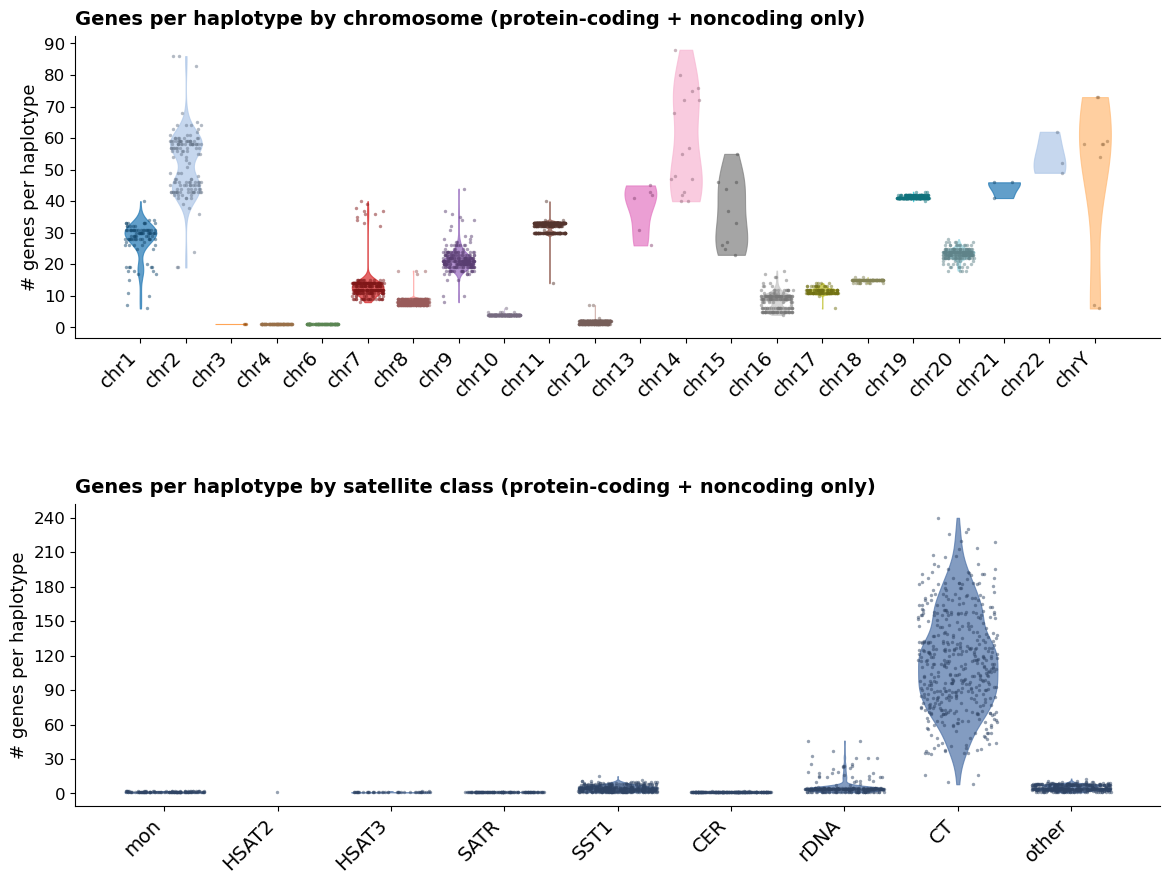

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import re

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
SAT_ORDER   = [
    "active_hor", "hor", "dhor", "mixedAlpha", "mon",
    "HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5",
    "bSat", "gSat", "SATR", "SST1", "CER",
    "rDNA", "acrocentric", "CT", "other",
]

per_hap_chrom = (
    annot_filt.groupby(["sample_id", "haplotype", "chrom"])
    .size().reset_index(name="count")
)
per_hap_sat = (
    annot_filt.groupby(["sample_id", "haplotype", "censat_category"])
    .size().reset_index(name="count")
)

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title, color_map=None, default_color="#4E72A7"):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)
        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid, rotation=45, ha="right", fontsize=14)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

np.random.seed(42)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.55})

make_violin_panel(axes[0], per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (protein-coding + noncoding only)",
                  color_map=chrom_colors)
make_violin_panel(axes[1], per_hap_sat, "censat_category", SAT_ORDER,
                  "Genes per haplotype by satellite class (protein-coding + noncoding only)")

plt.show()


In [43]:
### filter CT genes on the periphery of the array 

In [44]:
import glob
import pandas as pd

CENSAT_TSV_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'
FLANK_BP = 500_000   # define "periphery" as within this distance of array edge

# load array boundaries
all_tsvs = glob.glob(f'{CENSAT_TSV_DIR}/censat_regions_pass_qc_chr*.tsv')
regions_df = pd.concat([pd.read_csv(f, sep='\t') for f in all_tsvs], ignore_index=True)
regions_df = regions_df[regions_df['pass_qc'] == True][
    ['sample_id', 'haplotype', 'chrom_assignment', 'sequence_id', 'region_start', 'region_end', 'pass_qc']
].rename(columns={'chrom_assignment': 'chrom'})
regions_df['haplotype'] = regions_df['haplotype'].astype(str)


# merge array boundaries into annot_filt
merged = annot_filt.merge(regions_df, on=['sample_id', 'haplotype', 'chrom'], how='left')

# for CT genes, flag those within FLANK_BP of either array edge
merged['dist_to_edge'] = merged[['region_start', 'region_end', 'start', 'end']].apply(
    lambda r: min(r['start'] - r['region_start'], r['region_end'] - r['end']),
    axis=1
)

peripheral_ct = (
    (merged['censat_category'] == 'CT') &
    (merged['dist_to_edge'] < FLANK_BP)
)

print(f"CT genes total:            {(merged['censat_category'] == 'CT').sum()}")
print(f"CT genes on periphery:     {peripheral_ct.sum()}")
print(f"CT genes non-peripheral:   {((merged['censat_category'] == 'CT') & ~peripheral_ct).sum()}")

annot_filt_clean = merged[~peripheral_ct].drop(columns=['region_start', 'region_end', 'dist_to_edge'])

print(f"\nRows before filter: {len(annot_filt):,}")
print(f"Rows after filter:  {len(annot_filt_clean):,}")


CT genes total:            53030
CT genes on periphery:     21924
CT genes non-peripheral:   31106

Rows before filter: 59,217
Rows after filter:  37,293


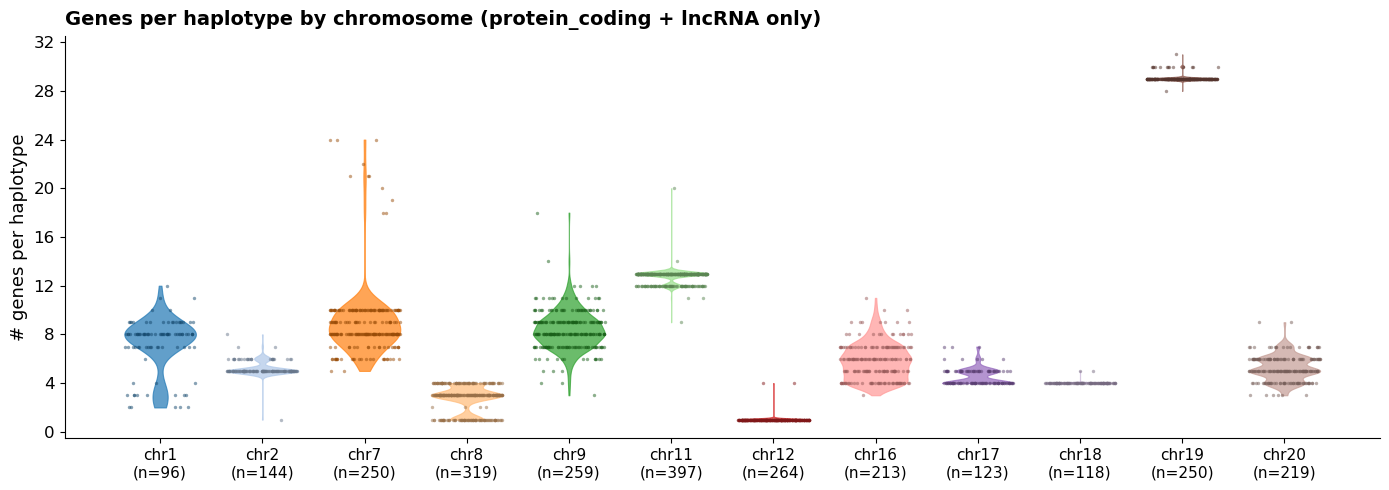

In [45]:
### REMOVED  snoRNAs, snRNAs, miscRNAs, IG genes and rDNAs, as well as chroms with less than 20 samples having any genes per hap


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

annot_pc_lnc = annot_filt_clean[
    annot_filt_clean["gene_biotype"].isin(["protein_coding", "lncRNA"])
].copy()

per_hap_chrom = (
    annot_pc_lnc.groupby(["sample_id", "haplotype", "chrom"])
    .size().reset_index(name="count")
)

chrom_n = per_hap_chrom.groupby("chrom").size()
CHROM_ORDER = [c for c in CHROM_ORDER if chrom_n.get(c, 0) >= 20]

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title, color_map=None, default_color="#4E72A7"):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)
        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)

    ax.set_xticks(range(len(valid)))
    xlabels = [f"{cat}\n(n={len(data[data[x_col]==cat])})" for cat in valid]
    ax.set_xticklabels(xlabels, rotation=0, ha="center", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

np.random.seed(42)
fig, ax = plt.subplots(figsize=(14, 5))

make_violin_panel(ax, per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (protein_coding + lncRNA only)",
                  color_map=chrom_colors)

plt.tight_layout()
plt.show()



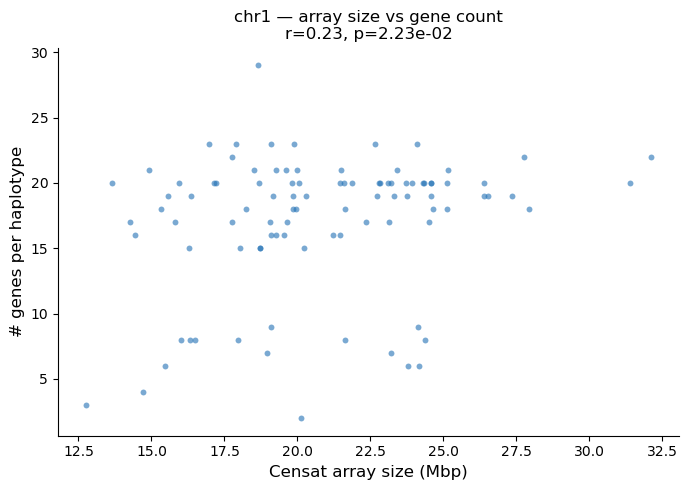

In [46]:
import scipy.stats as stats

# gene counts per haplotype for chr1
chr1_counts = (
    annot_filt_clean[annot_filt_clean["chrom"] == "chr1"]
    .groupby(["sample_id", "haplotype"])
    .size()
    .reset_index(name="n_genes")
)

# array sizes from regions_df
chr1_sizes = regions_df[regions_df["chrom"] == "chr1"][
    ["sample_id", "haplotype", "region_start", "region_end"]
].copy()
chr1_sizes["haplotype"]    = chr1_sizes["haplotype"].astype(str)
chr1_sizes["array_size_mbp"] = (chr1_sizes["region_end"] - chr1_sizes["region_start"]) / 1e6

# merge
plot_df = chr1_counts.merge(chr1_sizes, on=["sample_id", "haplotype"], how="inner")

# correlation
r, p = stats.pearsonr(plot_df["array_size_mbp"], plot_df["n_genes"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df["array_size_mbp"], plot_df["n_genes"],
           s=18, alpha=0.6, color="#2171b5", linewidths=0)

ax.set_xlabel("Censat array size (Mbp)", fontsize=12)
ax.set_ylabel("# genes per haplotype", fontsize=12)
ax.set_title(f"chr1 — array size vs gene count\nr={r:.2f}, p={p:.2e}", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [47]:
# print(chr1_counts.sort_values("n_genes", ascending=False).to_string(index=False))



In [48]:
chr1_genes = annot_filt_clean[annot_filt_clean["chrom"] == "chr1"]

low_haps  = chr1_counts[chr1_counts["n_genes"] <= 10][["sample_id", "haplotype"]]
high_haps = chr1_counts[chr1_counts["n_genes"] >= 15][["sample_id", "haplotype"]]

print(f"Low  (≤10 genes): {len(low_haps)} haplotypes")
print(f"High (≥15 genes): {len(high_haps)} haplotypes")

low_genes  = chr1_genes.merge(low_haps,  on=["sample_id", "haplotype"])
high_genes = chr1_genes.merge(high_haps, on=["sample_id", "haplotype"])

low_freq  = low_genes.groupby("gene_name")[["sample_id","haplotype"]].apply(
    lambda x: x.drop_duplicates().shape[0]).rename("n_low")
high_freq = high_genes.groupby("gene_name")[["sample_id","haplotype"]].apply(
    lambda x: x.drop_duplicates().shape[0]).rename("n_high")

gene_diff = pd.concat([high_freq, low_freq], axis=1).fillna(0).astype(int)
gene_diff["pct_high"] = 100 * gene_diff["n_high"] / len(high_haps)
gene_diff["pct_low"]  = 100 * gene_diff["n_low"]  / len(low_haps)
gene_diff["pct_diff"] = gene_diff["pct_high"] - gene_diff["pct_low"]

annot_cols = (chr1_genes[["gene_name", "gene_biotype", "censat_category"]]
              .drop_duplicates("gene_name"))
gene_diff  = gene_diff.merge(annot_cols, on="gene_name", how="left")

print(f"\nTotal genes on chr1: {len(gene_diff)}")

print("\nEnriched in HIGH group (pct_diff > 20):")
display(gene_diff[gene_diff["pct_diff"] > 20].sort_values("pct_diff", ascending=False))

print("\nEnriched in LOW group (pct_diff < -20):")
display(gene_diff[gene_diff["pct_diff"] < -20].sort_values("pct_diff"))

print("\nShared (|pct_diff| ≤ 20):")
display(gene_diff[gene_diff["pct_diff"].abs() <= 20].sort_values("pct_high", ascending=False))


Low  (≤10 genes): 16 haplotypes
High (≥15 genes): 80 haplotypes

Total genes on chr1: 41

Enriched in HIGH group (pct_diff > 20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
3,H3-7,79,0,98.75,0.00,98.75,protein_coding,CT
9,LINC02591,78,0,97.50,0.00,97.50,lncRNA,CT
33,RNVU1-23,78,0,97.50,0.00,97.50,snRNA,CT
23,RNU1-114P,78,0,97.50,0.00,97.50,snRNA,CT
24,RNU1-143P,78,0,97.50,0.00,97.50,snRNA,CT
39,Y_RNA,78,0,97.50,0.00,97.50,misc_RNA,CT
31,RNVU1-17,78,0,97.50,0.00,97.50,snRNA,CT
0,FAM72C,77,0,96.25,0.00,96.25,protein_coding,CT
32,RNVU1-18,72,0,90.00,0.00,90.00,snRNA,CT
20,RNA5SP529,67,1,83.75,6.25,77.50,rRNA,CT



Enriched in LOW group (pct_diff < -20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category



Shared (|pct_diff| ≤ 20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
10,LINC02799,80,16,100.00,100.00,0.00,lncRNA,CT
14,MIR4477A,55,11,68.75,68.75,0.00,miRNA,CT
15,MIR4477B,55,11,68.75,68.75,0.00,miRNA,CT
29,RNU2-42P,55,11,68.75,68.75,0.00,snRNA,CT
13,MIR1324,54,11,67.50,68.75,-1.25,miRNA,CT
2,FRG2C,48,10,60.00,62.50,-2.50,protein_coding,CT
16,MIR8078,29,5,36.25,31.25,5.00,miRNA,other
12,LSP1P5,13,0,16.25,0.00,16.25,lncRNA,CT
22,RNU1-1,4,0,5.00,0.00,5.00,snRNA,CT
35,RNVU1-28,3,0,3.75,0.00,3.75,snRNA,CT


In [49]:
chr1_all_haps = (
    chr1_counts[["sample_id", "haplotype"]]
    .drop_duplicates()
    .assign(key=1)
    .merge(
        chr1_genes[["gene_name"]].drop_duplicates().assign(key=1),
        on="key"
    ).drop(columns="key")
)
total_haps = len(chr1_counts)

# count copies per gene per haplotype
cn = (
    chr1_genes.groupby(["sample_id", "haplotype", "gene_name"])
    .size()
    .reset_index(name="copy_count")
)

# pivot: rows = haplotypes, cols = genes, fill absent = 0
cn_pivot = (
    cn.pivot_table(index=["sample_id", "haplotype"], columns="gene_name",
                   values="copy_count", fill_value=0)
    .reindex(pd.MultiIndex.from_frame(chr1_counts[["sample_id","haplotype"]]), fill_value=0)
)

n_present   = (cn_pivot > 0).sum(axis=0)
pct_present = 100 * n_present / total_haps
valid_genes = pct_present[pct_present >= 10].index

gene_stats = pd.DataFrame({
    "median_cn":      cn_pivot[valid_genes].median(axis=0),
    "variance":       cn_pivot[valid_genes].var(axis=0),
    "pct_haplotypes": pct_present[valid_genes],
}).reset_index().rename(columns={"gene_name": "gene_name"})

gene_stats = gene_stats.merge(
    chr1_genes[["gene_name","gene_biotype","censat_category"]].drop_duplicates("gene_name"),
    on="gene_name", how="left"
).sort_values("variance", ascending=False)

print(f"Genes in ≥10% of haplotypes: {len(gene_stats)}")
print(f"\nTop CN-variable genes (by variance):")
display(gene_stats.head(20))


Genes in ≥10% of haplotypes: 21

Top CN-variable genes (by variance):


,gene_name,median_cn,variance,pct_haplotypes,gene_biotype,censat_category
11,MIR8078,0.0,0.588487,35.416667,miRNA,other
5,LINC02799,3.0,0.502522,100.000000,lncRNA,CT
1,FRG2C,1.0,0.241667,60.416667,protein_coding,CT
6,LINC02802,0.0,0.239364,38.541667,lncRNA,CT
3,LINC01632,0.0,0.234101,36.458333,lncRNA,CT
8,MIR1324,1.0,0.220943,67.708333,miRNA,CT
10,MIR4477B,1.0,0.217105,68.750000,miRNA,CT
16,RNU2-42P,1.0,0.217105,68.750000,snRNA,CT
9,MIR4477A,1.0,0.217105,68.750000,miRNA,CT
12,RNA5SP529,1.0,0.208772,70.833333,rRNA,CT


Enriched genes to highlight: {'LINC01632', 'RNU1-143P', 'RNVU1-18', 'RNVU1-23', 'LINC02802', 'H3-7', 'RNA5SP533', 'Y_RNA', 'LINC02591', 'FAM72C', 'RNU1-114P', 'RNVU1-17', 'RNA5SP529'}


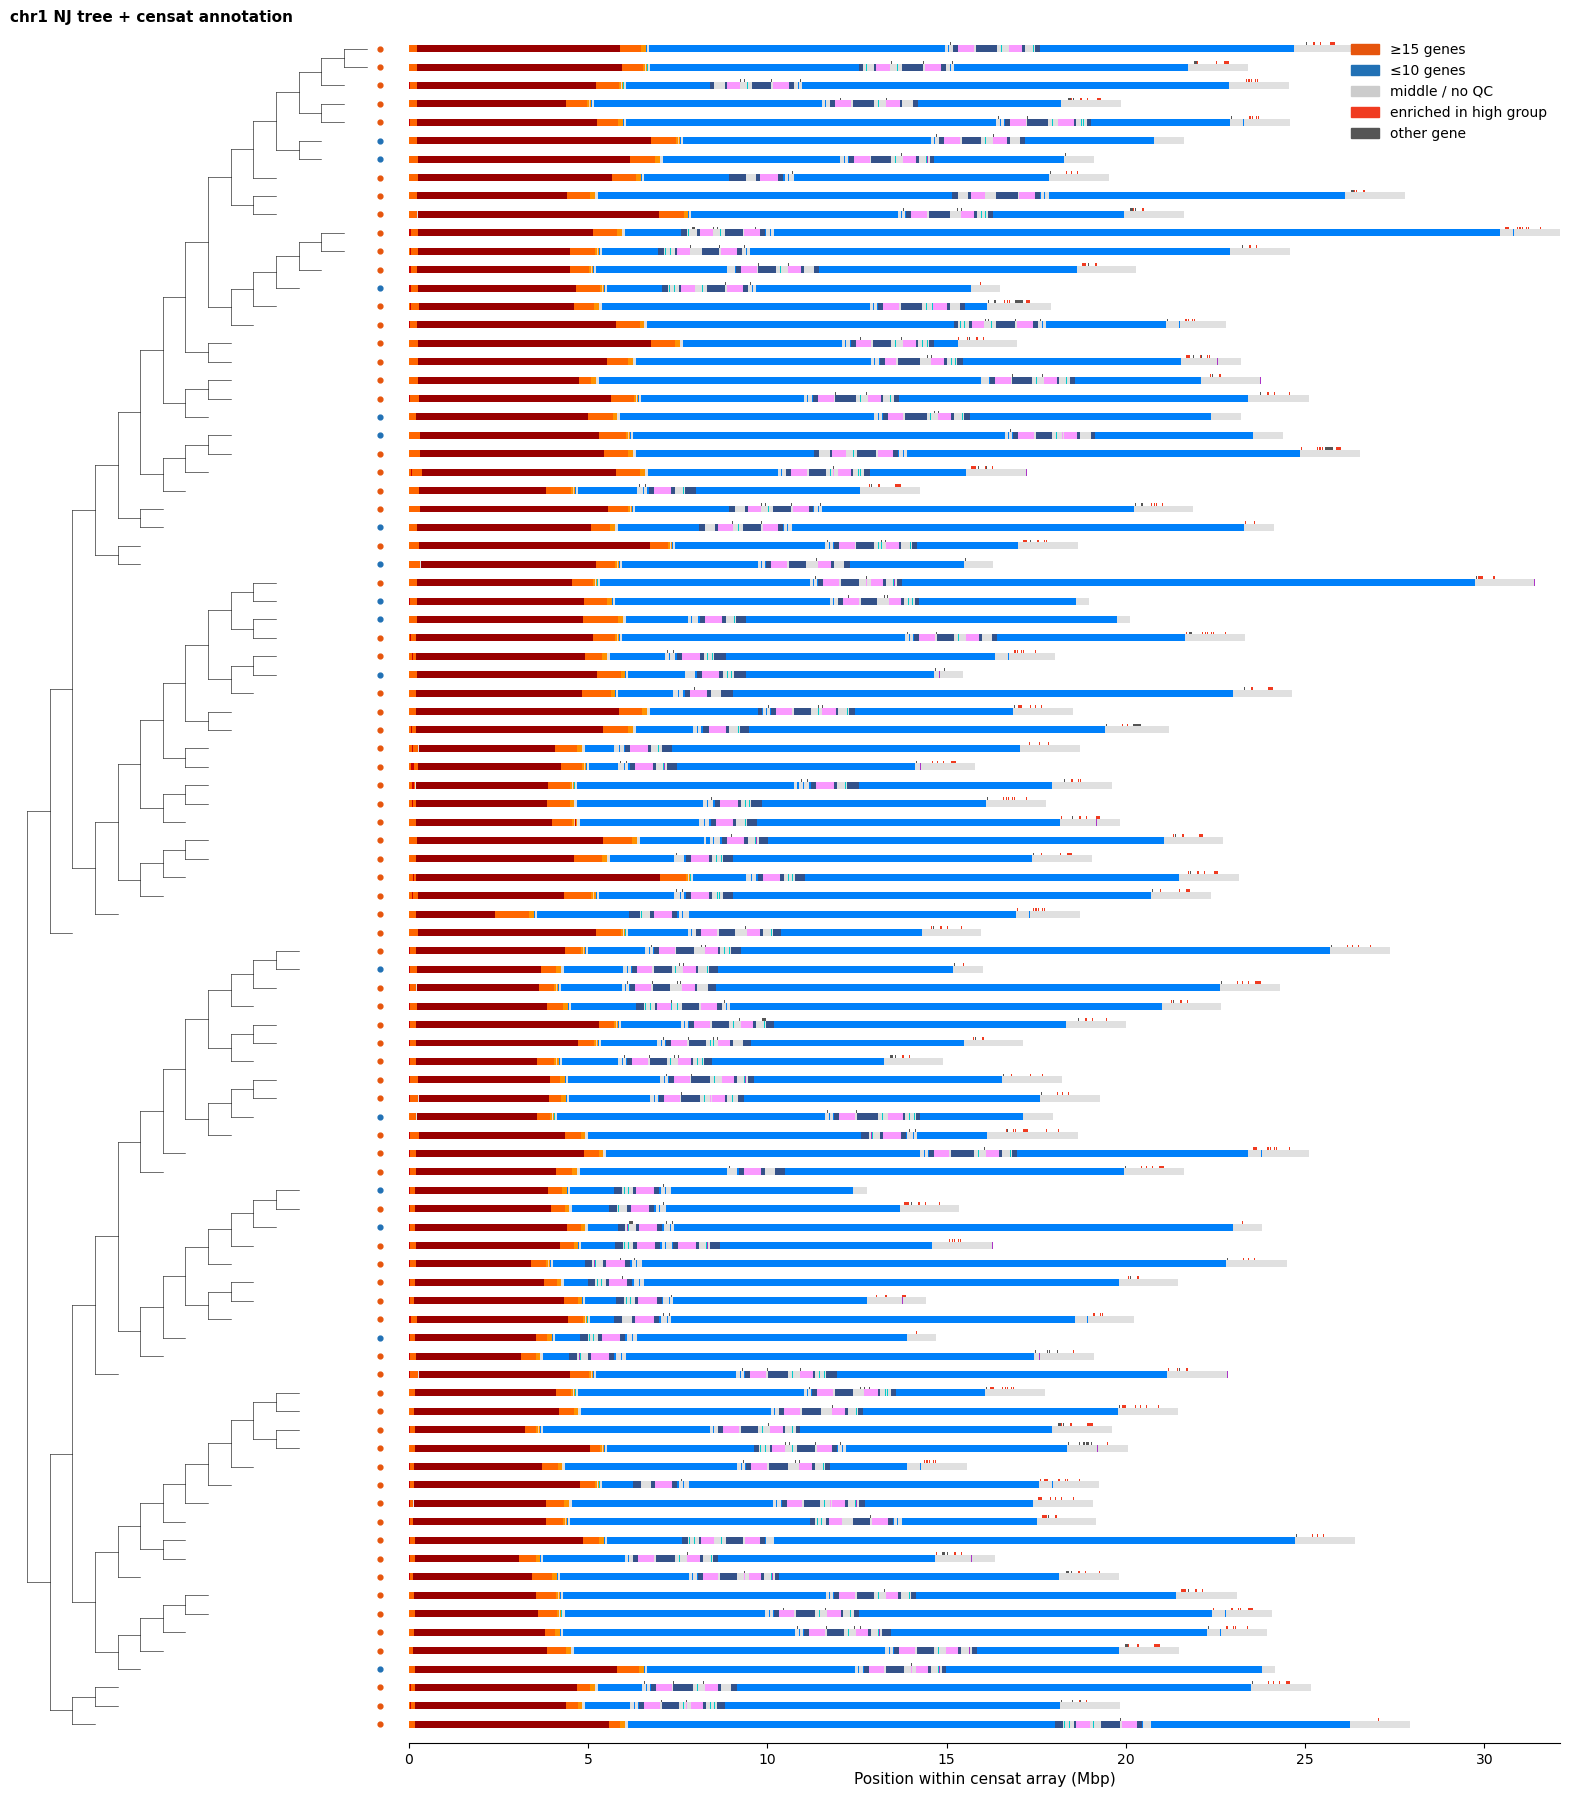

In [50]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from Bio import Phylo

def draw_cladogram(tree, ax):
    terminals = tree.get_terminals()
    clade_y   = {id(leaf): i for i, leaf in enumerate(terminals)}
    def assign_y(clade):
        if clade.is_terminal(): return clade_y[id(clade)]
        ys = [assign_y(c) for c in clade.clades]
        y  = sum(ys) / len(ys)
        clade_y[id(clade)] = y
        return y
    assign_y(tree.root)
    depths    = tree.depths(unit_branch_lengths=True)
    max_depth = max(depths.values())
    clade_x   = {id(c): depths[c] / max_depth for c in tree.find_clades()}
    for clade in tree.find_clades(order='level'):
        x = clade_x[id(clade)]
        y = clade_y[id(clade)]
        if clade.clades:
            child_ys = [clade_y[id(c)] for c in clade.clades]
            ax.plot([x, x], [min(child_ys), max(child_ys)], 'k-', lw=0.4)
            for child in clade.clades:
                ax.plot([x, clade_x[id(child)]], [clade_y[id(child)]] * 2, 'k-', lw=0.4)
    return {leaf.name: clade_y[id(leaf)] for leaf in terminals}

CHROM       = "chr1"
LOW_THRESH  = 10
HIGH_THRESH = 15
TREE_DIR    = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'
GROUP_COLORS = {"low": "#2171b5", "high": "#e6550d", None: "#cccccc"}
GENE_DEFAULT = "#555555"
GENE_ENRICHED = "#f03b20"   # red-orange for high-group enriched genes

# genes enriched in high group from earlier analysis
enriched_genes = set(
    gene_diff[gene_diff["pct_diff"] > 20]["gene_name"]
)
print(f"Enriched genes to highlight: {enriched_genes}")

# gene counts for grouping
chrom_counts = chr1_counts.copy()
chrom_counts["haplotype"] = chrom_counts["haplotype"].astype(str)
label_to_group = {}
for _, row in chrom_counts.iterrows():
    label = f"{row['sample_id']}.{row['haplotype']}"
    if   row["n_genes"] <= LOW_THRESH:  label_to_group[label] = "low"
    elif row["n_genes"] >= HIGH_THRESH: label_to_group[label] = "high"

# tree
tree_path = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
tree      = Phylo.read(tree_path, "newick")
qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chrom_counts.iterrows())
for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
    tree.prune(leaf)
tree.ladderize()

# regions — use full regions_df with sequence_id
chrom_regions = regions_df[
    (regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)
].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx    = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}
max_size_mbp  = (chrom_regions["region_end"] - chrom_regions["region_start"]).max() / 1e6

# genes from annot_filt_clean
chrom_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chrom_genes_df["haplotype"] = chrom_genes_df["haplotype"].astype(str)

terminals = tree.get_terminals()
n         = len(terminals)
ROW_H     = 0.22
CSAT_H    = 0.38
GENE_H    = 0.15
MIN_W_MBP = 0.01

fig = plt.figure(figsize=(20, n * ROW_H + 2))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.02)
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    grp      = label_to_group.get(leaf.name)
    ax_tree.scatter(1.04, yi, color=GROUP_COLORS.get(grp, GROUP_COLORS[None]),
                    s=12, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H / 2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    rs, re_  = region['region_start'], region['region_end']
    size_mbp = (re_ - rs) / 1e6
    genes    = chrom_genes_df[(chrom_genes_df['sample_id'] == sid) &
                               (chrom_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        g_start   = max(0, (g['start'] - rs) / 1e6)
        g_end     = min(size_mbp, (g['end'] - rs) / 1e6)
        gene_color = GENE_ENRICHED if g['gene_name'] in enriched_genes else GENE_DEFAULT
        ax_ann.add_patch(mpatches.Rectangle(
            (g_start, yi + CSAT_H / 2), max(g_end - g_start, MIN_W_MBP), GENE_H,
            color=gene_color, linewidth=0))

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [
    mpatches.Patch(color=GROUP_COLORS["high"],  label=f"≥{HIGH_THRESH} genes"),
    mpatches.Patch(color=GROUP_COLORS["low"],   label=f"≤{LOW_THRESH} genes"),
    mpatches.Patch(color=GROUP_COLORS[None],    label="middle / no QC"),
    mpatches.Patch(color=GENE_ENRICHED,         label="enriched in high group"),
    mpatches.Patch(color=GENE_DEFAULT,          label="other gene"),
]
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr1 NJ tree + censat annotation", fontsize=11, fontweight="bold", loc="left")
plt.show()


In [51]:
results = []

for chrom, chrom_df in annot_filt_clean.groupby("chrom"):
    # all haplotypes that have this chrom in the dataset
    hap_counts = (
        chrom_df.groupby(["sample_id", "haplotype"])
        .size().reset_index(name="n_genes")
    )
    total_haps = len(hap_counts)
    if total_haps < 5:
        continue

    # copy count per gene per haplotype
    cn = (
        chrom_df.groupby(["sample_id", "haplotype", "gene_name"])
        .size().reset_index(name="copy_count")
    )

    cn_pivot = (
        cn.pivot_table(index=["sample_id", "haplotype"], columns="gene_name",
                       values="copy_count", fill_value=0)
        .reindex(pd.MultiIndex.from_frame(hap_counts[["sample_id","haplotype"]]),
                 fill_value=0)
    )

    n_present   = (cn_pivot > 0).sum(axis=0)
    pct_present = 100 * n_present / total_haps
    valid       = pct_present[pct_present >= 10].index
    if len(valid) == 0:
        continue

    stats = pd.DataFrame({
        "chrom":          chrom,
        "median_cn":      cn_pivot[valid].median(axis=0),
        "variance":       cn_pivot[valid].var(axis=0),
        "pct_haplotypes": pct_present[valid],
    }).reset_index()

    results.append(stats)

cn_var_df = pd.concat(results, ignore_index=True)

# annotate with biotype and censat category
annot_cols = (
    annot_filt_clean[["gene_name", "gene_biotype", "censat_category"]]
    .drop_duplicates("gene_name")
)
cn_var_df = cn_var_df.merge(annot_cols, on="gene_name", how="left")

# top 3 per chrom by variance
top_per_chrom = (
    cn_var_df.sort_values("variance", ascending=False)
    .groupby("chrom")
    .head(3)
    .sort_values(["chrom", "variance"], ascending=[True, False])
)

import re
chrom_order = sorted(top_per_chrom["chrom"].unique(),
                     key=lambda c: int(re.search(r'\d+', c).group())
                                   if re.search(r'\d+', c) else 99)

print(f"Total genes analysed: {len(cn_var_df)}")
print(f"\nTop 3 CN-variable genes per chromosome (by variance):\n")
display(top_per_chrom.set_index("chrom").loc[chrom_order]
        [["gene_name","median_cn","variance","pct_haplotypes","gene_biotype","censat_category"]])


Total genes analysed: 331

Top 3 CN-variable genes per chromosome (by variance):



,gene_name,median_cn,variance,pct_haplotypes,gene_biotype,censat_category
chrom,,,,,,
chr1,MIR8078,0.0,0.588487,35.416667,miRNA,other
chr1,LINC02799,3.0,0.502522,100.000000,lncRNA,CT
chr1,FRG2C,1.0,0.241667,60.416667,protein_coding,CT
chr2,5S_rRNA,1.0,0.242230,59.722222,rRNA,CT
chr2,IGKV2-40,1.0,0.240822,60.416667,IG_V_gene,CT
chr2,RNA5SP533,1.0,0.234217,63.194444,rRNA,CT
chr7,LINC02799,4.0,1.080305,100.000000,lncRNA,CT
chr7,TTTY1,1.0,0.234554,62.800000,lncRNA,SST1
chr7,TTTY8,1.0,0.213992,69.200000,lncRNA,SST1


Max CN for LINC02799: 5
cn
1      1
2     14
3     86
4     31
5    118
Name: count, dtype: int64


/data/tmp/ipykernel_240334/649696832.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", max_cn)


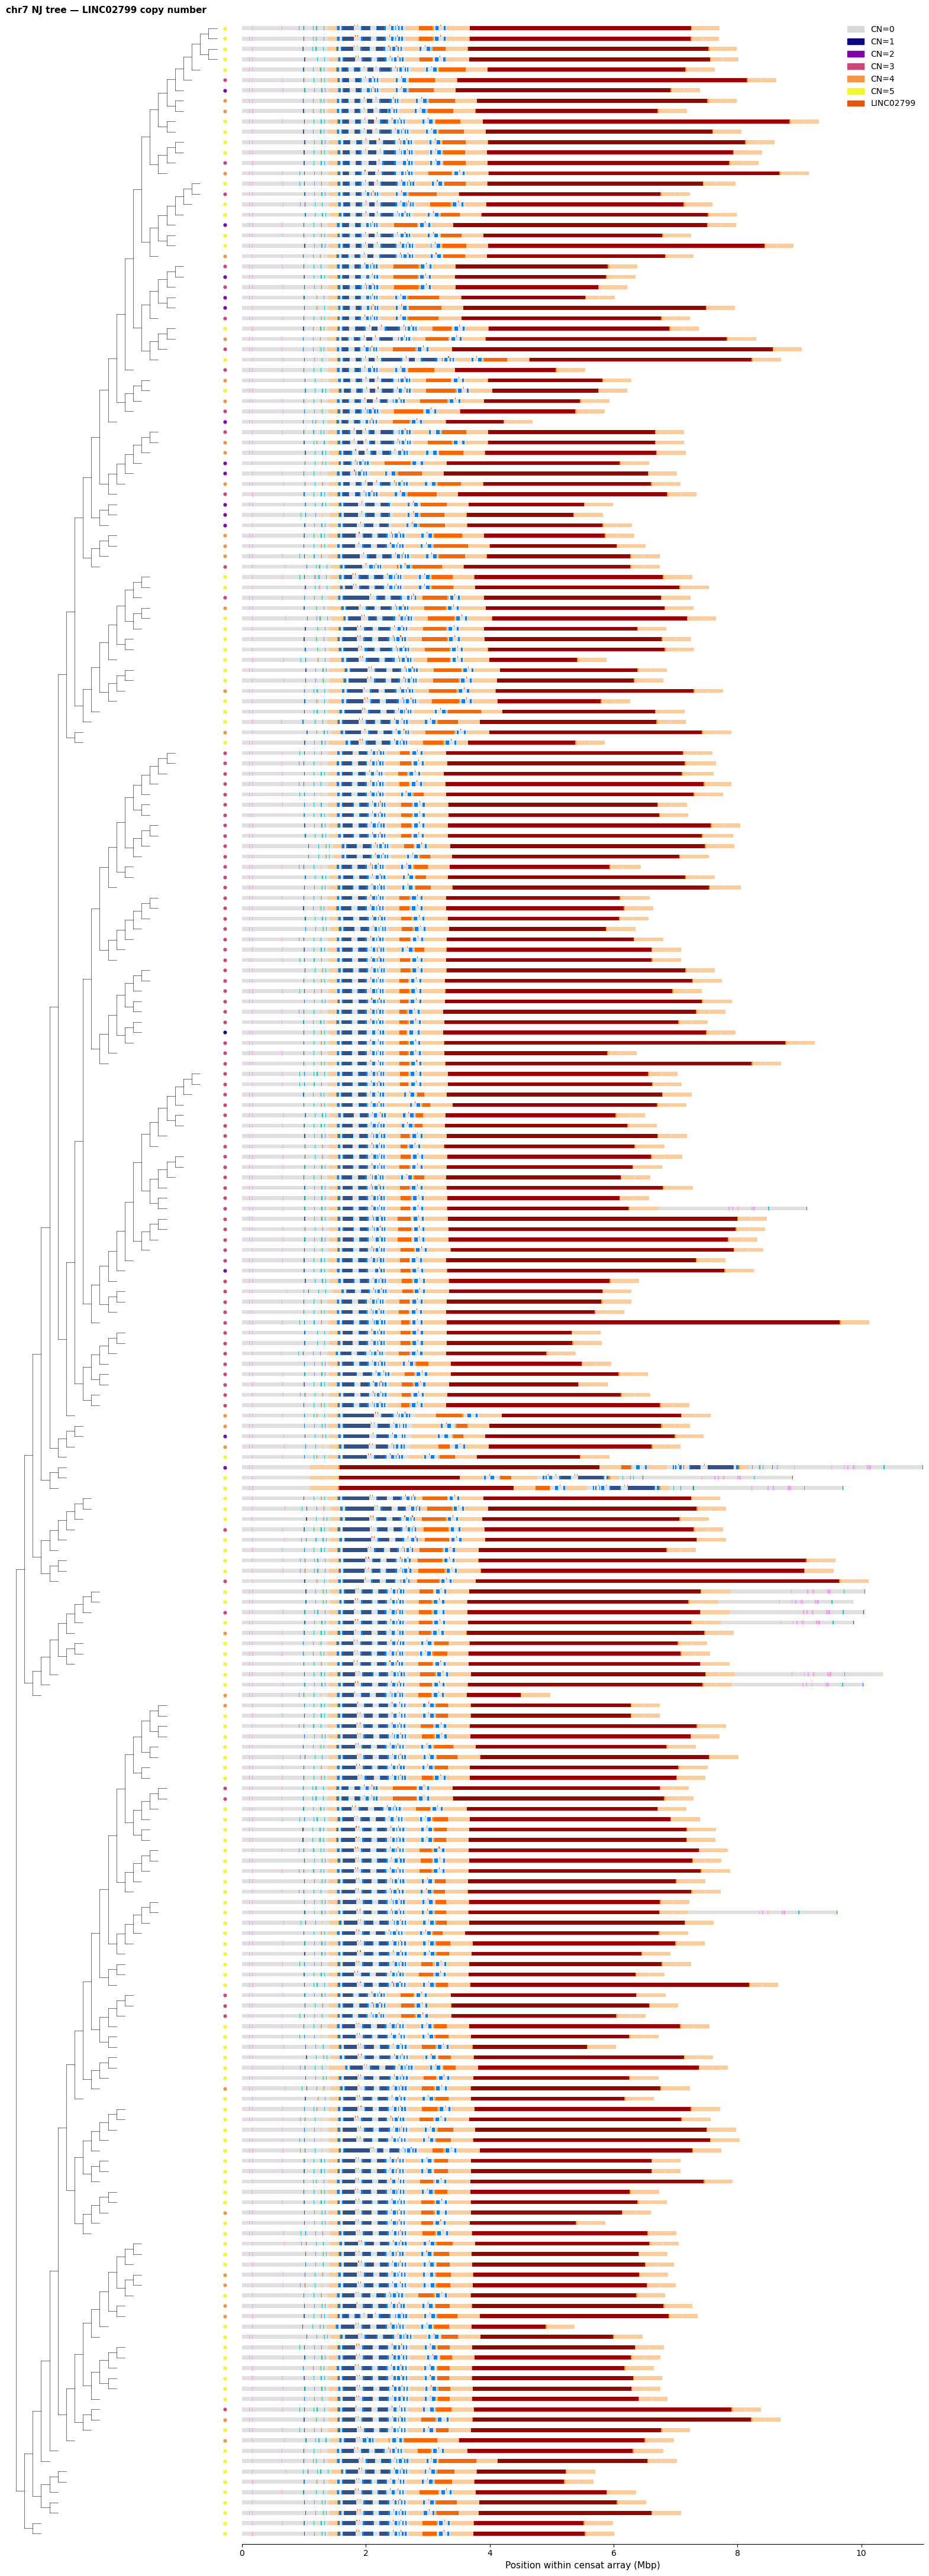

In [52]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from Bio import Phylo

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6550d"
TREE_DIR   = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'

# ── copy number of FOCUS_GENE per haplotype ───────────────────────────────────
chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = (
    annot_filt_clean[annot_filt_clean["chrom"] == CHROM]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="n")
)
chr7_hap_counts["haplotype"] = chr7_hap_counts["haplotype"].astype(str)

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = (chr7_hap_counts[["sample_id","haplotype"]]
            .merge(focus_cn, on=["sample_id","haplotype"], how="left"))
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

max_cn = focus_cn["cn"].max()
print(f"Max CN for {FOCUS_GENE}: {max_cn}")
print(focus_cn["cn"].value_counts().sort_index())

# discrete colormap: gray for 0, plasma for 1..max_cn
cmap = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap(i - 1))

focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"]
                for _, r in focus_cn.iterrows()}

# ── tree ──────────────────────────────────────────────────────────────────────
tree_path = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
tree      = Phylo.read(tree_path, "newick")
qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chr7_hap_counts.iterrows())
for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
    tree.prune(leaf)
tree.ladderize()

# ── regions ───────────────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx   = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}
max_size_mbp = (chrom_regions["region_end"] - chrom_regions["region_start"]).max() / 1e6

# ── plot ──────────────────────────────────────────────────────────────────────
terminals = tree.get_terminals()
n         = len(terminals)
ROW_H = 0.22;  CSAT_H = 0.38;  GENE_H = 0.15;  MIN_W_MBP = 0.01

fig = plt.figure(figsize=(20, n * ROW_H + 2))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.02)
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    cn_val   = focus_cn_map.get(leaf.name, 0)
    ax_tree.scatter(1.04, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                    s=12, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    rs, re_  = region['region_start'], region['region_end']
    size_mbp = (re_ - rs) / 1e6
    genes    = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                              (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE:
            continue
        g_start = max(0, (g['start'] - rs) / 1e6)
        g_end   = min(size_mbp, (g['end'] - rs) / 1e6)
        ax_ann.add_patch(mpatches.Rectangle(
            (g_start, yi + CSAT_H/2), max(g_end - g_start, MIN_W_MBP), GENE_H,
            color=GENE_FOCUS, linewidth=0))

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top','right','left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}")
           for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr7 NJ tree — {FOCUS_GENE} copy number", fontsize=11,
                  fontweight="bold", loc="left")
plt.show()



Max CN for LINC02799: 5
cn
1      1
2     14
3     86
4     31
5    118
Name: count, dtype: int64


/data/tmp/ipykernel_240334/3882549723.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", max_cn)


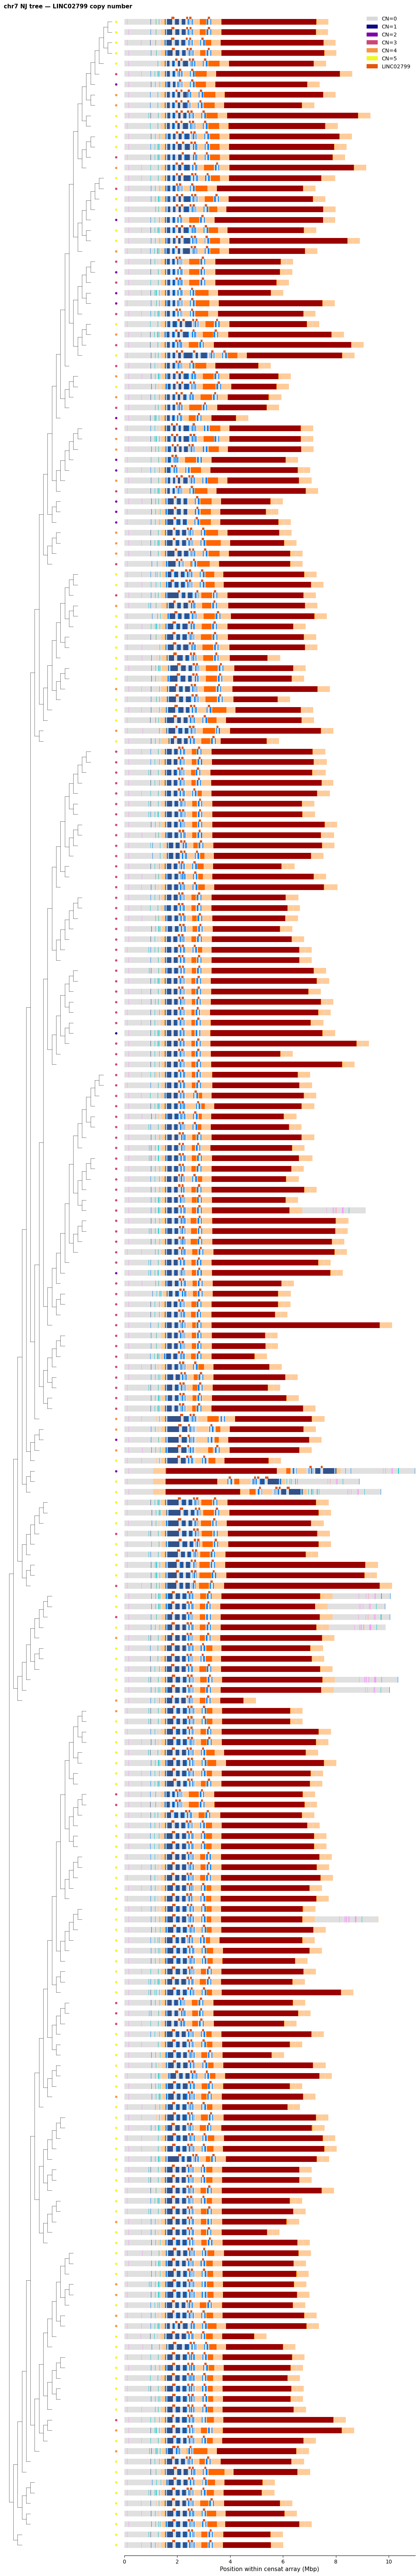

In [53]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from Bio import Phylo

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6550d"
TREE_DIR   = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'

# ── copy number of FOCUS_GENE per haplotype ───────────────────────────────────
chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = (
    annot_filt_clean[annot_filt_clean["chrom"] == CHROM]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="n")
)
chr7_hap_counts["haplotype"] = chr7_hap_counts["haplotype"].astype(str)

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = (chr7_hap_counts[["sample_id","haplotype"]]
            .merge(focus_cn, on=["sample_id","haplotype"], how="left"))
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

max_cn = focus_cn["cn"].max()
print(f"Max CN for {FOCUS_GENE}: {max_cn}")
print(focus_cn["cn"].value_counts().sort_index())

# discrete colormap: gray for 0, plasma for 1..max_cn
cmap = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap(i - 1))

focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"]
                for _, r in focus_cn.iterrows()}

# ── tree ──────────────────────────────────────────────────────────────────────
tree_path = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
tree      = Phylo.read(tree_path, "newick")
qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chr7_hap_counts.iterrows())
for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
    tree.prune(leaf)
tree.ladderize()

# ── regions ───────────────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx   = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}
max_size_mbp = (chrom_regions["region_end"] - chrom_regions["region_start"]).max() / 1e6

# ── plot ──────────────────────────────────────────────────────────────────────
terminals = tree.get_terminals()
n         = len(terminals)
ROW_H = 0.35   # was 0.22 — more vertical space per haplotype
CSAT_H = 0.55  # was 0.38 — thicker censat bars
GENE_H = 0.22  # was 0.15 — thicker gene bars
GENE_H = 0.22
GENE_W = 0.08  # fixed width in Mbp for gene markers


fig = plt.figure(figsize=(14, n * ROW_H + 2))  # was (20, ...) — narrower
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], wspace=0.02)  # was [1, 3]
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    cn_val   = focus_cn_map.get(leaf.name, 0)
    ax_tree.scatter(1.04, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                    s=12, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    rs, re_  = region['region_start'], region['region_end']
    size_mbp = (re_ - rs) / 1e6
    genes    = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                              (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE:
            continue
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.add_patch(mpatches.Rectangle(
            (g_mid - GENE_W/2, yi + CSAT_H/2), GENE_W, GENE_H,
            color=GENE_FOCUS, linewidth=0))


ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top','right','left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}")
           for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr7 NJ tree — {FOCUS_GENE} copy number", fontsize=11,
                  fontweight="bold", loc="left")
plt.show()



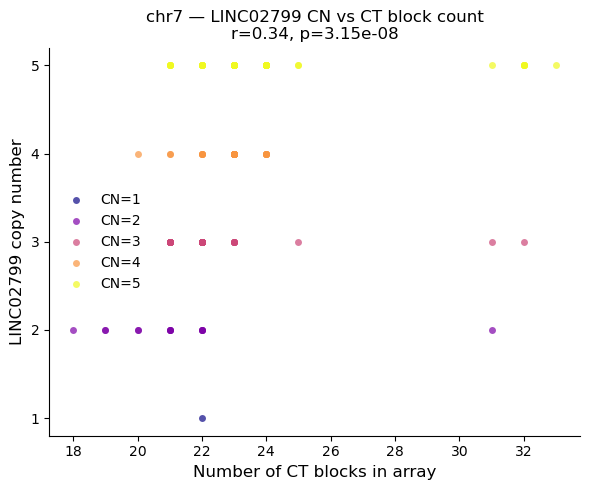

    count       mean       std   min   25%   50%   75%   max
cn                                                          
1     1.0  22.000000       NaN  22.0  22.0  22.0  22.0  22.0
2    14.0  21.357143  3.053551  18.0  20.0  21.0  22.0  31.0
3    86.0  22.186047  1.560631  21.0  22.0  22.0  22.0  32.0
4    31.0  22.838710  0.969425  20.0  22.5  23.0  23.0  24.0
5   118.0  23.601695  2.379183  21.0  23.0  23.0  23.0  33.0


In [54]:
# count CT blocks per haplotype from censat BED
ct_counts = []
for _, row in chrom_regions.iterrows():
    sid, hap = row["sample_id"], row["haplotype"]
    segs = load_censat(sid, hap, row)
    # segs have color but not annotation — need to reload with annot
    bed_path = bed_map.get((sid, hap))
    if bed_path is None: continue
    seq     = row['sequence_id'].split('#')[-1]
    rs, re_ = row['region_start'], row['region_end']
    n_ct = 0
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            if re.match(r'^ct', cols[3], re.I):
                n_ct += 1
    ct_counts.append({"sample_id": sid, "haplotype": hap, "n_ct_blocks": n_ct})

ct_df = pd.DataFrame(ct_counts)

# merge with LINC02799 CN
plot_df = focus_cn.merge(ct_df, on=["sample_id", "haplotype"], how="inner")

import scipy.stats as stats
r, p = stats.pearsonr(plot_df["n_ct_blocks"], plot_df["cn"])

fig, ax = plt.subplots(figsize=(6, 5))

for cn_val, grp in plot_df.groupby("cn"):
    ax.scatter(grp["n_ct_blocks"], grp["cn"],
               color=cn_palette.get(cn_val, "#aaaaaa"),
               s=25, alpha=0.7, linewidths=0, label=f"CN={cn_val}", zorder=3)

ax.set_xlabel("Number of CT blocks in array", fontsize=12)
ax.set_ylabel(f"{FOCUS_GENE} copy number", fontsize=12)
ax.set_title(f"chr7 — {FOCUS_GENE} CN vs CT block count\nr={r:.2f}, p={p:.2e}", fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(plot_df.groupby("cn")["n_ct_blocks"].describe())


/data/tmp/ipykernel_240334/2823316895.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", max_cn)
/data/tmp/ipykernel_240334/2823316895.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(2, len(g)), random_state=42))
/data/tmp/ipykernel_240334/2823316895.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


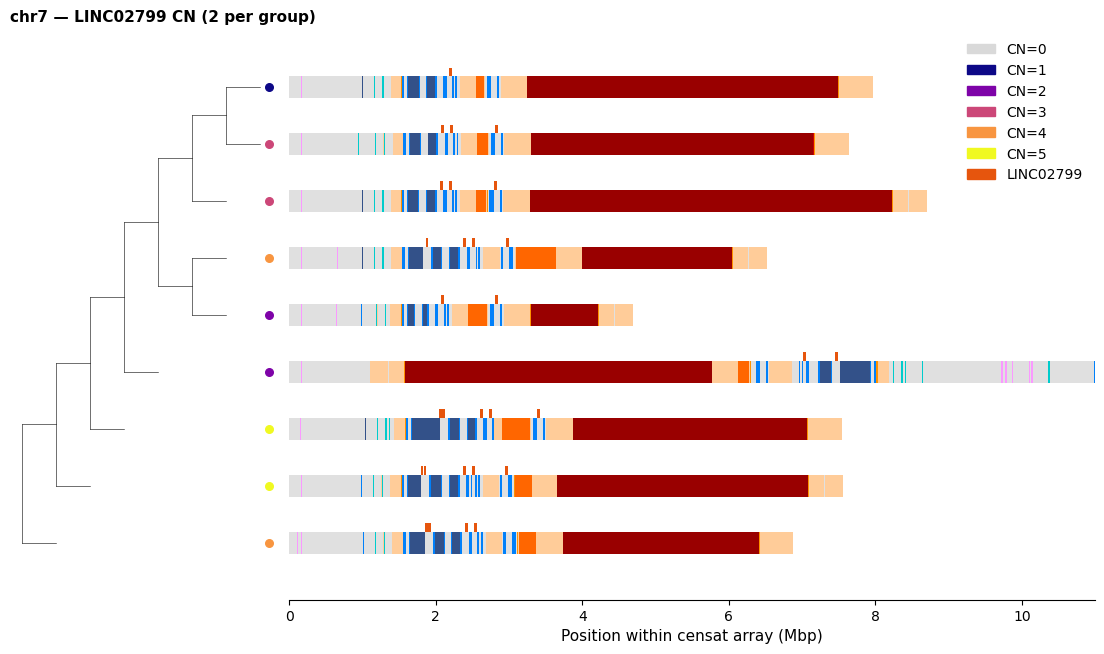

In [55]:
import random

import sys, os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from Bio import Phylo

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6550d"
TREE_DIR   = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'

chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = (
    chr7_genes_df.groupby(["sample_id", "haplotype"]).size().reset_index(name="n")
)

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

max_cn = focus_cn["cn"].max()
cmap = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap(i - 1))

focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

tree_path    = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx   = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}
max_size_mbp = (chrom_regions["region_end"] - chrom_regions["region_start"]).max() / 1e6


# ── sample 2 per CN group, prune tree to those leaves ────────────────────────
sampled = (
    focus_cn.groupby("cn", group_keys=False)
    .apply(lambda g: g.sample(min(2, len(g)), random_state=42))
    .reset_index(drop=True)
)
sampled_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in sampled.iterrows())

tree_sub = Phylo.read(tree_path, "newick")
for leaf in [l for l in tree_sub.get_terminals() if l.name not in sampled_labels]:
    tree_sub.prune(leaf)
tree_sub.ladderize()

# ── plot (identical to full-tree version, just swap tree → tree_sub) ──────────
terminals = tree_sub.get_terminals()
n         = len(terminals)
CSAT_H = 0.38;  GENE_H = 0.15;  GENE_W = 0.04


fig = plt.figure(figsize=(14, n * 0.6 + 2))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.02)
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree_sub, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    cn_val   = focus_cn_map.get(leaf.name, 0)
    ax_tree.scatter(1.04, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                    s=30, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    rs, re_  = region['region_start'], region['region_end']
    size_mbp = (re_ - rs) / 1e6
    genes    = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                              (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE: continue
        if g['end'] < rs or g['start'] > re_: continue
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.add_patch(mpatches.Rectangle(
            (g_mid - GENE_W/2, yi + CSAT_H/2), GENE_W, GENE_H,
            color=GENE_FOCUS, linewidth=0))


ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top','right','left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}")
           for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr7 — {FOCUS_GENE} CN (2 per group)", fontsize=11,
                  fontweight="bold", loc="left")
plt.tight_layout()
plt.show()



/data/tmp/ipykernel_240334/468786161.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", max_cn)
/data/tmp/ipykernel_240334/468786161.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(2, len(g)), random_state=42))
/data/tmp/ipykernel_240334/468786161.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


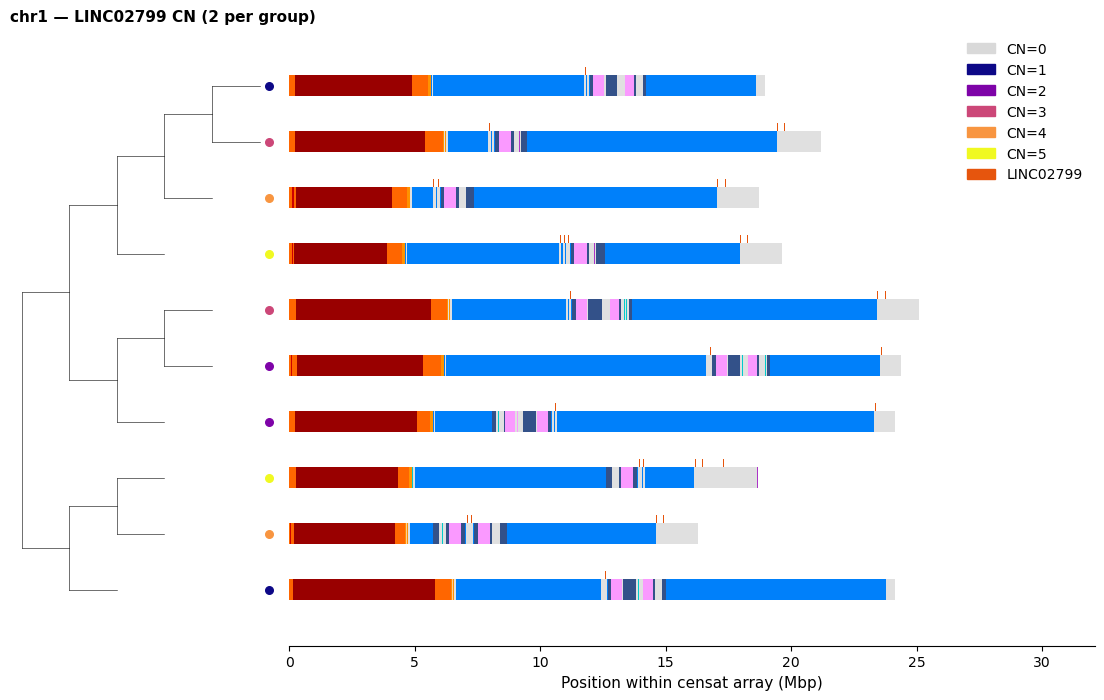

In [56]:
import random

import sys, os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from Bio import Phylo

CHROM      = "chr1"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6550d"
TREE_DIR   = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'

chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = (
    chr7_genes_df.groupby(["sample_id", "haplotype"]).size().reset_index(name="n")
)

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

max_cn = focus_cn["cn"].max()
cmap = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap(i - 1))

focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

tree_path    = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx   = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}
max_size_mbp = (chrom_regions["region_end"] - chrom_regions["region_start"]).max() / 1e6


# ── sample 2 per CN group, prune tree to those leaves ────────────────────────
sampled = (
    focus_cn.groupby("cn", group_keys=False)
    .apply(lambda g: g.sample(min(2, len(g)), random_state=42))
    .reset_index(drop=True)
)
sampled_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in sampled.iterrows())

tree_sub = Phylo.read(tree_path, "newick")
for leaf in [l for l in tree_sub.get_terminals() if l.name not in sampled_labels]:
    tree_sub.prune(leaf)
tree_sub.ladderize()

# ── plot (identical to full-tree version, just swap tree → tree_sub) ──────────
terminals = tree_sub.get_terminals()
n         = len(terminals)
CSAT_H = 0.38;  GENE_H = 0.15;  GENE_W = 0.04


fig = plt.figure(figsize=(14, n * 0.6 + 2))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.02)
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree_sub, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    cn_val   = focus_cn_map.get(leaf.name, 0)
    ax_tree.scatter(1.04, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                    s=30, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    rs, re_  = region['region_start'], region['region_end']
    size_mbp = (re_ - rs) / 1e6
    genes    = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                              (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE: continue
        if g['end'] < rs or g['start'] > re_: continue
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.add_patch(mpatches.Rectangle(
            (g_mid - GENE_W/2, yi + CSAT_H/2), GENE_W, GENE_H,
            color=GENE_FOCUS, linewidth=0))


ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top','right','left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}")
           for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr1 — {FOCUS_GENE} CN (2 per group)", fontsize=11,
                  fontweight="bold", loc="left")
plt.tight_layout()
plt.show()



In [57]:
print(f"{'Label':<20} {'CN':>4} {'genes_in_df':>12} {'region':>8} {'gene_in_region':>15}")
for _, row in sampled.iterrows():
    sid, hap, cn = row['sample_id'], row['haplotype'], row['cn']
    label = f"{sid}.{hap}"

    gene_rows = chr7_genes_df[
        (chr7_genes_df['sample_id'] == sid) &
        (chr7_genes_df['haplotype'] == hap) &
        (chr7_genes_df['gene_name'] == FOCUS_GENE)
    ]
    region = region_idx.get((sid, hap))
    region_found = region is not None

    if region_found and len(gene_rows) > 0:
        rs, re_ = region['region_start'], region['region_end']
        in_region = any(not (g['end'] < rs or g['start'] > re_)
                        for _, g in gene_rows.iterrows())
    else:
        in_region = False

    print(f"{label:<20} {cn:>4} {len(gene_rows):>12} {'yes' if region_found else 'MISS':>8} {str(in_region):>15}")

    if not region_found:
        alt_haps = regions_df[regions_df['sample_id'] == sid]['haplotype'].unique()
        print(f"  → regions_df has haplotypes: {alt_haps}")


Label                  CN  genes_in_df   region  gene_in_region
NA18879.1               1            1      yes            True
HG02056.2               1            1      yes            True
HG02258.1               2            2      yes            True
HG00344.2               2            2      yes            True
HG00097.1               3            3      yes            True
HG00438.2               3            3      yes            True
HG00320.2               4            4      yes            True
HG04157.2               4            4      yes            True
HG00621.1               5            5      yes            True
HG00350.1               5            5      yes            True


Max CN for LINC02799: 5
cn
1     2
2    11
3    59
4    22
5     2
Name: count, dtype: int64


/data/tmp/ipykernel_240334/168272128.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", max_cn)


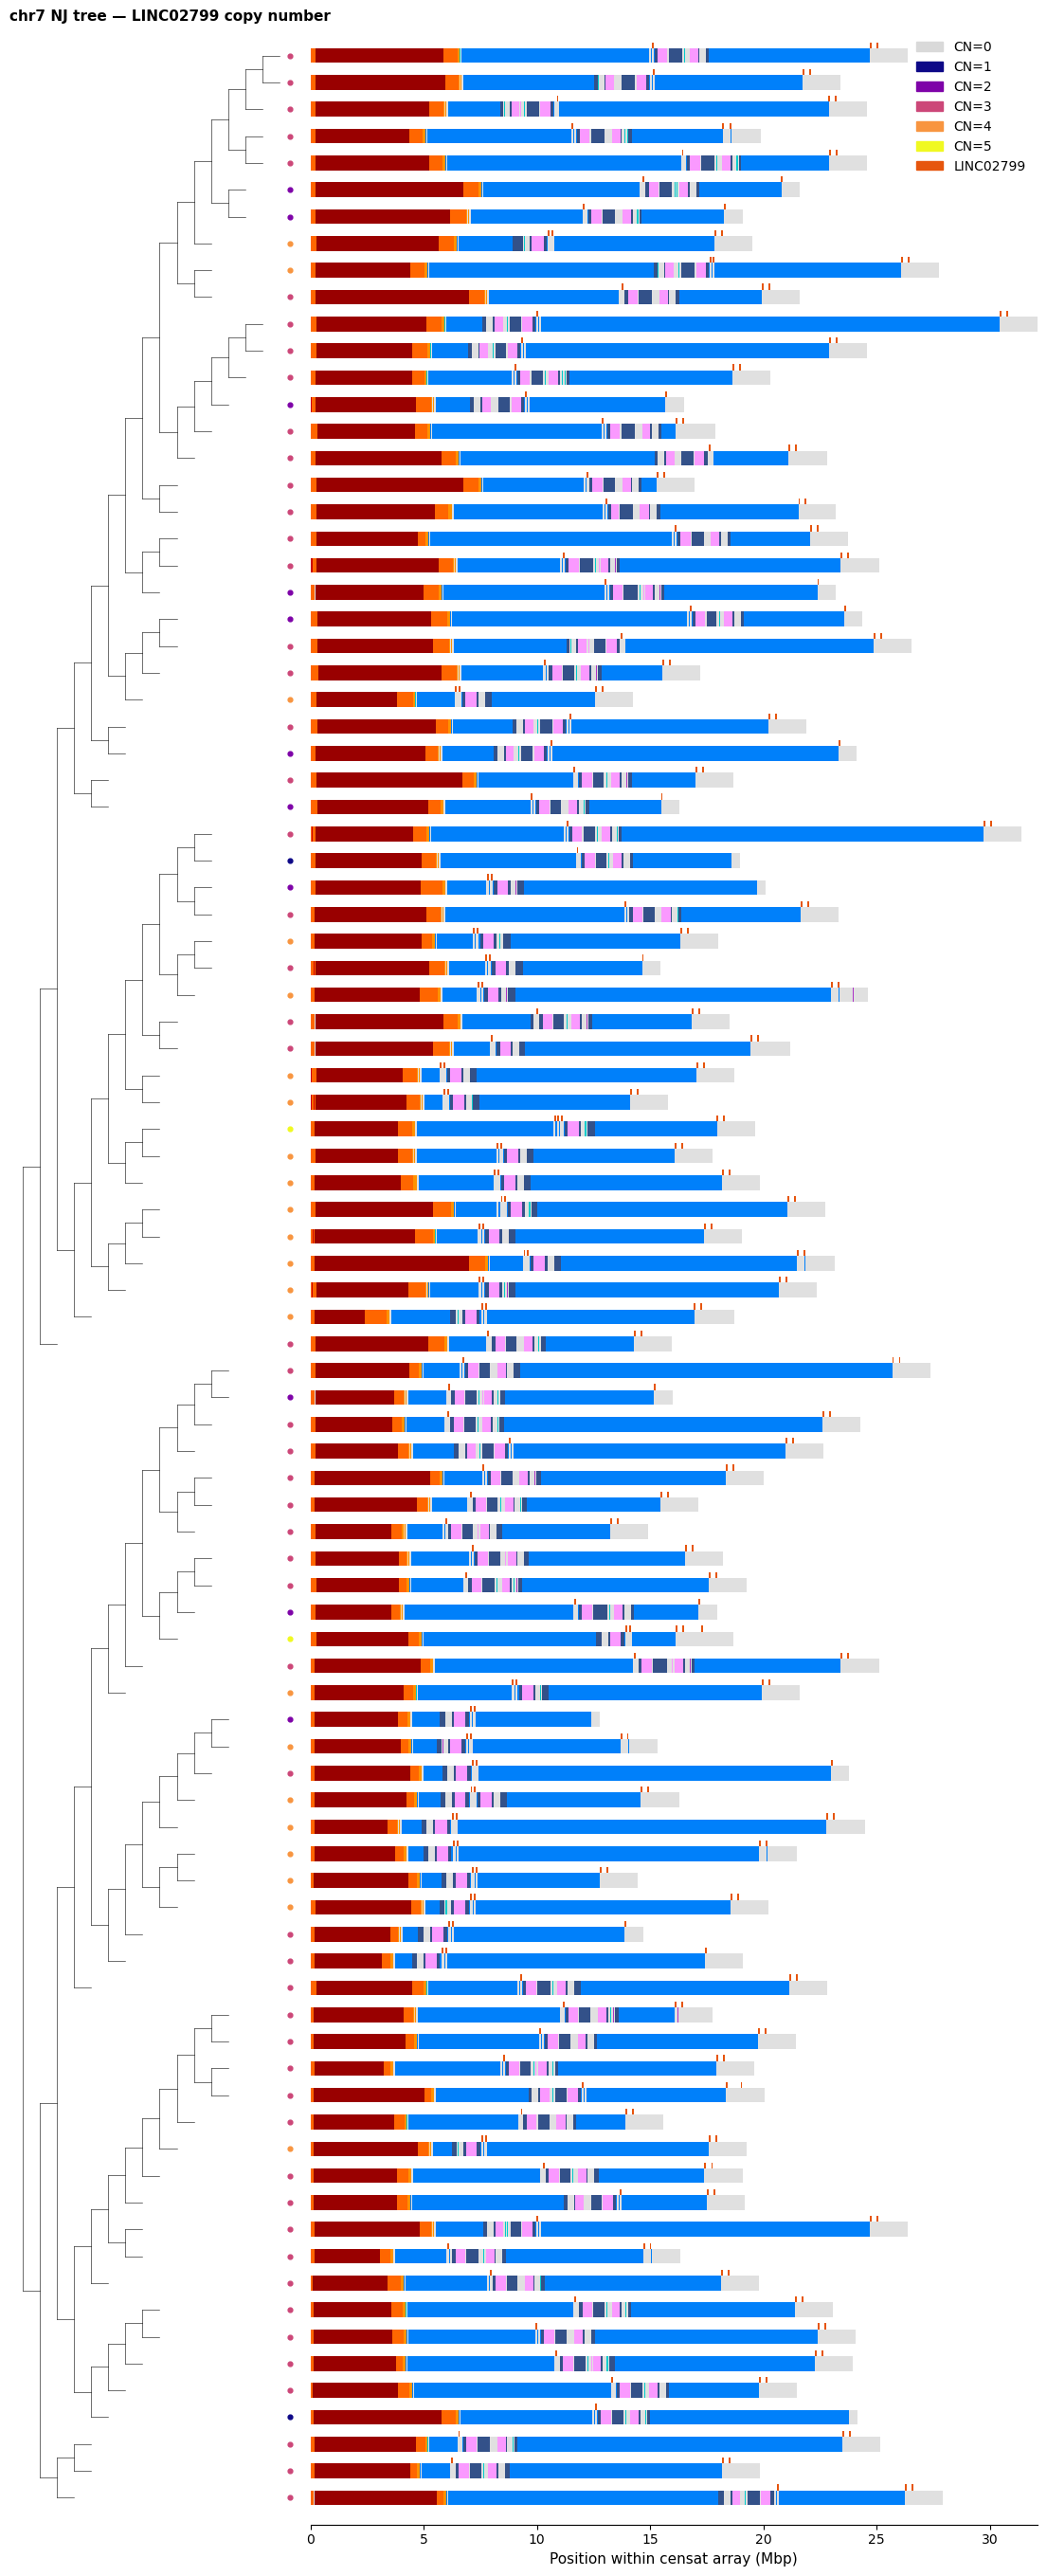

In [58]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from Bio import Phylo

CHROM      = "chr1"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6550d"
TREE_DIR   = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'

# ── copy number of FOCUS_GENE per haplotype ───────────────────────────────────
chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = (
    annot_filt_clean[annot_filt_clean["chrom"] == CHROM]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="n")
)
chr7_hap_counts["haplotype"] = chr7_hap_counts["haplotype"].astype(str)

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = (chr7_hap_counts[["sample_id","haplotype"]]
            .merge(focus_cn, on=["sample_id","haplotype"], how="left"))
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

max_cn = focus_cn["cn"].max()
print(f"Max CN for {FOCUS_GENE}: {max_cn}")
print(focus_cn["cn"].value_counts().sort_index())

# discrete colormap: gray for 0, plasma for 1..max_cn
cmap = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap(i - 1))

focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"]
                for _, r in focus_cn.iterrows()}

# ── tree ──────────────────────────────────────────────────────────────────────
tree_path = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
tree      = Phylo.read(tree_path, "newick")
qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chr7_hap_counts.iterrows())
for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
    tree.prune(leaf)
tree.ladderize()

# ── regions ───────────────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx   = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}
max_size_mbp = (chrom_regions["region_end"] - chrom_regions["region_start"]).max() / 1e6

# ── plot ──────────────────────────────────────────────────────────────────────
terminals = tree.get_terminals()
n         = len(terminals)
ROW_H = 0.35   # was 0.22 — more vertical space per haplotype
CSAT_H = 0.55  # was 0.38 — thicker censat bars
GENE_H = 0.22  # was 0.15 — thicker gene bars
GENE_H = 0.22
GENE_W = 0.08  # fixed width in Mbp for gene markers


fig = plt.figure(figsize=(14, n * ROW_H + 2))  # was (20, ...) — narrower
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], wspace=0.02)  # was [1, 3]
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    cn_val   = focus_cn_map.get(leaf.name, 0)
    ax_tree.scatter(1.04, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                    s=12, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    rs, re_  = region['region_start'], region['region_end']
    size_mbp = (re_ - rs) / 1e6
    genes    = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                              (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE:
            continue
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.add_patch(mpatches.Rectangle(
            (g_mid - GENE_W/2, yi + CSAT_H/2), GENE_W, GENE_H,
            color=GENE_FOCUS, linewidth=0))


ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top','right','left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}")
           for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr7 NJ tree — {FOCUS_GENE} copy number", fontsize=11,
                  fontweight="bold", loc="left")
plt.show()


### Classifying haplotypes of chr7

### Filtering to region of interest

Okay, starting over. From the original dataset, annot_filt_clean, Find the four largest ASAT monomeric blocks per each array. For each array, subset to everything in between the first observation of one of the four largest ASAT monomeric blocks, and the last obersvation of one of the four largest ASAT monomeric blocks. then plot the same tree visual with that subset

/data/tmp/ipykernel_240334/845739364.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", max_cn)


Haplotypes with mon windows: 252
Max window size: 8.73 Mbp


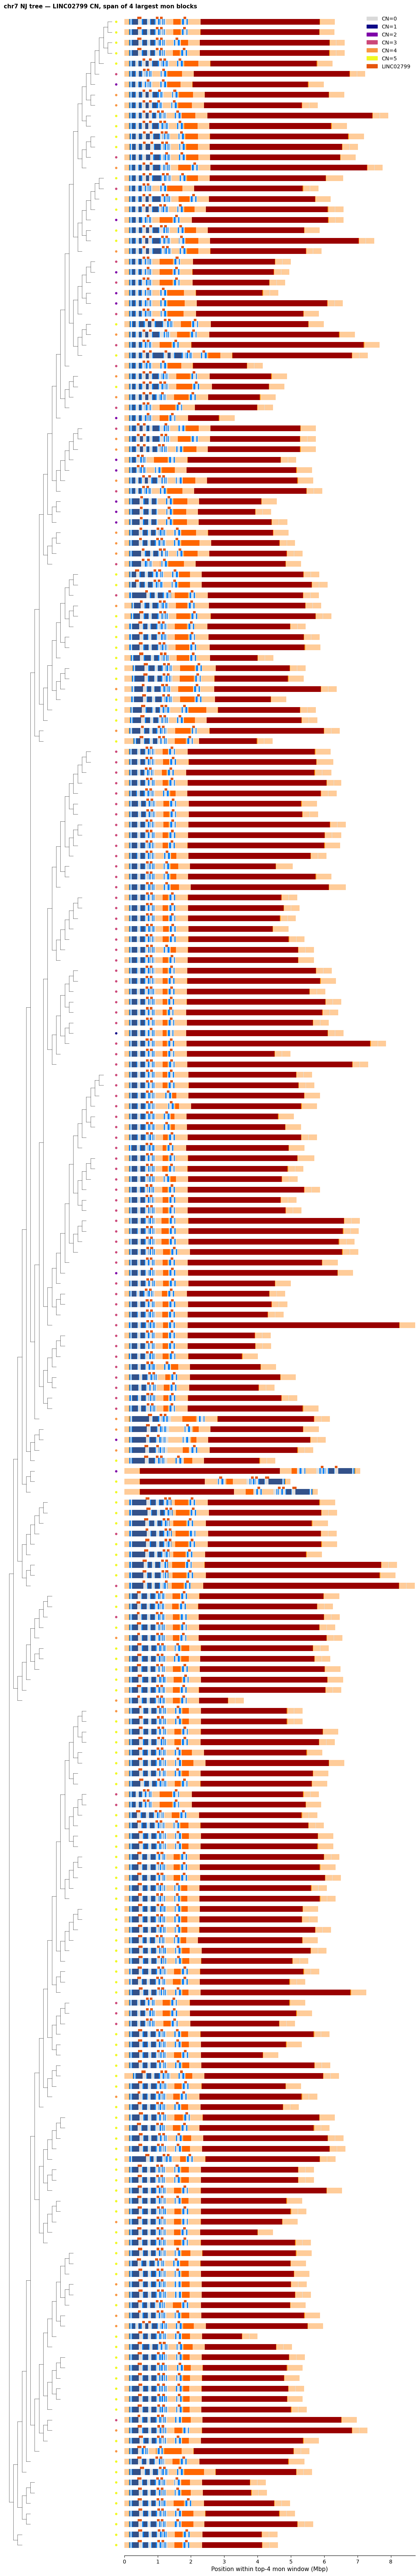

In [59]:
import sys, os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from Bio import Phylo

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6550d"
TREE_DIR   = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'

chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = (
    chr7_genes_df.groupby(["sample_id", "haplotype"]).size().reset_index(name="n")
)

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

max_cn = focus_cn["cn"].max()
cmap = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap(i - 1))
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

tree_path = f'{TREE_DIR}/{CHROM}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
tree      = Phylo.read(tree_path, "newick")
qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chr7_hap_counts.iterrows())
for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
    tree.prune(leaf)
tree.ladderize()

chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── zoom window: span of the 4 largest mon blocks ────────────────────────────
def get_zoom_window(sid, hap, region):
    bed_path = bed_map.get((sid, hap))
    if bed_path is None: return None
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']

    mon_blocks = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end <= rs or start >= re_: continue
            if re.match(r'^mon', cols[3], re.I):
                mon_blocks.append((max(start, rs), min(end, re_)))

    if not mon_blocks:
        return None

    top4 = sorted(mon_blocks, key=lambda x: x[1] - x[0], reverse=True)[:5]
    return (min(s for s, e in top4), max(e for s, e in top4))

zoom_idx = {}
for (sid, hap), region in region_idx.items():
    w = get_zoom_window(sid, hap, region)
    if w:
        zoom_idx[(sid, hap)] = w

max_win_mbp = max((e - s) / 1e6 for s, e in zoom_idx.values()) if zoom_idx else 1.0
print(f"Haplotypes with mon windows: {len(zoom_idx)}")
print(f"Max window size: {max_win_mbp:.2f} Mbp")

# ── plot ──────────────────────────────────────────────────────────────────────
terminals = tree.get_terminals()
n         = len(terminals)
ROW_H = 0.35; CSAT_H = 0.55; GENE_H = 0.22; GENE_W = 0.08

fig = plt.figure(figsize=(14, n * ROW_H + 2))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], wspace=0.02)
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

for leaf in terminals:
    yi       = leaf_y[leaf.name]
    sid, hap = leaf.name.rsplit('.', 1)
    cn_val   = focus_cn_map.get(leaf.name, 0)
    ax_tree.scatter(1.04, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                    s=12, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None: continue

    zoom = zoom_idx.get((sid, hap))
    if zoom is None: continue

    win_start_bp, win_end_bp = zoom
    rs = region['region_start']
    win_start_mbp = (win_start_bp - rs) / 1e6
    win_end_mbp   = (win_end_bp   - rs) / 1e6

    for seg in load_censat(sid, hap, region):
        s = max(seg['start'], win_start_mbp) - win_start_mbp
        e = min(seg['end'],   win_end_mbp)   - win_start_mbp
        if e <= s: continue
        ax_ann.add_patch(mpatches.Rectangle(
            (s, yi - CSAT_H/2), e - s, CSAT_H,
            color=seg['color'], linewidth=0))

    genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                           (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE: continue
        g_mid_bp = (g['start'] + g['end']) / 2
        if g_mid_bp < win_start_bp or g_mid_bp > win_end_bp: continue
        g_mid = (g_mid_bp - win_start_bp) / 1e6
        ax_ann.add_patch(mpatches.Rectangle(
            (g_mid - GENE_W/2, yi + CSAT_H/2), GENE_W, GENE_H,
            color=GENE_FOCUS, linewidth=0))

ax_ann.set_xlim(0, max_win_mbp)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Position within top-4 mon window (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top','right','left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}") for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title(f"chr7 NJ tree — {FOCUS_GENE} CN, span of 4 largest mon blocks",
                  fontsize=11, fontweight="bold", loc="left")
plt.show()


 cn  n_hsat  count
  0      17      1
  0      18      1
  1      14      1
  2      11      4
  2      12      1
  2      13      1
  2      14      3
  2      15      2
  2      16      3
  3      10      1
  3      14     33
  3      15     22
  3      16     27
  3      17      1
  3      18      1
  3      19      1
  4       8      1
  4      13      1
  4      14      1
  4      15      1
  4      16      6
  4      17      4
  4      18     12
  4      19      5
  5      13      2
  5      14      2
  5      15      7
  5      16     24
  5      17     36
  5      18     36
  5      19      8
  5      20      2
  5      22      1


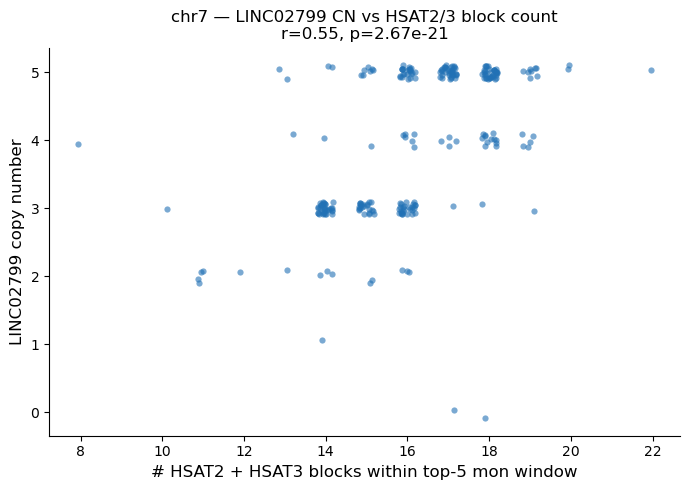

In [60]:
### CN of gene versus number of HSAT 2 and HSAT 3 blocks 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.stats as stats
import re

# count HSAT2 + HSAT3 blocks within each haplotype's top-5 mon window
def count_hsat_blocks(sid, hap, region, win_start_bp, win_end_bp):
    bed_path = bed_map.get((sid, hap))
    if bed_path is None: return 0
    seq = region['sequence_id'].split('#')[-1]
    n = 0
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end <= win_start_bp or start >= win_end_bp: continue
            if re.search(r'hsat[23]', cols[3], re.I):
                n += 1
    return n

rows = []
for (sid, hap), region in region_idx.items():
    zoom = zoom_idx.get((sid, hap))
    if zoom is None: continue
    win_start_bp, win_end_bp = zoom
    n_hsat = count_hsat_blocks(sid, hap, region, win_start_bp, win_end_bp)
    cn = focus_cn_map.get(f"{sid}.{hap}", 0)
    rows.append({"sample_id": sid, "haplotype": hap, "n_hsat": n_hsat, "cn": cn})

hsat_df = pd.DataFrame(rows)
print(hsat_df.groupby(["cn", "n_hsat"]).size().reset_index(name="count").to_string(index=False))

r, p = stats.pearsonr(hsat_df["n_hsat"], hsat_df["cn"])

np.random.seed(42)
jx = np.random.uniform(-0.2, 0.2, len(hsat_df))
jy = np.random.uniform(-0.1, 0.1, len(hsat_df))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hsat_df["n_hsat"] + jx, hsat_df["cn"] + jy,
           s=20, alpha=0.6, color="#2171b5", linewidths=0)

ax.set_xlabel("# HSAT2 + HSAT3 blocks within top-5 mon window", fontsize=12)
ax.set_ylabel(f"{FOCUS_GENE} copy number", fontsize=12)
ax.set_title(f"chr7 — {FOCUS_GENE} CN vs HSAT2/3 block count\nr={r:.2f}, p={p:.2e}", fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


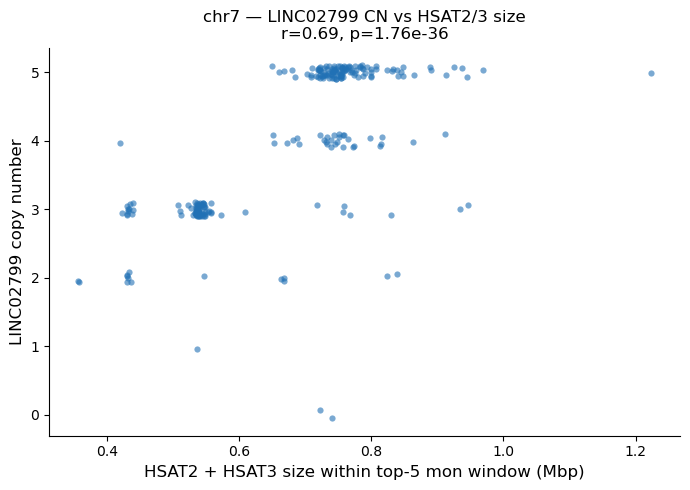

In [61]:
def sum_hsat_mbp(sid, hap, region, win_start_bp, win_end_bp):
    bed_path = bed_map.get((sid, hap))
    if bed_path is None: return 0.0
    seq = region['sequence_id'].split('#')[-1]
    total_bp = 0
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end <= win_start_bp or start >= win_end_bp: continue
            if re.search(r'hsat[23]', cols[3], re.I):
                # clamp to window
                total_bp += min(end, win_end_bp) - max(start, win_start_bp)
    return total_bp / 1e6

rows = []
for (sid, hap), region in region_idx.items():
    zoom = zoom_idx.get((sid, hap))
    if zoom is None: continue
    win_start_bp, win_end_bp = zoom
    hsat_mbp = sum_hsat_mbp(sid, hap, region, win_start_bp, win_end_bp)
    cn = focus_cn_map.get(f"{sid}.{hap}", 0)
    rows.append({"sample_id": sid, "haplotype": hap, "hsat_mbp": hsat_mbp, "cn": cn})

hsat_df = pd.DataFrame(rows)

r, p = stats.pearsonr(hsat_df["hsat_mbp"], hsat_df["cn"])

np.random.seed(42)
jy = np.random.uniform(-0.1, 0.1, len(hsat_df))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hsat_df["hsat_mbp"], hsat_df["cn"] + jy,
           s=20, alpha=0.6, color="#2171b5", linewidths=0)

ax.set_xlabel("HSAT2 + HSAT3 size within top-5 mon window (Mbp)", fontsize=12)
ax.set_ylabel(f"{FOCUS_GENE} copy number", fontsize=12)
ax.set_title(f"chr7 — {FOCUS_GENE} CN vs HSAT2/3 size\nr={r:.2f}, p={p:.2e}", fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# ── pairwise edit distance + linkage ─────────────────────────────────────────
haps   = list(hap_type_seqs.keys())
seqs   = [hap_type_seqs[h] for h in haps]
n_haps = len(haps)

dist_mat = np.zeros((n_haps, n_haps))
for i in range(n_haps):
    for j in range(i + 1, n_haps):
        d = edit_dist(seqs[i], seqs[j])
        dist_mat[i, j] = dist_mat[j, i] = d

Z = linkage(squareform(dist_mat), method='average')

# ── layout ────────────────────────────────────────────────────────────────────
n = n_haps
ROW_H = 0.35; CSAT_H = 0.55; GENE_H = 0.22; GENE_W = 0.08

fig = plt.figure(figsize=(16, n * ROW_H + 2))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 0.04, 2.5], wspace=0.01)
ax_dend = fig.add_subplot(gs[0])
ax_dot  = fig.add_subplot(gs[1])
ax_ann  = fig.add_subplot(gs[2])

# dendrogram: orientation='left' → root on left, leaves on right (touching arrays)
# leaves are at y = 5, 15, ..., 10*(n-1)+5 → match with censat ylim(-1, n)
dn = dendrogram(Z, orientation='left', ax=ax_dend, no_labels=True,
                color_threshold=0, above_threshold_color='black')
leaf_order  = dn['leaves']                          # bottom-to-top order
sorted_haps = [haps[i] for i in leaf_order]

ax_dend.set_ylim(-5, 10 * n + 5)                   # aligns leaves with censat rows
ax_dend.axis('off')

# ── render censat arrays + CN dots ───────────────────────────────────────────
ax_dot.set_xlim(0, 1); ax_dot.set_ylim(-1, n); ax_dot.axis('off')
ax_ann.set_xlim(0, max_win_mbp); ax_ann.set_ylim(-1, n)

for yi, (sid, hap) in enumerate(sorted_haps):
    cn_val = focus_cn_map.get(f"{sid}.{hap}", 0)
    ax_dot.scatter(0.5, yi, color=cn_palette.get(cn_val, cn_palette[max_cn]),
                   s=30, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    zoom   = zoom_idx.get((sid, hap))
    if region is None or zoom is None: continue

    win_start_bp, win_end_bp = zoom
    rs = region['region_start']
    win_start_mbp = (win_start_bp - rs) / 1e6
    win_end_mbp   = (win_end_bp   - rs) / 1e6

    for seg in load_censat(sid, hap, region):
        s = max(seg['start'], win_start_mbp) - win_start_mbp
        e = min(seg['end'],   win_end_mbp)   - win_start_mbp
        if e <= s: continue
        ax_ann.add_patch(mpatches.Rectangle(
            (s, yi - CSAT_H/2), e - s, CSAT_H,
            color=seg['color'], linewidth=0))

    genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                           (chr7_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        if g['gene_name'] != FOCUS_GENE: continue
        g_mid_bp = (g['start'] + g['end']) / 2
        if g_mid_bp < win_start_bp or g_mid_bp > win_end_bp: continue
        g_mid = (g_mid_bp - win_start_bp) / 1e6
        ax_ann.add_patch(mpatches.Rectangle(
            (g_mid - GENE_W/2, yi + CSAT_H/2), GENE_W, GENE_H,
            color=GENE_FOCUS, linewidth=0))

ax_ann.set_xlabel("Position within top-5 mon window (Mbp)", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [mpatches.Patch(color=cn_palette[i], label=f"CN={i}") for i in range(max_cn + 1)]
handles.append(mpatches.Patch(color=GENE_FOCUS, label=FOCUS_GENE))
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_ann.set_title("chr7 censat arrays — hierarchical clustering on type-sequence edit distance",
                 fontsize=11, fontweight="bold", loc="left")
plt.show()



NameError: name 'hap_type_seqs' is not defined

In [ ]:
# if we combine the type sequences into groups where type seqence is identical, how many samples per group and how many groups?
from collections import Counter

group_counts = Counter(tuple(seq) for seq in hap_type_seqs.values())
print(f"Unique type sequences (groups): {len(group_counts)}")
print(f"Total haplotypes: {sum(group_counts.values())}")
print()
for seq, count in sorted(group_counts.items(), key=lambda x: -x[1]):
    print(f"  n={count:3d}  {list(seq)}")


Unique type sequences (groups): 55
Total haplotypes: 252

  n= 42  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'mixedAlpha', 'active_hor', 'dhor', 'mon', 'CT', 'mon']
  n= 30  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'dhor', 'mon', 'hor', 'mon', 'dhor', 'active_hor', 'dhor', 'mon', 'CT', 'mon']
  n= 20  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'dhor', 'mon', 'CT', 'mon']
  

In [ ]:
# for each group, print the lowest edit distance from any other group, and which group that is
groups = list(group_counts.keys())  # each is a tuple (the unique type sequence)

for i, g in enumerate(groups):
    best_dist = None
    best_j    = None
    for j, other in enumerate(groups):
        if i == j: continue
        d = edit_dist(list(g), list(other))
        if best_dist is None or d < best_dist:
            best_dist = d
            best_j    = j
    print(f"n={group_counts[g]:3d}  {list(g)}")
    print(f"       → closest (dist={best_dist}): {list(groups[best_j])}  (n={group_counts[groups[best_j]]})")
    print()


n= 42  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'mixedAlpha', 'active_hor', 'dhor', 'mon', 'CT', 'mon']
       → closest (dist=1): ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'mixedAlpha', 'active_hor', 'dhor', 'mon', 'CT', 'mon']  (n=1)

n= 20  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'dhor', 'mon', 'CT', 'mon']
       → closest (dist=2): ['mon', 'dhor', 

In [ ]:
# combine all groups with an edit distance of 1 from each other and reprint

In [ ]:
# build adjacency: groups within edit distance 1 are connected
n_g = len(groups)
parent = list(range(n_g))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    parent[find(x)] = find(y)

for i in range(n_g):
    for j in range(i + 1, n_g):
        if edit_dist(list(groups[i]), list(groups[j])) <= 1:
            union(i, j)

# aggregate counts by component
from collections import defaultdict
component_counts = defaultdict(int)
component_seqs   = defaultdict(list)

for i, g in enumerate(groups):
    root = find(i)
    component_counts[root] += group_counts[g]
    component_seqs[root].append(g)

print(f"Merged groups (edit dist ≤ 1): {len(component_counts)}")
print(f"Total haplotypes: {sum(component_counts.values())}")
print()
for root, total in sorted(component_counts.items(), key=lambda x: -x[1]):
    print(f"  n={total:3d}  sequences in group:")
    for seq in sorted(component_seqs[root], key=lambda s: -group_counts[s]):
        print(f"         n={group_counts[seq]:3d}  {list(seq)}")
    print()


Merged groups (edit dist ≤ 1): 50
Total haplotypes: 252

  n= 43  sequences in group:
         n= 42  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'mixedAlpha', 'active_hor', 'dhor', 'mon', 'CT', 'mon']
         n=  1  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'hor', 'mon', 'dhor', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'dhor', 'active_hor', 'mixedAlpha', 'active_hor', 'dhor', 'mon', 'CT', 'mon']

  n= 30  sequences in group:
         n= 30  ['mon', 'dhor', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'HSAT3', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'mon', 'CT', 'HSAT2', 'CT', 'HSAT2', 'CT', 'dhor',

### julian's categories

Haplotypes in file: 252
Matched with CN:    250

CN distribution by type:
                 count  mean   std  min   25%  50%   75%  max
structural_type                                              
chr7_type_001     60.0  2.90  0.35  1.0  3.00  3.0  3.00  3.0
chr7_type_002     53.0  4.74  0.79  0.0  5.00  5.0  5.00  5.0
chr7_type_003     46.0  4.72  0.81  0.0  5.00  5.0  5.00  5.0
chr7_type_004     21.0  2.86  0.36  2.0  3.00  3.0  3.00  3.0
chr7_type_005     10.0  4.40  0.97  3.0  3.50  5.0  5.00  5.0
chr7_type_006      6.0  3.33  0.52  3.0  3.00  3.0  3.75  4.0
chr7_type_007      6.0  4.67  0.82  3.0  5.00  5.0  5.00  5.0
chr7_type_008      4.0  5.00  0.00  5.0  5.00  5.0  5.00  5.0
chr7_type_009      3.0  2.00  0.00  2.0  2.00  2.0  2.00  2.0
chr7_type_010      3.0  5.00  0.00  5.0  5.00  5.0  5.00  5.0
chr7_type_011      3.0  3.67  1.53  2.0  3.00  4.0  4.50  5.0
chr7_type_012      2.0  4.00  0.00  4.0  4.00  4.0  4.00  4.0
chr7_type_013      2.0  3.50  0.71  3.0  3.25  3.5  3.75  

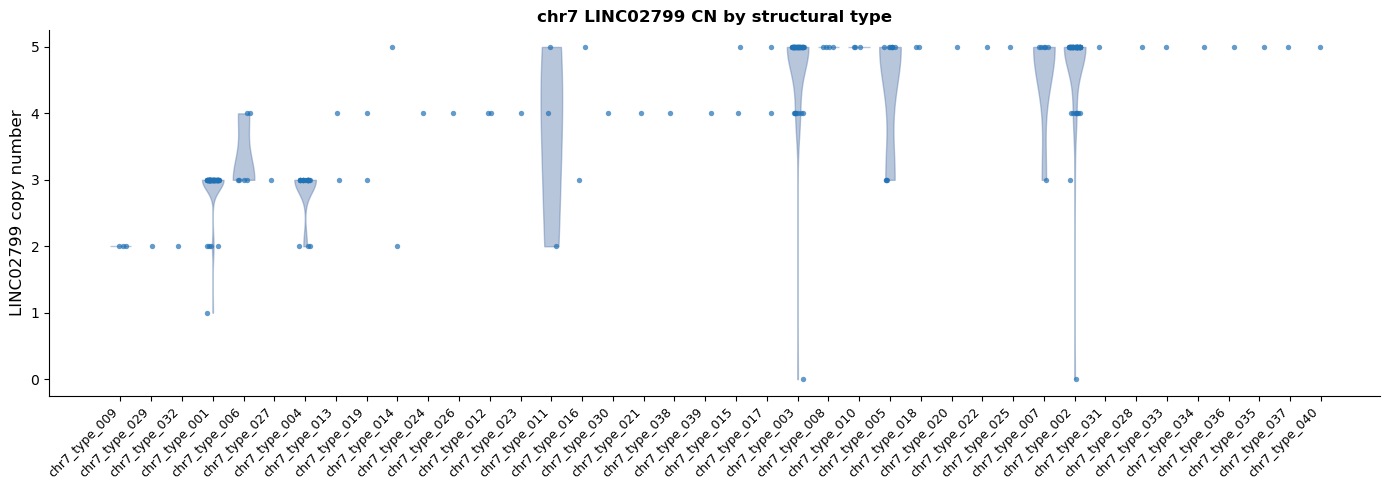

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── load assignments ──────────────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[['sample_hap', 'structural_type']].copy()

# add LINC02799 CN
struct_df['cn'] = struct_df['sample_hap'].map(focus_cn_map).fillna(0).astype(int)

print(f"Haplotypes in file: {len(struct_df)}")
print(f"Matched with CN:    {struct_df['sample_hap'].isin(focus_cn_map).sum()}")
print(f"\nCN distribution by type:")
print(struct_df.groupby('structural_type')['cn'].describe().round(2))

# ── plot: swarm + violin of CN per structural type ────────────────────────────
type_order = (struct_df.groupby('structural_type')['cn']
              .median()
              .sort_values()
              .index.tolist())

fig, ax = plt.subplots(figsize=(14, 5))

np.random.seed(42)
for xi, stype in enumerate(type_order):
    vals = struct_df[struct_df['structural_type'] == stype]['cn'].values
    if len(vals) >= 3:
        parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                              showextrema=False, showmedians=False)
        for pc in parts['bodies']:
            pc.set_facecolor('#4E72A7')
            pc.set_alpha(0.4)
            pc.set_edgecolor('#4E72A7')
    jitter = np.random.uniform(-0.2, 0.2, len(vals))
    ax.scatter(np.full(len(vals), xi) + jitter, vals,
               color='#2171b5', alpha=0.7, s=15, linewidths=0, zorder=3)

ax.set_xticks(range(len(type_order)))
ax.set_xticklabels(type_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel(f"{FOCUS_GENE} copy number", fontsize=12)
ax.set_title(f"chr7 {FOCUS_GENE} CN by structural type", fontsize=12, fontweight='bold')
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()



Types kept: ['chr7_type_001', 'chr7_type_002', 'chr7_type_003', 'chr7_type_004', 'chr7_type_005', 'chr7_type_006', 'chr7_type_007']
Haplotypes: 202


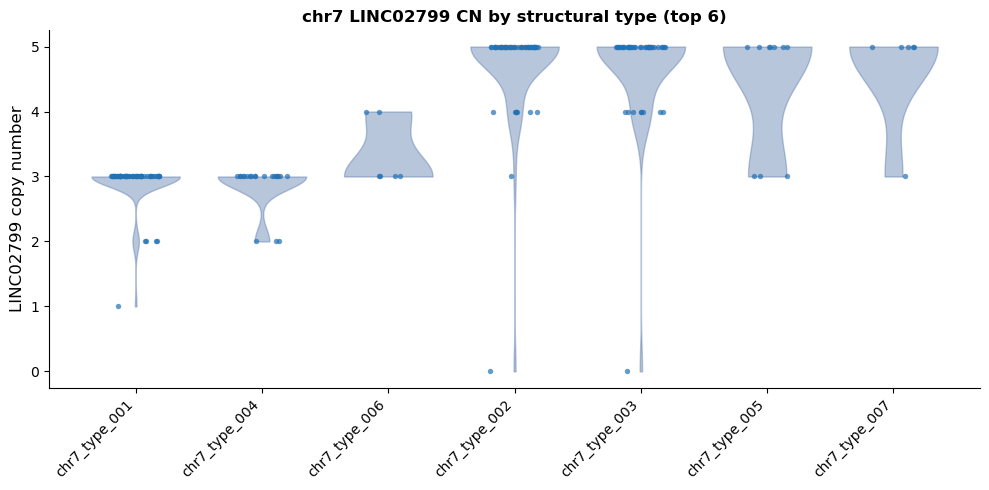

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"

chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)

chr7_hap_counts = chr7_genes_df.groupby(["sample_id", "haplotype"]).size().reset_index(name="n")

focus_cn = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .groupby(["sample_id", "haplotype"]).size().reset_index(name="cn")
)
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)

focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

# ── load assignments ──────────────────────────────────────────────────────────
# ... rest of cell unchanged


# ── load assignments ──────────────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[['sample_hap', 'structural_type']].copy()

struct_df['cn'] = struct_df['sample_hap'].map(focus_cn_map).fillna(0).astype(int)

# ── subset to 6 types with most haplotypes ────────────────────────────────────
top6_types = (struct_df.groupby('structural_type')
              .size()
              .sort_values(ascending=False)
              .head(7)
              .index.tolist())

plot_df = struct_df[struct_df['structural_type'].isin(top6_types)].copy()

print(f"Types kept: {top6_types}")
print(f"Haplotypes: {len(plot_df)}")

type_order = (plot_df.groupby('structural_type')['cn']
              .median()
              .sort_values()
              .index.tolist())

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

np.random.seed(42)
for xi, stype in enumerate(type_order):
    vals = plot_df[plot_df['structural_type'] == stype]['cn'].values
    if len(vals) >= 3:
        parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                              showextrema=False, showmedians=False)
        for pc in parts['bodies']:
            pc.set_facecolor('#4E72A7')
            pc.set_alpha(0.4)
            pc.set_edgecolor('#4E72A7')
    jitter = np.random.uniform(-0.2, 0.2, len(vals))
    ax.scatter(np.full(len(vals), xi) + jitter, vals,
               color='#2171b5', alpha=0.7, s=15, linewidths=0, zorder=3)

ax.set_xticks(range(len(type_order)))
ax.set_xticklabels(type_order, rotation=45, ha='right', fontsize=10)
ax.set_ylabel(f"{FOCUS_GENE} copy number", fontsize=12)
ax.set_title(f"chr7 {FOCUS_GENE} CN by structural type (top 6)", fontsize=12, fontweight='bold')
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


/data/tmp/ipykernel_240334/1125912691.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap("plasma", max_cn)


chr7_type_002  dominant_cn=5  n=53
chr7_type_007  dominant_cn=5  n=6
chr7_type_003  dominant_cn=5  n=46
chr7_type_005  dominant_cn=5  n=10
chr7_type_001  dominant_cn=3  n=60
chr7_type_004  dominant_cn=3  n=21
chr7_type_006  dominant_cn=3  n=6
chr7_type_014  dominant_cn=2  n=2


/data/tmp/ipykernel_240334/1125912691.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


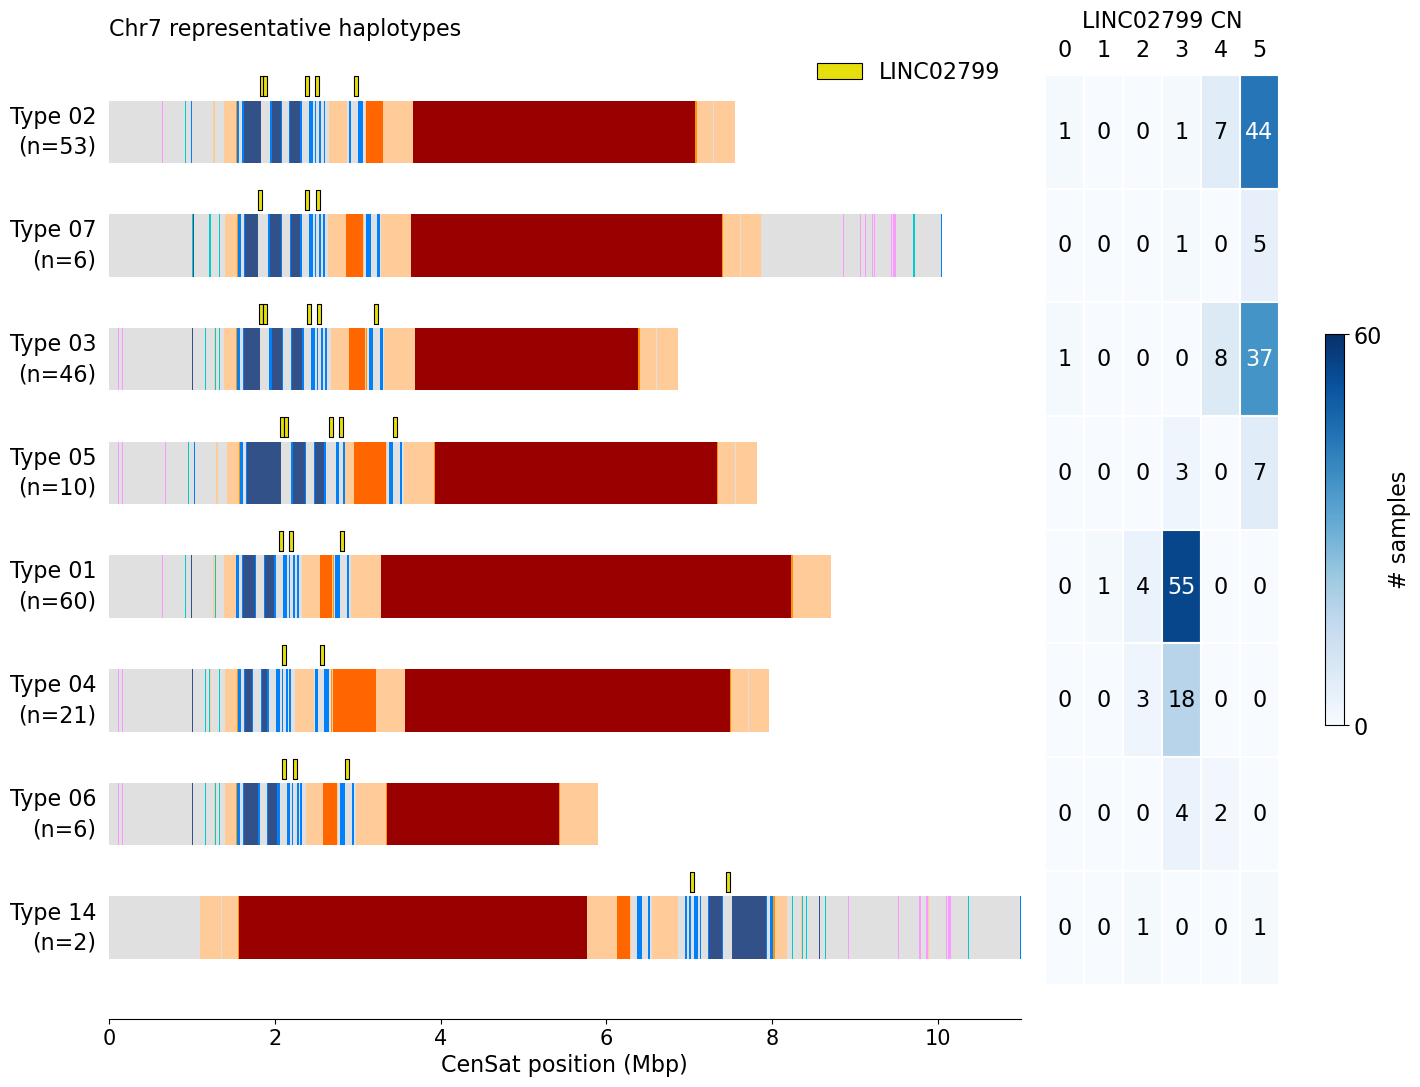

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"

# ── rebuild focus_cn_map for chr7 ─────────────────────────────────────────────
chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)
chr7_hap_counts = chr7_genes_df.groupby(["sample_id","haplotype"]).size().reset_index(name="n")
focus_cn = (chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
            .groupby(["sample_id","haplotype"]).size().reset_index(name="cn"))
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)
max_cn = focus_cn["cn"].max()
cmap_obj = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap_obj(i - 1))
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

# ── rebuild region_idx for chr7 ───────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── load assignments + summary ────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[['sample_hap', 'structural_type']].copy()
struct_df['cn'] = struct_df['sample_hap'].map(focus_cn_map).fillna(0).astype(int)

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)
rep_map = dict(zip(summary_df['structural_type'], summary_df['representative_sample_hap']))

# ── all types sorted by count ─────────────────────────────────────────────────
top6 = (struct_df.groupby('structural_type')
        .size()
        .sort_values(ascending=False)
        .head(7)
        .index.tolist())
keep_types = list(set(top6 + ['chr7_type_014']))

def dominant_cn(stype):
    vals = struct_df[struct_df['structural_type'] == stype]['cn']
    return vals.value_counts().idxmax()

type_order_plot = sorted(keep_types, key=lambda t: -dominant_cn(t))

plot_df = struct_df[struct_df['structural_type'].isin(type_order_plot)].copy()
n_types = len(type_order_plot)

for t in type_order_plot:
    print(f"{t}  dominant_cn={dominant_cn(t)}  n={plot_df[plot_df['structural_type']==t].shape[0]}")



# ── CN heatmap counts (CN 0–4, then ≥5) ──────────────────────────────────────
cn_bins = [0, 1, 2, 3, 4, 5]

hm_counts = np.zeros((n_types, len(cn_bins)), dtype=int)
for ti, stype in enumerate(type_order_plot):
    vals = plot_df[plot_df['structural_type'] == stype]['cn'].values
    for ci, cn_val in enumerate(cn_bins):
        hm_counts[ti, ci] = (vals == cn_val).sum()


# ── find max array size across representative haplotypes ─────────────────────
max_size_mbp = 0
for stype in type_order_plot:
    rep = rep_map.get(stype, '')
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

# ── figure ────────────────────────────────────────────────────────────────────
CSAT_H = 0.55
fig = plt.figure(figsize=(16, n_types * 1.4 + 1.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.04)
ax_ann  = fig.add_subplot(gs[0])
ax_heat = fig.add_subplot(gs[1])

# ── censat arrays ─────────────────────────────────────────────────────────────
for yi, stype in enumerate(type_order_plot):
    rep = rep_map.get(stype, '')
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))
        
    genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                           (chr7_genes_df['haplotype'] == hap) &
                           (chr7_genes_df['gene_name'] == FOCUS_GENE)]
    GENE_W = 0.03
    GENE_H = 0.25
    GENE_FOCUS = "#e6df0d"
    rs = region['region_start']
    re_ = region['region_end']
    size_mbp = (re_ - rs) / 1e6
    from matplotlib.patheffects import withStroke

    import matplotlib.path as mpath
    import numpy as np

    # thin tall rectangle marker (width=0.3, height=1.0 in marker coords)
    verts = np.array([[-0.1, -0.5], [0.1, -0.5], [0.1, 0.5], [-0.1, 0.5], [-0.1, -0.5]])
    tall_marker = mpath.Path(verts)

    for _, g in genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        g_y   = yi - CSAT_H/2 - GENE_H/2
        ax_ann.scatter(g_mid, g_y, marker=tall_marker, s=200,
                   color=GENE_FOCUS, edgecolors='black',
                   linewidths=0.8, zorder=5)

    n_hap = plot_df[plot_df['structural_type'] == stype].shape[0]
    type_num = stype.replace('chr7_type_0', 'Type ').replace('chr7_type_', 'Type ')
    ax_ann.text(-0.15, yi, f"{type_num}\n(n={n_hap})",
                ha='right', va='center', fontsize=16, linespacing=1.4)


ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-0.8, n_types - 0.2)
ax_ann.invert_yaxis()
ax_ann.set_xlabel("CenSat position (Mbp)", fontsize=16)
ax_ann.set_yticks([])
ax_ann.tick_params(axis='x', labelsize=15)
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.set_title("Chr7 representative haplotypes", fontsize=16, loc='left', pad=-15)


# ── CN heatmap ────────────────────────────────────────────────────────────────
count_max = plot_df.groupby('structural_type').size().max()

count_cmap = plt.cm.Blues

for ti in range(n_types):
    for ci, cn_val in enumerate(cn_bins):
        count = hm_counts[ti, ci]
        color = count_cmap(count / count_max) if count_max > 0 else count_cmap(0)
        ax_heat.add_patch(mpatches.Rectangle(
            (ci, ti - 0.5), 1, 1,
            facecolor=color, edgecolor='white', linewidth=1.5))
        ax_heat.text(ci + 0.5, ti, str(count),
                     ha='center', va='center', fontsize=16,
                     color='white' if count / max(count_max, 1) > 0.5 else 'black')

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

## colorbar for # of samples
sm = ScalarMappable(cmap=count_cmap, norm=Normalize(vmin=0, vmax=count_max))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_heat, orientation='vertical', fraction=0.08, pad=0.15, shrink=0.4)
cb.set_label("# samples", fontsize=16)
cb.set_ticks([0, count_max])
cb.set_ticklabels([0, count_max], fontsize=10)
cb.ax.tick_params(labelsize=16)

cb.set_label("# samples", fontsize=16)
cb.ax.tick_params(labelsize=16)

ax_heat.set_xlim(0, len(cn_bins))
ax_heat.set_ylim(-0.8, n_types - 0.2)
ax_heat.invert_yaxis()
ax_heat.set_xticks([i + 0.5 for i in range(len(cn_bins))])
ax_heat.set_xticklabels([str(c) for c in cn_bins], fontsize=16)
ax_heat.xaxis.set_label_position('top')
ax_heat.xaxis.tick_top()
ax_heat.tick_params(axis='x', pad=-15, length=0)
ax_heat.set_xlabel(f"{FOCUS_GENE} CN", fontsize=16, labelpad=6)

ax_heat.xaxis.set_label_position('top')
ax_heat.xaxis.tick_top()
ax_heat.set_xlabel(f"{FOCUS_GENE} CN", fontsize=16, labelpad=8)
ax_heat.tick_params(top=False)
ax_heat.set_yticks([])
for spine in ax_heat.spines.values():
    spine.set_visible(False)

handles = [mpatches.Patch(facecolor=GENE_FOCUS, edgecolor='black',
                          linewidth=0.8, label=FOCUS_GENE)]

ax_ann.legend(handles=handles, loc='upper right', frameon=False,fontsize=16)


plt.tight_layout()
plt.show()



In [66]:
for stype in type_order_plot:
    rep = rep_map.get(stype, '')
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    n_copies = len(chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                                  (chr7_genes_df['haplotype'] == hap) &
                                  (chr7_genes_df['gene_name'] == FOCUS_GENE)])
    print(f"{stype}  rep={rep}  {FOCUS_GENE} copies={n_copies}")


chr7_type_002  rep=HG00272.1  LINC02799 copies=5
chr7_type_007  rep=HG00438.2  LINC02799 copies=3
chr7_type_003  rep=HG00126.1  LINC02799 copies=5
chr7_type_005  rep=HG01993.1  LINC02799 copies=5
chr7_type_001  rep=HG00097.2  LINC02799 copies=3
chr7_type_004  rep=HG00133.1  LINC02799 copies=2
chr7_type_006  rep=HG01243.1  LINC02799 copies=3
chr7_type_014  rep=NA18879.1  LINC02799 copies=2


In [ ]:
linc_lengths = (
    chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
    .assign(length_bp=lambda df: df["end"] - df["start"])
)

print(linc_lengths["length_bp"].describe().round(0))
print(f"\nUnique lengths: {linc_lengths['length_bp'].nunique()}")
print(linc_lengths["length_bp"].value_counts().sort_index().to_string())


count    1001.0
mean     1319.0
std         3.0
min      1311.0
25%      1318.0
50%      1320.0
75%      1321.0
max      1323.0
Name: length_bp, dtype: float64

Unique lengths: 12
length_bp
1311     78
1312      2
1313     28
1314     18
1316      1
1317     35
1318     94
1319    225
1320     52
1321    232
1322    222
1323     14


### Manual QC of Julian's chr7 haplotypes 

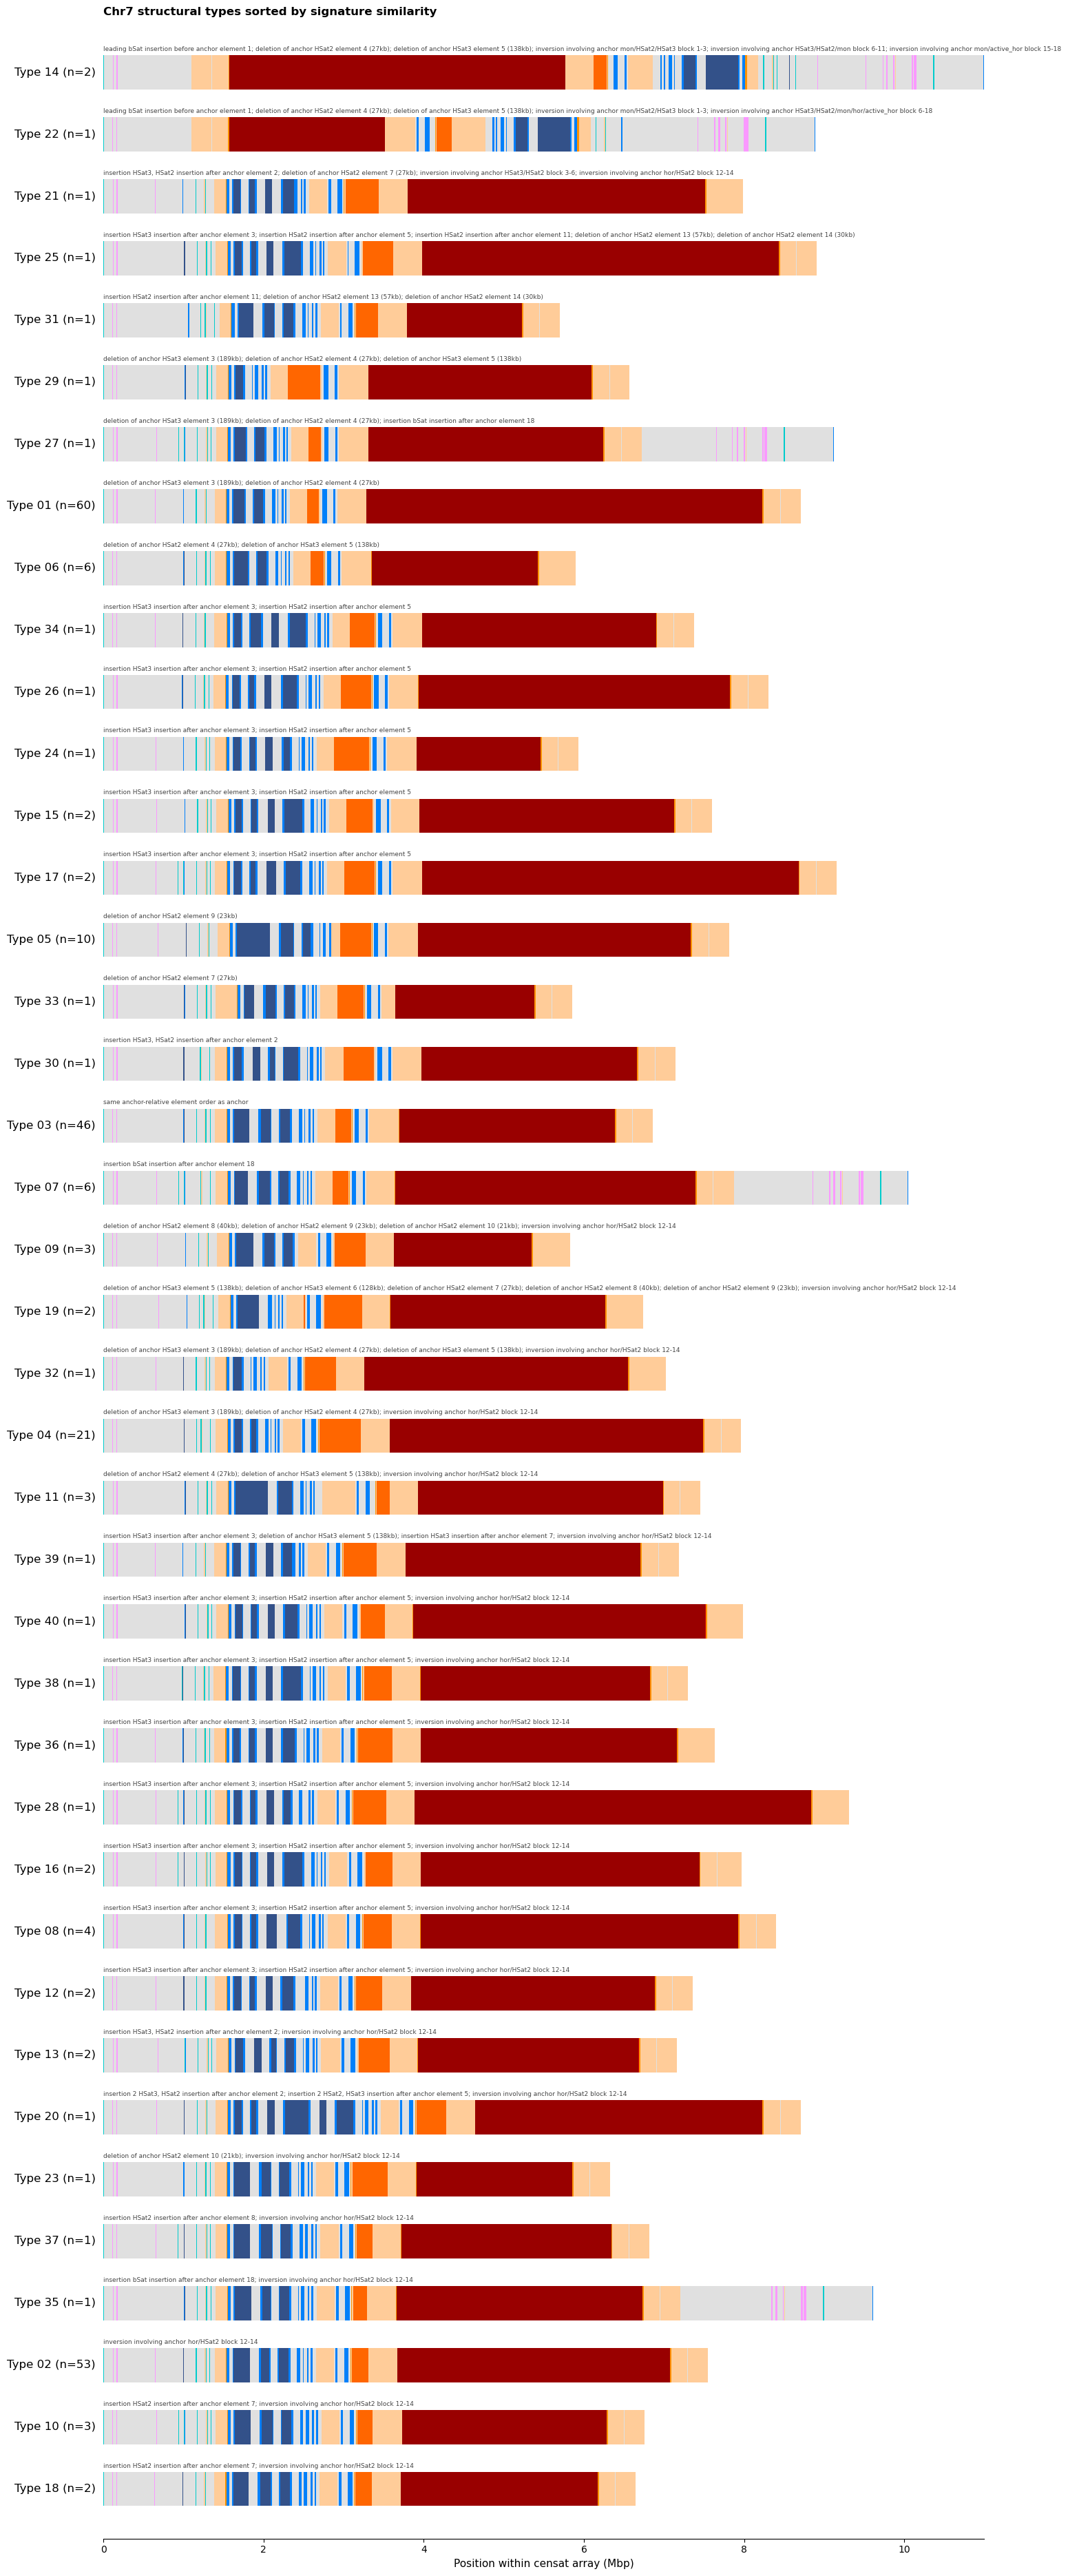

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from difflib import SequenceMatcher
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd

CHROM = "chr7"

chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)

def load_censat_named(sample_id, haplotype, region):
    bed_path = bed_map.get((sample_id, haplotype))
    if bed_path is None: return []
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try: color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({'start': (start-rs)/1e6, 'end': (end-rs)/1e6, 'color': color})
    return rows

# ── sort by structural similarity ─────────────────────────────────────────────
def sig_to_seq(sig):
    """Ordered list of 'type+strand' tokens from M elements."""
    seq = []
    for part in sig.split('|'):
        if part.startswith('INVERSION_BLOCKS'): continue
        if part.startswith('M:'):
            t = part.split(':')
            seq.append(f"{t[2]}{t[3]}")   # e.g. "HSat2+" or "hor-"
        elif part.startswith('I@'):
            seq.append('INS')              # mark insertion presence
    return seq

seqs = [sig_to_seq(s) for s in summary_df['structural_signature']]
n = len(seqs)

dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        ratio = SequenceMatcher(None, seqs[i], seqs[j]).ratio()
        dist_matrix[i, j] = dist_matrix[j, i] = 1 - ratio

linkage  = sch.linkage(ssd.squareform(dist_matrix), method='average')
order    = sch.dendrogram(linkage, no_plot=True)['leaves']
summary_sorted = summary_df.iloc[order].reset_index(drop=True)

# ── plot ──────────────────────────────────────────────────────────────────────
max_size_mbp = 0
for _, row in summary_sorted.iterrows():
    parts = row['representative_sample_hap'].rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

n_types = len(summary_sorted)
CSAT_H  = 0.55

fig, ax = plt.subplots(figsize=(16, n_types * 0.9 + 1.5))

for yi, row in enumerate(summary_sorted.itertuples()):
    parts = row.representative_sample_hap.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue

    for seg in load_censat_named(sid, hap, region):
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    type_num = row.structural_type.replace('chr7_type_0', 'Type ').replace('chr7_type_', 'Type ')
    ax.text(-0.1, yi, f"{type_num} (n={row.count})",
            ha='right', va='center', fontsize=12)
    ax.text(0, yi - CSAT_H/2 - 0.05, row.structural_type_description,
            ha='left', va='bottom', fontsize=6.5, color='#444444', clip_on=False)


ax.set_xlim(0, max_size_mbp)
ax.set_ylim(-0.8, n_types - 0.2)
ax.invert_yaxis()
ax.set_xlabel("Position within censat array (Mbp)", fontsize=11)
ax.set_yticks([])
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_title("Chr7 structural types sorted by signature similarity",
             fontsize=12, fontweight='bold', loc='left', pad=8)

plt.tight_layout()
plt.show()

In [ ]:
# From manual inspection: 
# Combine type 007 with type 003 
# Combine type 36, type 38, type 40, type 16, type 8, type 12, type 13, type 28
# Combine type 23, 37, 35, 2, 10, 18 
# Combine type 27 and type 1 
# Combine type 34, type 26, type 24, type 15, type 17
# Combine type 5, type 33
# 

In [70]:
def dominant_cn_manual(mtype):
    vals = struct_df[struct_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().idxmax()

def dominant_cn_count(mtype):
    vals = struct_df[struct_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().max()

top4 = sorted(
    list(MANUAL_GROUPS.keys()) + keep_ungrouped,
    key=lambda t: -struct_df[struct_df['Manual_Typing'] == t].shape[0]
)[:4]

type_order_plot = sorted(top4, key=lambda t: (-dominant_cn_manual(t), -dominant_cn_count(t)))

for extra in ['chr7_type_014', 'chr7_type_022']:
    if extra not in type_order_plot:
        type_order_plot.append(extra)

plot_df = struct_df[struct_df['Manual_Typing'].isin(type_order_plot)].copy()
n_types = len(type_order_plot)


/data/tmp/ipykernel_240334/620289543.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap("plasma", max_cn)
/data/tmp/ipykernel_240334/620289543.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


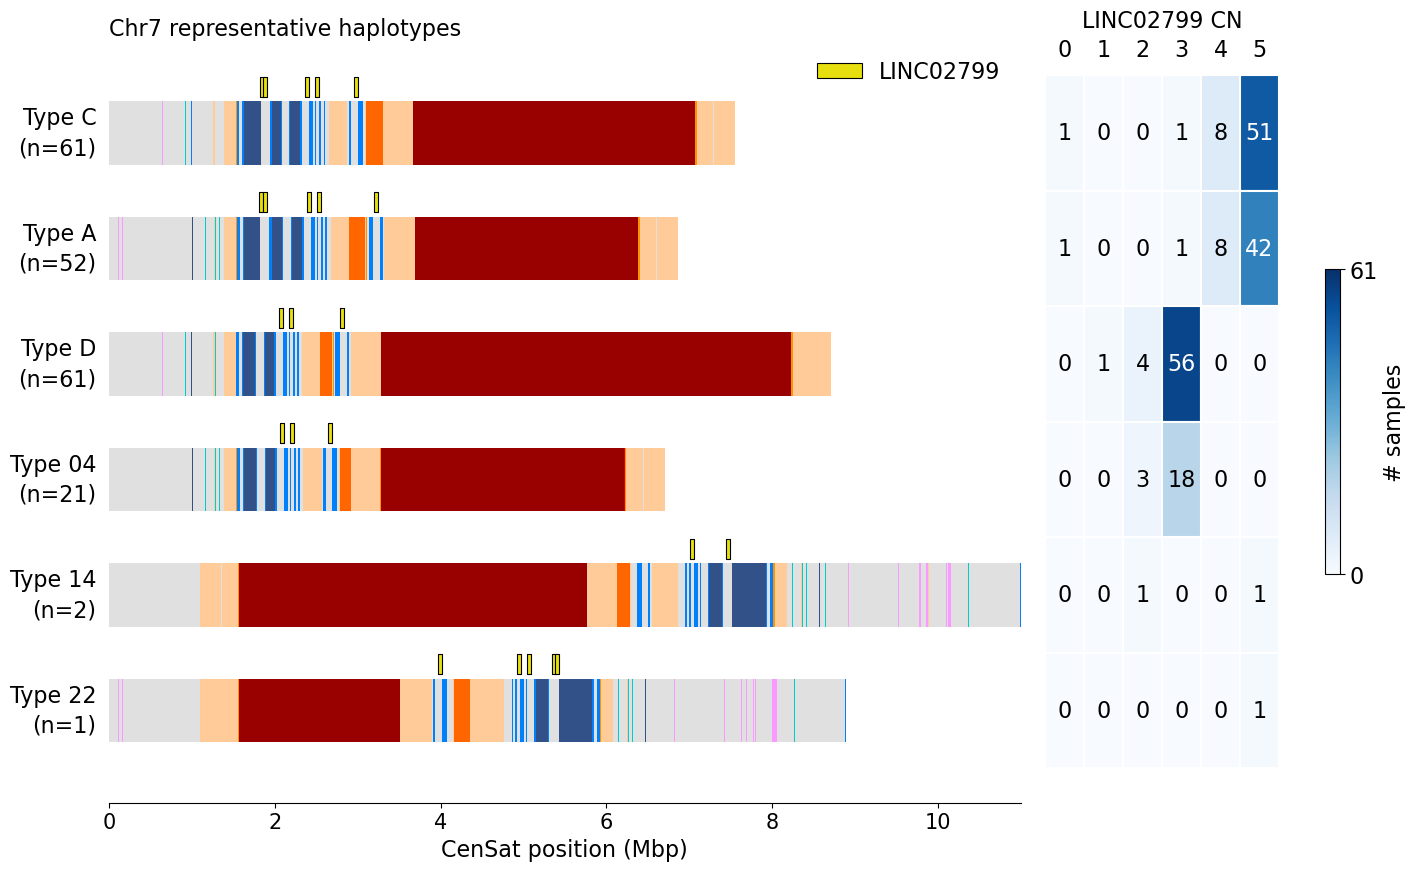


Manual_Typing summary:
Manual_Typing
Type C           61
Type D           61
Type A           52
chr7_type_004    21
Type B           14
Type F           11
Type E            7
chr7_type_006     6
chr7_type_009     3
chr7_type_011     3
chr7_type_014     2
chr7_type_019     2
chr7_type_020     1
chr7_type_021     1
chr7_type_022     1
chr7_type_025     1
chr7_type_029     1
chr7_type_030     1
chr7_type_031     1
chr7_type_032     1
chr7_type_039     1


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.path as mpath

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6df0d"

# ── rebuild focus_cn_map ──────────────────────────────────────────────────────
chr7_genes_df = annot_filt_clean[annot_filt_clean["chrom"] == CHROM].copy()
chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)
chr7_hap_counts = chr7_genes_df.groupby(["sample_id","haplotype"]).size().reset_index(name="n")
focus_cn = (chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
            .groupby(["sample_id","haplotype"]).size().reset_index(name="cn"))
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)
max_cn = focus_cn["cn"].max()
cmap_obj = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap_obj(i - 1))
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

# ── rebuild region_idx ────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── load assignments + summary ────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[['sample_hap', 'structural_type']].copy()
struct_df['cn'] = struct_df['sample_hap'].map(focus_cn_map).fillna(0).astype(int)

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)
rep_map = dict(zip(summary_df['structural_type'], summary_df['representative_sample_hap']))

# ── define manual groupings ───────────────────────────────────────────────────
MANUAL_GROUPS = {
    'Type A': ['chr7_type_003', 'chr7_type_007'],
    'Type B': ['chr7_type_036', 'chr7_type_038', 'chr7_type_040', 'chr7_type_016',
               'chr7_type_008', 'chr7_type_012', 'chr7_type_013', 'chr7_type_028'],
    'Type C': ['chr7_type_023', 'chr7_type_037', 'chr7_type_035', 'chr7_type_002',
               'chr7_type_010', 'chr7_type_018'],
    'Type D': ['chr7_type_027', 'chr7_type_001'],
    'Type E': ['chr7_type_034', 'chr7_type_026', 'chr7_type_024', 'chr7_type_015', 'chr7_type_017'],
    'Type F': ['chr7_type_005', 'chr7_type_033'],
}

orig_to_manual = {t: manual for manual, types in MANUAL_GROUPS.items() for t in types}

# add Manual_Typing column — unmerged types keep original name
struct_df['Manual_Typing']  = struct_df['structural_type'].map(lambda t: orig_to_manual.get(t, t))
summary_df['Manual_Typing'] = summary_df['structural_type'].map(lambda t: orig_to_manual.get(t, t))

# representative haplotype per manual type = rep of most-sampled sub-type
def manual_rep(mtype):
    dom_cn = dominant_cn_manual(mtype)
    # candidates in this manual type with the dominant CN
    candidates = plot_df[
        (plot_df['Manual_Typing'] == mtype) & (plot_df['cn'] == dom_cn)
    ]['sample_hap'].tolist()
    
    for sample_hap in candidates:
        parts = sample_hap.rsplit('.', 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    
    # fallback: any valid haplotype in this type
    for sample_hap in plot_df[plot_df['Manual_Typing'] == mtype]['sample_hap'].tolist():
        parts = sample_hap.rsplit('.', 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    
    return ''


# ── build type order: letter groups first, then top ungrouped by count ────────
ungrouped = [t for t in struct_df['Manual_Typing'].unique() if t not in MANUAL_GROUPS]
ungrouped_sorted = sorted(ungrouped, key=lambda t: -struct_df[struct_df['Manual_Typing'] == t].shape[0])

# keep ungrouped types with >= 2 samples + always include chr7_type_014
keep_ungrouped = [t for t in ungrouped_sorted
                  if struct_df[struct_df['Manual_Typing'] == t].shape[0] >= 2
                  or t == 'chr7_type_014']

def dominant_cn_manual(mtype):
    vals = plot_df[plot_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().idxmax()

def dominant_cn_count(mtype):
    vals = plot_df[plot_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().max()

top6 = sorted(
    list(MANUAL_GROUPS.keys()) + keep_ungrouped,
    key=lambda t: -plot_df[plot_df['Manual_Typing'] == t].shape[0]
)[:4]
type_order_plot = sorted(top6, key=lambda t: (-dominant_cn_manual(t), -dominant_cn_count(t)))

# append type 14 and 22 at the end if not already in top6
for extra in ['chr7_type_014', 'chr7_type_022']:
    if extra not in type_order_plot:
        type_order_plot.append(extra)

plot_df = struct_df[struct_df['Manual_Typing'].isin(type_order_plot)].copy()
n_types = len(type_order_plot)

# ── CN heatmap counts ─────────────────────────────────────────────────────────
cn_bins   = [0, 1, 2, 3, 4, 5]
hm_counts = np.zeros((n_types, len(cn_bins)), dtype=int)
for ti, mtype in enumerate(type_order_plot):
    vals = plot_df[plot_df['Manual_Typing'] == mtype]['cn'].values
    for ci, cn_val in enumerate(cn_bins):
        hm_counts[ti, ci] = (vals == cn_val).sum()

# ── max array size ────────────────────────────────────────────────────────────
max_size_mbp = 0
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

# ── figure ────────────────────────────────────────────────────────────────────
CSAT_H = 0.55
GENE_H = 0.25
verts = np.array([[-0.1, -0.5], [0.1, -0.5], [0.1, 0.5], [-0.1, 0.5], [-0.1, -0.5]])
tall_marker = mpath.Path(verts)

fig = plt.figure(figsize=(16, n_types * 1.4 + 1.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.04)
ax_ann  = fig.add_subplot(gs[0])
ax_heat = fig.add_subplot(gs[1])

for yi, mtype in enumerate(type_order_plot):
    rep = manual_rep(mtype)
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    rs = region['region_start']

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                           (chr7_genes_df['haplotype'] == hap) &
                           (chr7_genes_df['gene_name'] == FOCUS_GENE)]
    for _, g in genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2, marker=tall_marker, s=200,
                       color=GENE_FOCUS, edgecolors='black', linewidths=0.8, zorder=5)

    n_hap = plot_df[plot_df['Manual_Typing'] == mtype].shape[0]
    # label: letter for merged groups, original number for ungrouped
    if mtype in MANUAL_GROUPS:
        label = mtype
    else:
        label = mtype.replace('chr7_type_0', 'Type ').replace('chr7_type_', 'Type ')
    ax_ann.text(-0.15, yi, f"{label}\n(n={n_hap})",
                ha='right', va='center', fontsize=16, linespacing=1.4)

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-0.8, n_types - 0.2)
ax_ann.invert_yaxis()
ax_ann.set_xlabel("CenSat position (Mbp)", fontsize=16)
ax_ann.set_yticks([])
ax_ann.tick_params(axis='x', labelsize=15)
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.set_title("Chr7 representative haplotypes", fontsize=16, loc='left', pad=-15)
ax_ann.legend(handles=[mpatches.Patch(facecolor=GENE_FOCUS, edgecolor='black',
              linewidth=0.8, label=FOCUS_GENE)],
              loc='upper right', frameon=False, fontsize=16)

# ── CN heatmap ────────────────────────────────────────────────────────────────
count_max  = plot_df.groupby('Manual_Typing').size().max()
count_cmap = plt.cm.Blues

for ti in range(n_types):
    for ci, cn_val in enumerate(cn_bins):
        count = hm_counts[ti, ci]
        color = count_cmap(count / count_max) if count_max > 0 else count_cmap(0)
        ax_heat.add_patch(mpatches.Rectangle(
            (ci, ti - 0.5), 1, 1, facecolor=color, edgecolor='white', linewidth=1.5))
        ax_heat.text(ci + 0.5, ti, str(count), ha='center', va='center', fontsize=16,
                     color='white' if count / max(count_max, 1) > 0.5 else 'black')

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap=count_cmap, norm=Normalize(vmin=0, vmax=count_max))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_heat, orientation='vertical', fraction=0.08, pad=0.15, shrink=0.4)
cb.set_label("# samples", fontsize=16)
cb.set_ticks([0, count_max])
cb.set_ticklabels([0, count_max])
cb.ax.tick_params(labelsize=16)

ax_heat.set_xlim(0, len(cn_bins))
ax_heat.set_ylim(-0.8, n_types - 0.2)
ax_heat.invert_yaxis()
ax_heat.set_xticks([i + 0.5 for i in range(len(cn_bins))])
ax_heat.set_xticklabels([str(c) for c in cn_bins], fontsize=16)
ax_heat.xaxis.set_label_position('top')
ax_heat.xaxis.tick_top()
ax_heat.tick_params(axis='x', pad=-15, length=0)
ax_heat.set_xlabel(f"{FOCUS_GENE} CN", fontsize=16, labelpad=8)
ax_heat.set_yticks([])
for spine in ax_heat.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print("\nManual_Typing summary:")
print(struct_df.groupby('Manual_Typing').size().sort_values(ascending=False).to_string())


/data/tmp/ipykernel_240334/1586797844.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap("plasma", max_cn)
/data/tmp/ipykernel_240334/1586797844.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


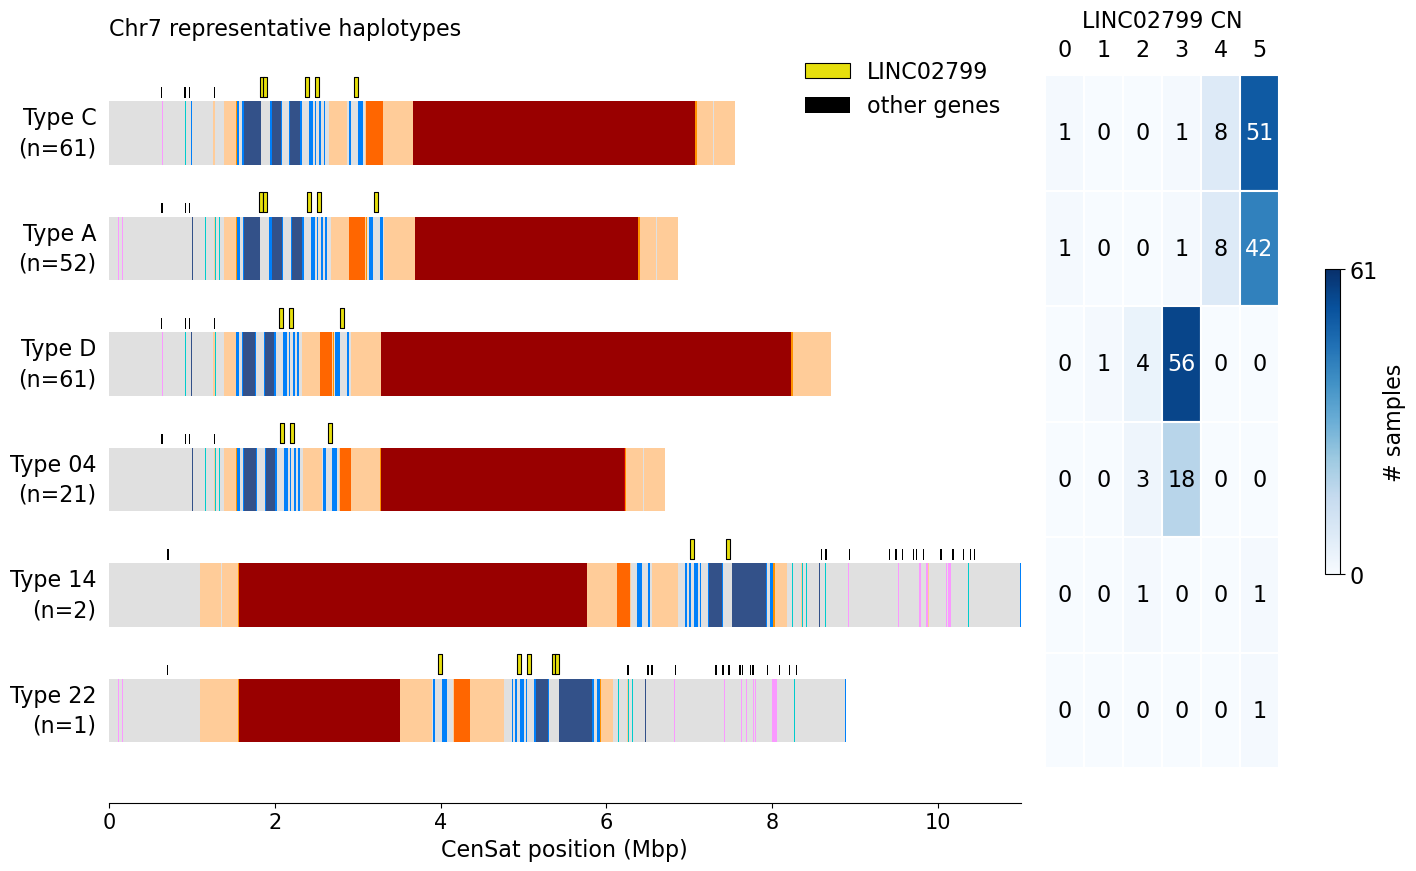


Manual_Typing summary:
Manual_Typing
Type C           61
Type D           61
Type A           52
chr7_type_004    21
Type B           14
Type F           11
Type E            7
chr7_type_006     6
chr7_type_009     3
chr7_type_011     3
chr7_type_014     2
chr7_type_019     2
chr7_type_020     1
chr7_type_021     1
chr7_type_022     1
chr7_type_025     1
chr7_type_029     1
chr7_type_030     1
chr7_type_031     1
chr7_type_032     1
chr7_type_039     1


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.path as mpath

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6df0d"
GENE_OTHER = "black"
GENE_H     = 0.25
OTHER_H    = 0.15

# ── rebuild focus_cn_map ──────────────────────────────────────────────────────
chr7_genes_df = annot_filt_clean[
    (annot_filt_clean["chrom"] == CHROM) &
    (annot_filt_clean["biotype_class"].isin({"protein-coding", "lncRNA"}))
].copy()

chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)
chr7_hap_counts = chr7_genes_df.groupby(["sample_id","haplotype"]).size().reset_index(name="n")
focus_cn = (chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
            .groupby(["sample_id","haplotype"]).size().reset_index(name="cn"))
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)
max_cn = focus_cn["cn"].max()
cmap_obj = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap_obj(i - 1))
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

# ── rebuild region_idx ────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── load assignments + summary ────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[['sample_hap', 'structural_type']].copy()
struct_df['cn'] = struct_df['sample_hap'].map(focus_cn_map).fillna(0).astype(int)

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)
rep_map = dict(zip(summary_df['structural_type'], summary_df['representative_sample_hap']))

# ── define manual groupings ───────────────────────────────────────────────────
MANUAL_GROUPS = {
    'Type A': ['chr7_type_003', 'chr7_type_007'],
    'Type B': ['chr7_type_036', 'chr7_type_038', 'chr7_type_040', 'chr7_type_016',
               'chr7_type_008', 'chr7_type_012', 'chr7_type_013', 'chr7_type_028'],
    'Type C': ['chr7_type_023', 'chr7_type_037', 'chr7_type_035', 'chr7_type_002',
               'chr7_type_010', 'chr7_type_018'],
    'Type D': ['chr7_type_027', 'chr7_type_001'],
    'Type E': ['chr7_type_034', 'chr7_type_026', 'chr7_type_024', 'chr7_type_015', 'chr7_type_017'],
    'Type F': ['chr7_type_005', 'chr7_type_033'],
}

orig_to_manual = {t: manual for manual, types in MANUAL_GROUPS.items() for t in types}

struct_df['Manual_Typing']  = struct_df['structural_type'].map(lambda t: orig_to_manual.get(t, t))
summary_df['Manual_Typing'] = summary_df['structural_type'].map(lambda t: orig_to_manual.get(t, t))

# ── build type order ──────────────────────────────────────────────────────────
ungrouped = [t for t in struct_df['Manual_Typing'].unique() if t not in MANUAL_GROUPS]
ungrouped_sorted = sorted(ungrouped, key=lambda t: -struct_df[struct_df['Manual_Typing'] == t].shape[0])
keep_ungrouped = [t for t in ungrouped_sorted
                  if struct_df[struct_df['Manual_Typing'] == t].shape[0] >= 2
                  or t == 'chr7_type_014']

def dominant_cn_manual(mtype):
    vals = struct_df[struct_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().idxmax()

def dominant_cn_count(mtype):
    vals = struct_df[struct_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().max()

top4 = sorted(
    list(MANUAL_GROUPS.keys()) + keep_ungrouped,
    key=lambda t: -struct_df[struct_df['Manual_Typing'] == t].shape[0]
)[:4]

type_order_plot = sorted(top4, key=lambda t: (-dominant_cn_manual(t), -dominant_cn_count(t)))

for extra in ['chr7_type_014', 'chr7_type_022']:
    if extra not in type_order_plot:
        type_order_plot.append(extra)

plot_df = struct_df[struct_df['Manual_Typing'].isin(type_order_plot)].copy()
n_types = len(type_order_plot)

# ── representative haplotype per manual type ──────────────────────────────────
def manual_rep(mtype):
    dom_cn = dominant_cn_manual(mtype)
    candidates = plot_df[
        (plot_df['Manual_Typing'] == mtype) & (plot_df['cn'] == dom_cn)
    ]['sample_hap'].tolist()
    for sample_hap in candidates:
        parts = sample_hap.rsplit('.', 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    for sample_hap in plot_df[plot_df['Manual_Typing'] == mtype]['sample_hap'].tolist():
        parts = sample_hap.rsplit('.', 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    return ''

# ── CN heatmap counts ─────────────────────────────────────────────────────────
cn_bins   = [0, 1, 2, 3, 4, 5]
hm_counts = np.zeros((n_types, len(cn_bins)), dtype=int)
for ti, mtype in enumerate(type_order_plot):
    vals = plot_df[plot_df['Manual_Typing'] == mtype]['cn'].values
    for ci, cn_val in enumerate(cn_bins):
        hm_counts[ti, ci] = (vals == cn_val).sum()

# ── max array size ────────────────────────────────────────────────────────────
max_size_mbp = 0
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

# ── markers ───────────────────────────────────────────────────────────────────
verts = np.array([[-0.1, -0.5], [0.1, -0.5], [0.1, 0.5], [-0.1, 0.5], [-0.1, -0.5]])
tall_marker = mpath.Path(verts)

verts_other = np.array([[-0.06, -0.5], [0.06, -0.5], [0.06, 0.5], [-0.06, 0.5], [-0.06, -0.5]])
other_marker = mpath.Path(verts_other)

# ── figure ────────────────────────────────────────────────────────────────────
CSAT_H = 0.55
fig = plt.figure(figsize=(16, n_types * 1.4 + 1.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.04)
ax_ann  = fig.add_subplot(gs[0])
ax_heat = fig.add_subplot(gs[1])

for yi, mtype in enumerate(type_order_plot):
    rep = manual_rep(mtype)
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    rs = region['region_start']

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    # LINC02799 first (underneath)
    focus_genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                                 (chr7_genes_df['haplotype'] == hap) &
                                 (chr7_genes_df['gene_name'] == FOCUS_GENE)]
    for _, g in focus_genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2, marker=tall_marker, s=200,
                      color=GENE_FOCUS, edgecolors='black', linewidths=0.8, zorder=4, clip_on=False)

    # other genes on top
    other_genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                                 (chr7_genes_df['haplotype'] == hap) &
                                 (chr7_genes_df['gene_name'] != FOCUS_GENE)]
    for _, g in other_genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - OTHER_H/2, marker=other_marker, s=60,
                       color=GENE_OTHER, edgecolors='none', zorder=5, clip_on=False)


    n_hap = plot_df[plot_df['Manual_Typing'] == mtype].shape[0]
    label = mtype if mtype in MANUAL_GROUPS else mtype.replace('chr7_type_0', 'Type ').replace('chr7_type_', 'Type ')
    ax_ann.text(-0.15, yi, f"{label}\n(n={n_hap})",
                ha='right', va='center', fontsize=16, linespacing=1.4)

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-0.8, n_types - 0.2)
ax_ann.invert_yaxis()
ax_ann.set_xlabel("CenSat position (Mbp)", fontsize=16)
ax_ann.set_yticks([])
ax_ann.tick_params(axis='x', labelsize=15)
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.set_title("Chr7 representative haplotypes", fontsize=16, loc='left', pad=-15)
ax_ann.legend(handles=[
    mpatches.Patch(facecolor=GENE_FOCUS, edgecolor='black', linewidth=0.8, label=FOCUS_GENE),
    mpatches.Patch(facecolor=GENE_OTHER, edgecolor='none', label='other genes'),
], loc='upper right', frameon=False, fontsize=16)

# ── CN heatmap ────────────────────────────────────────────────────────────────
count_max  = plot_df.groupby('Manual_Typing').size().max()
count_cmap = plt.cm.Blues

for ti in range(n_types):
    for ci, cn_val in enumerate(cn_bins):
        count = hm_counts[ti, ci]
        color = count_cmap(count / count_max) if count_max > 0 else count_cmap(0)
        ax_heat.add_patch(mpatches.Rectangle(
            (ci, ti - 0.5), 1, 1, facecolor=color, edgecolor='white', linewidth=1.5))
        ax_heat.text(ci + 0.5, ti, str(count), ha='center', va='center', fontsize=16,
                     color='white' if count / max(count_max, 1) > 0.5 else 'black')

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap=count_cmap, norm=Normalize(vmin=0, vmax=count_max))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_heat, orientation='vertical', fraction=0.08, pad=0.15, shrink=0.4)
cb.set_label("# samples", fontsize=16)
cb.set_ticks([0, count_max])
cb.set_ticklabels([0, count_max])
cb.ax.tick_params(labelsize=16)

ax_heat.set_xlim(0, len(cn_bins))
ax_heat.set_ylim(-0.8, n_types - 0.2)
ax_heat.invert_yaxis()
ax_heat.set_xticks([i + 0.5 for i in range(len(cn_bins))])
ax_heat.set_xticklabels([str(c) for c in cn_bins], fontsize=16)
ax_heat.xaxis.set_label_position('top')
ax_heat.xaxis.tick_top()
ax_heat.tick_params(axis='x', pad=-15, length=0)
ax_heat.set_xlabel(f"{FOCUS_GENE} CN", fontsize=16, labelpad=8)
ax_heat.set_yticks([])
for spine in ax_heat.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print("\nManual_Typing summary:")
print(struct_df.groupby('Manual_Typing').size().sort_values(ascending=False).to_string())


/data/tmp/ipykernel_240334/129363014.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


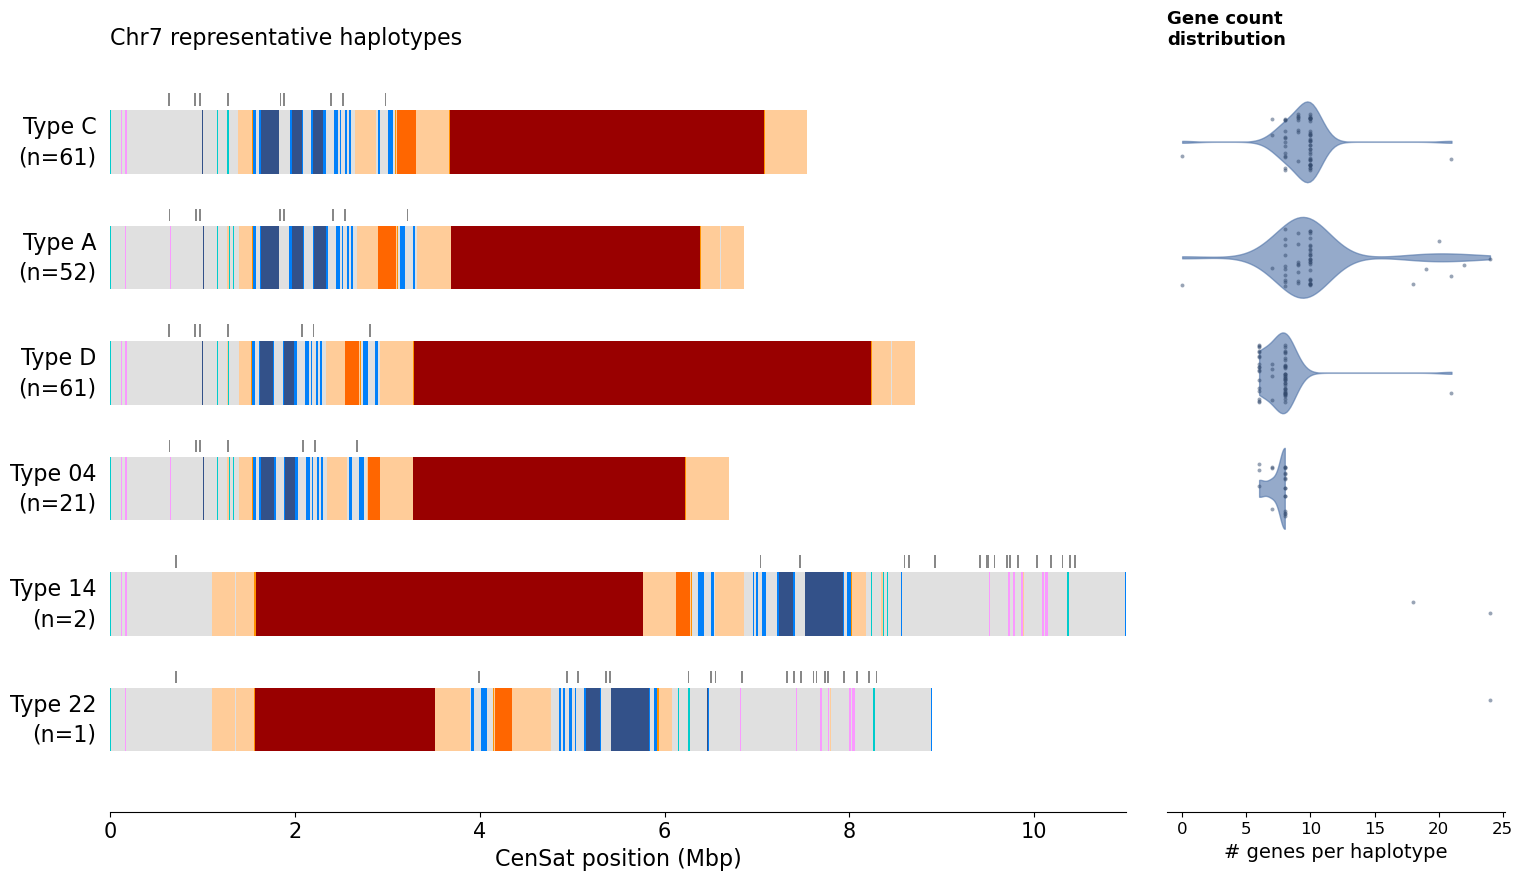

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.path as mpath

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_COLOR = "#888888"
GENE_H     = 0.18

# ── rebuild focus_cn_map ──────────────────────────────────────────────────────
chr7_genes_df = annot_filt_clean[
    (annot_filt_clean["chrom"] == CHROM) &
    (annot_filt_clean["biotype_class"].isin({"protein-coding", "lncRNA"}))
].copy()

chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)
chr7_hap_counts = chr7_genes_df.groupby(["sample_id","haplotype"]).size().reset_index(name="n")
focus_cn = (chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
            .groupby(["sample_id","haplotype"]).size().reset_index(name="cn"))
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

# ── rebuild region_idx ────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── load assignments + summary ────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[['sample_hap', 'structural_type']].copy()
struct_df['cn'] = struct_df['sample_hap'].map(focus_cn_map).fillna(0).astype(int)

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)
rep_map = dict(zip(summary_df['structural_type'], summary_df['representative_sample_hap']))

# ── manual groupings ──────────────────────────────────────────────────────────
MANUAL_GROUPS = {
    'Type A': ['chr7_type_003', 'chr7_type_007'],
    'Type B': ['chr7_type_036', 'chr7_type_038', 'chr7_type_040', 'chr7_type_016',
               'chr7_type_008', 'chr7_type_012', 'chr7_type_013', 'chr7_type_028'],
    'Type C': ['chr7_type_023', 'chr7_type_037', 'chr7_type_035', 'chr7_type_002',
               'chr7_type_010', 'chr7_type_018'],
    'Type D': ['chr7_type_027', 'chr7_type_001'],
    'Type E': ['chr7_type_034', 'chr7_type_026', 'chr7_type_024', 'chr7_type_015', 'chr7_type_017'],
    'Type F': ['chr7_type_005', 'chr7_type_033'],
}

orig_to_manual = {t: manual for manual, types in MANUAL_GROUPS.items() for t in types}
struct_df['Manual_Typing']  = struct_df['structural_type'].map(lambda t: orig_to_manual.get(t, t))
summary_df['Manual_Typing'] = summary_df['structural_type'].map(lambda t: orig_to_manual.get(t, t))

# ── type order ────────────────────────────────────────────────────────────────
ungrouped = [t for t in struct_df['Manual_Typing'].unique() if t not in MANUAL_GROUPS]
ungrouped_sorted = sorted(ungrouped, key=lambda t: -struct_df[struct_df['Manual_Typing'] == t].shape[0])
keep_ungrouped = [t for t in ungrouped_sorted
                  if struct_df[struct_df['Manual_Typing'] == t].shape[0] >= 2
                  or t == 'chr7_type_014']

def dominant_cn_manual(mtype):
    vals = struct_df[struct_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().idxmax()

def dominant_cn_count(mtype):
    vals = struct_df[struct_df['Manual_Typing'] == mtype]['cn']
    return vals.value_counts().max()

top4 = sorted(
    list(MANUAL_GROUPS.keys()) + keep_ungrouped,
    key=lambda t: -struct_df[struct_df['Manual_Typing'] == t].shape[0]
)[:4]

type_order_plot = sorted(top4, key=lambda t: (-dominant_cn_manual(t), -dominant_cn_count(t)))
for extra in ['chr7_type_014', 'chr7_type_022']:
    if extra not in type_order_plot:
        type_order_plot.append(extra)

plot_df = struct_df[struct_df['Manual_Typing'].isin(type_order_plot)].copy()
n_types = len(type_order_plot)

# ── per-haplotype gene counts for violin ─────────────────────────────────────
hap_gene_counts = (
    chr7_genes_df.groupby(["sample_id", "haplotype"])
    .size().reset_index(name="n_genes")
)
hap_gene_counts["sample_hap"] = hap_gene_counts["sample_id"] + "." + hap_gene_counts["haplotype"]
plot_df = plot_df.merge(hap_gene_counts[["sample_hap","n_genes"]], on="sample_hap", how="left")
plot_df["n_genes"] = plot_df["n_genes"].fillna(0).astype(int)

# ── representative haplotype ──────────────────────────────────────────────────
def manual_rep(mtype):
    dom_cn = dominant_cn_manual(mtype)
    candidates = plot_df[
        (plot_df['Manual_Typing'] == mtype) & (plot_df['cn'] == dom_cn)
    ]['sample_hap'].tolist()
    for sample_hap in candidates:
        parts = sample_hap.rsplit('.', 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    for sample_hap in plot_df[plot_df['Manual_Typing'] == mtype]['sample_hap'].tolist():
        parts = sample_hap.rsplit('.', 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    return ''

# ── max array size ────────────────────────────────────────────────────────────
max_size_mbp = 0
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

# ── markers ───────────────────────────────────────────────────────────────────
CSAT_H = 0.55
verts = np.array([[-0.07, -0.5], [0.07, -0.5], [0.07, 0.5], [-0.07, 0.5], [-0.07, -0.5]])
gene_marker = mpath.Path(verts)

# ── figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, n_types * 1.4 + 1.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.06)
ax_ann    = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1])

for yi, mtype in enumerate(type_order_plot):
    rep = manual_rep(mtype)
    parts = rep.rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    rs = region['region_start']

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    all_genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                               (chr7_genes_df['haplotype'] == hap)]
    for _, g in all_genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2, marker=gene_marker, s=80,
                       color=GENE_COLOR, edgecolors='none', zorder=5, clip_on=False)

    n_hap = plot_df[plot_df['Manual_Typing'] == mtype].shape[0]
    label = mtype if mtype in MANUAL_GROUPS else mtype.replace('chr7_type_0', 'Type ').replace('chr7_type_', 'Type ')
    ax_ann.text(-0.15, yi, f"{label}\n(n={n_hap})",
                ha='right', va='center', fontsize=16, linespacing=1.4)

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-0.8, n_types - 0.2)
ax_ann.invert_yaxis()
ax_ann.set_xlabel("CenSat position (Mbp)", fontsize=16)
ax_ann.set_yticks([])
ax_ann.tick_params(axis='x', labelsize=15)
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.set_title("Chr7 representative haplotypes", fontsize=16, loc='left', pad=-15)

# ── horizontal violin: # genes per haplotype ─────────────────────────────────
def darken(c, f=0.65):
    r, g, b, *_ = mcolors.to_rgba(c)
    return (r*f, g*f, b*f, 1)

VIOL_COLOR = "#4E72A7"

for yi, mtype in enumerate(type_order_plot):
    vals = plot_df[plot_df['Manual_Typing'] == mtype]['n_genes'].dropna().values
    if len(vals) >= 3:
        parts = ax_violin.violinplot(vals, positions=[yi], widths=0.7,
                                     showextrema=False, showmedians=False,
                                     vert=False)
        for pc in parts['bodies']:
            pc.set_facecolor(VIOL_COLOR)
            pc.set_alpha(0.6)
            pc.set_edgecolor(VIOL_COLOR)
    if len(vals) > 0:
        jitter = np.random.uniform(-0.25, 0.25, size=len(vals))
        ax_violin.scatter(vals, np.full(len(vals), yi) + jitter,
                          color=darken(VIOL_COLOR), alpha=0.5, s=8,
                          linewidths=0, zorder=6)

ax_violin.set_ylim(-0.8, n_types - 0.2)
ax_violin.invert_yaxis()
ax_violin.set_yticks([])
ax_violin.set_xlabel("# genes per haplotype", fontsize=14)
ax_violin.spines[['top', 'right', 'left']].set_visible(False)
ax_violin.tick_params(axis='x', labelsize=12)
ax_violin.set_title("Gene count\ndistribution", fontsize=13, fontweight='bold',
                    loc='left', pad=4)

plt.tight_layout()
plt.show()


/data/tmp/ipykernel_240334/1135695733.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


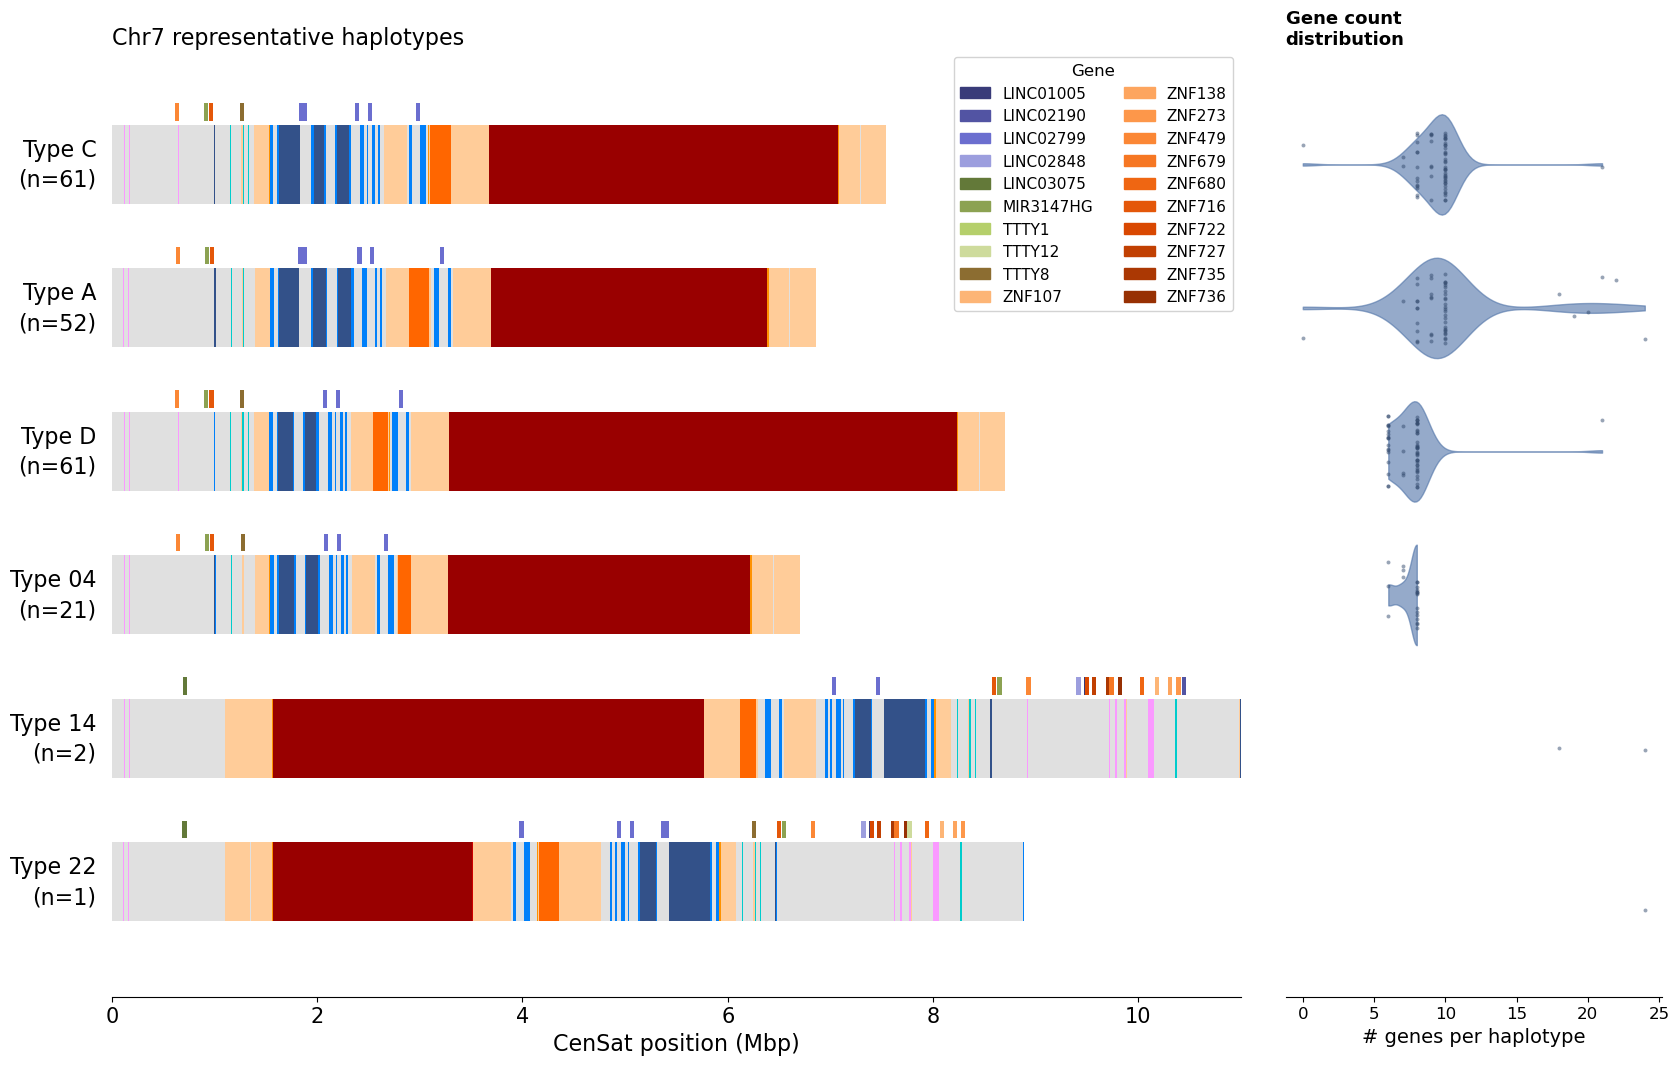

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.path as mpath

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_H     = 0.18

# ── rebuild focus_cn_map ──────────────────────────────────────────────────────
chr7_genes_df = annot_filt_clean[
    (annot_filt_clean["chrom"] == CHROM) &
    (annot_filt_clean["biotype_class"].isin({"protein-coding", "lncRNA"}))
].copy()

chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)
chr7_hap_counts = chr7_genes_df.groupby(["sample_id","haplotype"]).size().reset_index(name="n")
focus_cn = (chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
            .groupby(["sample_id","haplotype"]).size().reset_index(name="cn"))
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

# ── rebuild region_idx ────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── load assignments + summary ────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[["sample_hap", "structural_type"]].copy()
struct_df["cn"] = struct_df["sample_hap"].map(focus_cn_map).fillna(0).astype(int)

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)

# ── manual groupings ──────────────────────────────────────────────────────────
MANUAL_GROUPS = {
    'Type A': ['chr7_type_003', 'chr7_type_007'],
    'Type B': ['chr7_type_036', 'chr7_type_038', 'chr7_type_040', 'chr7_type_016',
               'chr7_type_008', 'chr7_type_012', 'chr7_type_013', 'chr7_type_028'],
    'Type C': ['chr7_type_023', 'chr7_type_037', 'chr7_type_035', 'chr7_type_002',
               'chr7_type_010', 'chr7_type_018'],
    'Type D': ['chr7_type_027', 'chr7_type_001'],
    'Type E': ['chr7_type_034', 'chr7_type_026', 'chr7_type_024', 'chr7_type_015', 'chr7_type_017'],
    'Type F': ['chr7_type_005', 'chr7_type_033'],
}

orig_to_manual = {t: manual for manual, types in MANUAL_GROUPS.items() for t in types}
struct_df["Manual_Typing"]  = struct_df["structural_type"].map(lambda t: orig_to_manual.get(t, t))
summary_df["Manual_Typing"] = summary_df["structural_type"].map(lambda t: orig_to_manual.get(t, t))

# ── type order ────────────────────────────────────────────────────────────────
ungrouped = [t for t in struct_df["Manual_Typing"].unique() if t not in MANUAL_GROUPS]
ungrouped_sorted = sorted(ungrouped, key=lambda t: -struct_df[struct_df["Manual_Typing"] == t].shape[0])
keep_ungrouped = [t for t in ungrouped_sorted
                  if struct_df[struct_df["Manual_Typing"] == t].shape[0] >= 2
                  or t == 'chr7_type_014']

def dominant_cn_manual(mtype):
    vals = struct_df[struct_df["Manual_Typing"] == mtype]["cn"]
    return vals.value_counts().idxmax()

def dominant_cn_count(mtype):
    vals = struct_df[struct_df["Manual_Typing"] == mtype]["cn"]
    return vals.value_counts().max()

top4 = sorted(
    list(MANUAL_GROUPS.keys()) + keep_ungrouped,
    key=lambda t: -struct_df[struct_df["Manual_Typing"] == t].shape[0]
)[:4]

type_order_plot = sorted(top4, key=lambda t: (-dominant_cn_manual(t), -dominant_cn_count(t)))
for extra in ['chr7_type_014', 'chr7_type_022']:
    if extra not in type_order_plot:
        type_order_plot.append(extra)

plot_df = struct_df[struct_df["Manual_Typing"].isin(type_order_plot)].copy()
n_types = len(type_order_plot)

# ── per-haplotype gene counts for violin ─────────────────────────────────────
hap_gene_counts = (
    chr7_genes_df.groupby(["sample_id", "haplotype"])
    .size().reset_index(name="n_genes")
)
hap_gene_counts["sample_hap"] = hap_gene_counts["sample_id"] + "." + hap_gene_counts["haplotype"]
plot_df = plot_df.merge(hap_gene_counts[["sample_hap","n_genes"]], on="sample_hap", how="left")
plot_df["n_genes"] = plot_df["n_genes"].fillna(0).astype(int)

# ── representative haplotype ──────────────────────────────────────────────────
def manual_rep(mtype):
    dom_cn = dominant_cn_manual(mtype)
    candidates = plot_df[
        (plot_df["Manual_Typing"] == mtype) & (plot_df["cn"] == dom_cn)
    ]["sample_hap"].tolist()
    for sample_hap in candidates:
        parts = sample_hap.rsplit(".", 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    for sample_hap in plot_df[plot_df["Manual_Typing"] == mtype]["sample_hap"].tolist():
        parts = sample_hap.rsplit(".", 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    return ""

# ── max array size ────────────────────────────────────────────────────────────
max_size_mbp = 0
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit(".", 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region["region_end"] - region["region_start"]) / 1e6)

# ── gene color map ────────────────────────────────────────────────────────────
rep_genes = set()
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit(".", 1)
    if len(parts) != 2: continue
    sid, hap = parts
    g_names = chr7_genes_df[
        (chr7_genes_df["sample_id"] == sid) &
        (chr7_genes_df["haplotype"] == hap)
    ]["gene_name"].unique()
    rep_genes.update(g_names)

all_gene_names = sorted(rep_genes)
znf_genes   = sorted(g for g in all_gene_names if g.upper().startswith("ZNF"))
other_genes = sorted(g for g in all_gene_names if not g.upper().startswith("ZNF"))

# ZNFs: shades of orange-red from Oranges colormap
znf_colors = plt.cm.Oranges(np.linspace(0.35, 0.92, max(len(znf_genes), 1)))
znf_color_map = {g: znf_colors[i] for i, g in enumerate(znf_genes)}

# non-ZNFs: distinct colors from qualitative palettes
other_palette = list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
other_color_map = {g: other_palette[i % len(other_palette)] for i, g in enumerate(other_genes)}

gene_color_map = {**znf_color_map, **other_color_map}

# ── markers ───────────────────────────────────────────────────────────────────
CSAT_H = 0.55
verts = np.array([[-0.12, -0.5], [0.12, -0.5], [0.12, 0.5], [-0.12, 0.5], [-0.12, -0.5]])
gene_marker = mpath.Path(verts)


# ── figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, n_types * 1.8 + 1.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.06)
ax_ann    = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1])

for yi, mtype in enumerate(type_order_plot):
    rep = manual_rep(mtype)
    parts = rep.rsplit(".", 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    rs = region["region_start"]

    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg["start"], yi - CSAT_H/2), seg["end"] - seg["start"], CSAT_H,
            color=seg["color"], linewidth=0))

    all_genes = chr7_genes_df[
        (chr7_genes_df["sample_id"] == sid) &
        (chr7_genes_df["haplotype"] == hap)
    ]
    for _, g in all_genes.iterrows():
        g_mid = ((g["start"] + g["end"]) / 2 - rs) / 1e6
        gcol  = gene_color_map.get(g["gene_name"], "#888888")
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2,
               marker=gene_marker, s=160,
               color=gcol, edgecolors="none", zorder=5, clip_on=False)


    n_hap = plot_df[plot_df["Manual_Typing"] == mtype].shape[0]
    label = mtype if mtype in MANUAL_GROUPS else mtype.replace("chr7_type_0", "Type ").replace("chr7_type_", "Type ")
    ax_ann.text(-0.15, yi, f"{label}\n(n={n_hap})",
                ha="right", va="center", fontsize=16, linespacing=1.4)

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-0.8, n_types - 0.2)
ax_ann.invert_yaxis()
ax_ann.set_xlabel("CenSat position (Mbp)", fontsize=16)
ax_ann.set_yticks([])
ax_ann.tick_params(axis="x", labelsize=15)
ax_ann.spines[["top", "right", "left"]].set_visible(False)
ax_ann.set_title("Chr7 representative haplotypes", fontsize=16, loc="left", pad=-15)

# ── legend: upper right, larger font ─────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=gene_color_map[g], label=g) for g in all_gene_names
]
ax_ann.legend(handles=legend_handles, title="Gene", fontsize=11, title_fontsize=12,
              loc="upper right", ncol=2,
              frameon=True, framealpha=0.85)

# ── horizontal violin: # genes per haplotype ─────────────────────────────────
def darken(c, f=0.65):
    r, g, b, *_ = mcolors.to_rgba(c)
    return (r*f, g*f, b*f, 1)

VIOL_COLOR = "#4E72A7"

for yi, mtype in enumerate(type_order_plot):
    vals = plot_df[plot_df["Manual_Typing"] == mtype]["n_genes"].dropna().values
    if len(vals) >= 3:
        vparts = ax_violin.violinplot(vals, positions=[yi], widths=0.7,
                                      showextrema=False, showmedians=False,
                                      vert=False)
        for pc in vparts["bodies"]:
            pc.set_facecolor(VIOL_COLOR)
            pc.set_alpha(0.6)
            pc.set_edgecolor(VIOL_COLOR)
    if len(vals) > 0:
        jitter = np.random.uniform(-0.25, 0.25, size=len(vals))
        ax_violin.scatter(vals, np.full(len(vals), yi) + jitter,
                          color=darken(VIOL_COLOR), alpha=0.5, s=8,
                          linewidths=0, zorder=6)

ax_violin.set_ylim(-0.8, n_types - 0.2)
ax_violin.invert_yaxis()
ax_violin.set_yticks([])
ax_violin.set_xlabel("# genes per haplotype", fontsize=14)
ax_violin.spines[["top", "right", "left"]].set_visible(False)
ax_violin.tick_params(axis="x", labelsize=12)
ax_violin.set_title("Gene count\ndistribution", fontsize=13, fontweight="bold",
                    loc="left", pad=4)

plt.tight_layout()
plt.show()


/data/tmp/ipykernel_240334/2631259372.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap("plasma", max_cn)
/data/tmp/ipykernel_240334/2631259372.py:321: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


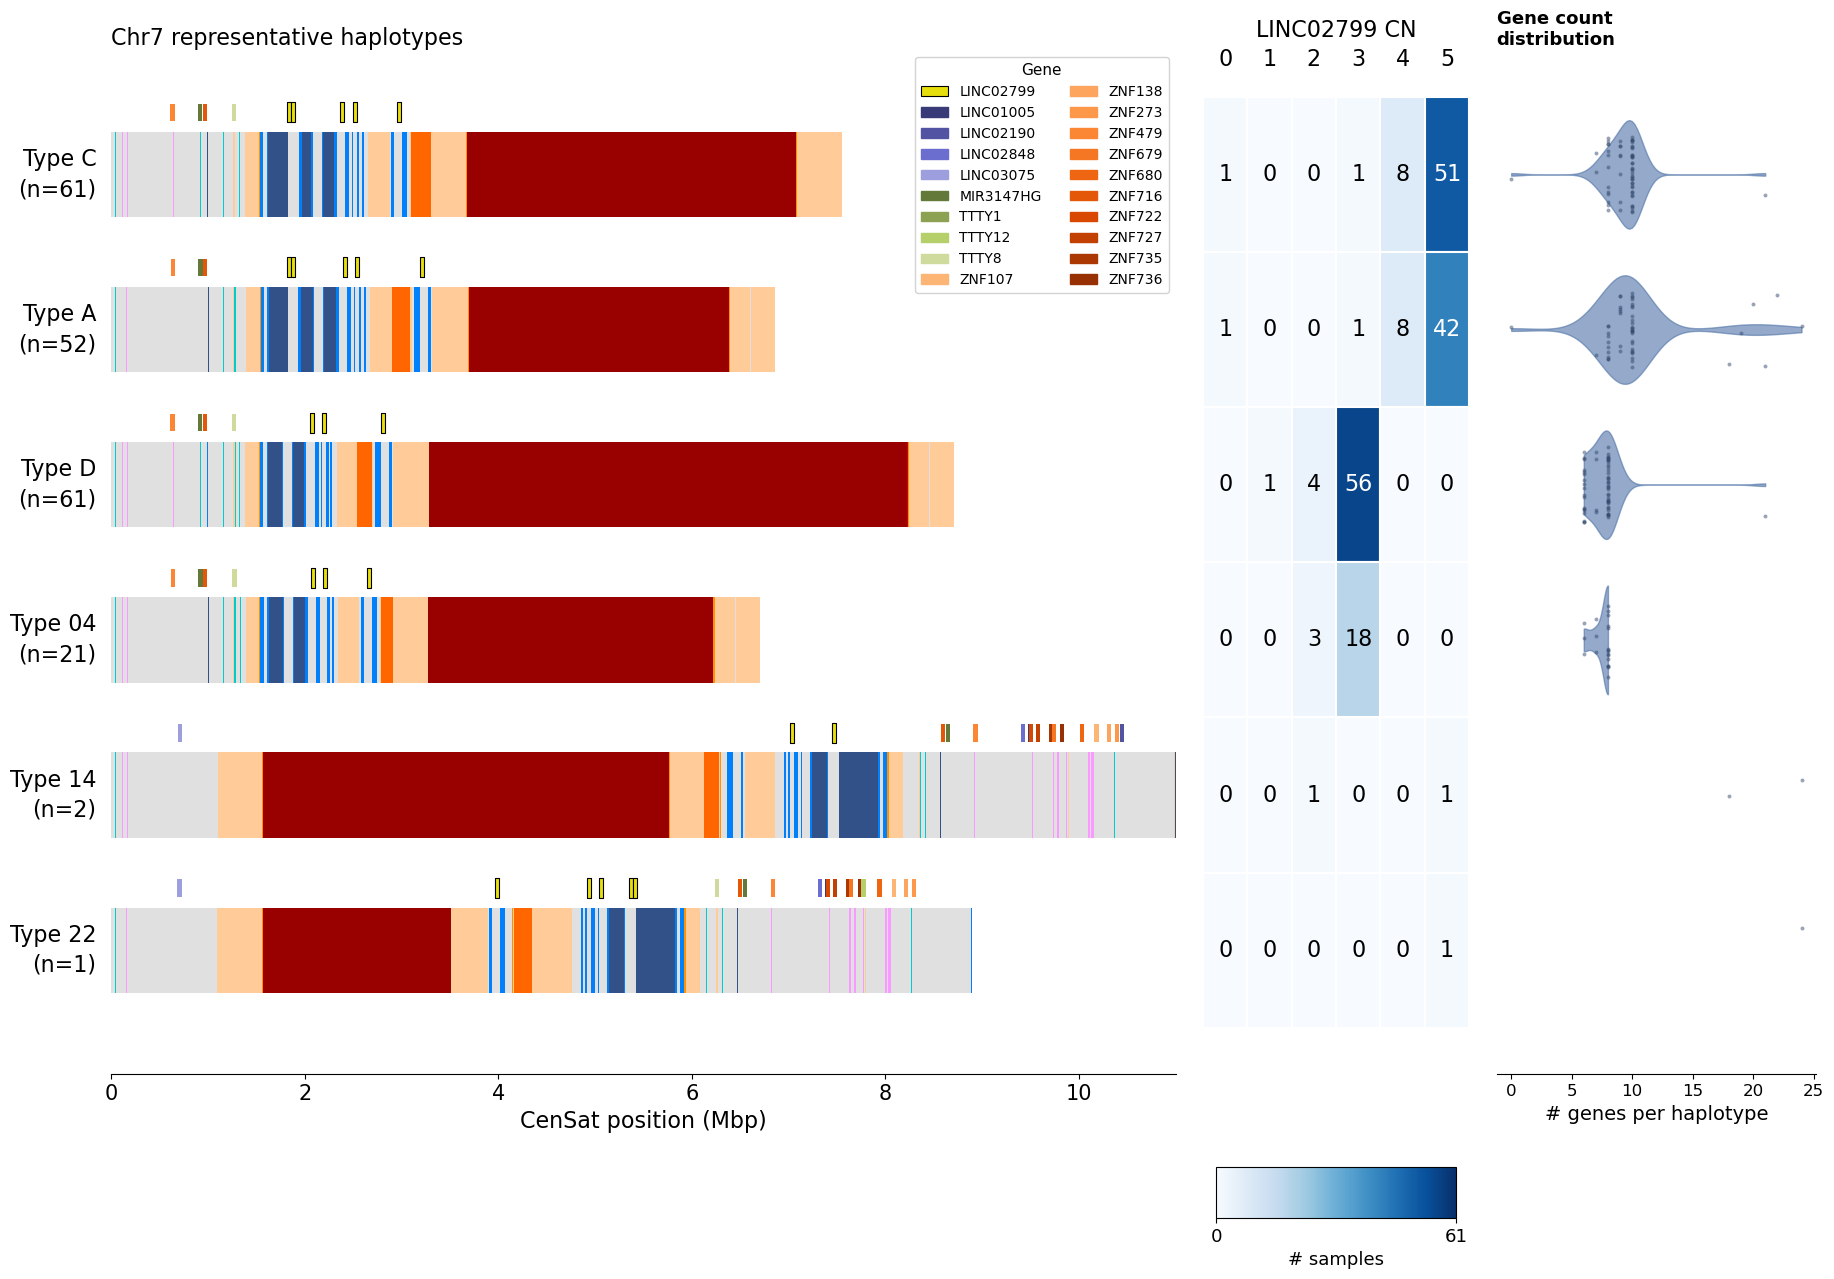

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.path as mpath
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

CHROM      = "chr7"
FOCUS_GENE = "LINC02799"
GENE_FOCUS = "#e6df0d"
CSAT_H     = 0.55
GENE_H     = 0.25

# ── rebuild focus_cn_map ──────────────────────────────────────────────────────
chr7_genes_df = annot_filt_clean[
    (annot_filt_clean["chrom"] == CHROM) &
    (annot_filt_clean["biotype_class"].isin({"protein-coding", "lncRNA"}))
].copy()

chr7_genes_df["haplotype"] = chr7_genes_df["haplotype"].astype(str)
chr7_hap_counts = chr7_genes_df.groupby(["sample_id","haplotype"]).size().reset_index(name="n")
focus_cn = (chr7_genes_df[chr7_genes_df["gene_name"] == FOCUS_GENE]
            .groupby(["sample_id","haplotype"]).size().reset_index(name="cn"))
focus_cn = chr7_hap_counts[["sample_id","haplotype"]].merge(focus_cn, on=["sample_id","haplotype"], how="left")
focus_cn["cn"] = focus_cn["cn"].fillna(0).astype(int)
focus_cn_map = {f"{r['sample_id']}.{r['haplotype']}": r["cn"] for _, r in focus_cn.iterrows()}

max_cn   = focus_cn["cn"].max()
cmap_obj = cm.get_cmap("plasma", max_cn)
cn_palette = {0: "#d9d9d9"}
for i in range(1, max_cn + 1):
    cn_palette[i] = mcolors.to_hex(cmap_obj(i - 1))

# ── rebuild region_idx ────────────────────────────────────────────────────────
chrom_regions = regions_df[(regions_df["chrom"] == CHROM) & (regions_df["pass_qc"] == True)].copy()
chrom_regions["haplotype"] = chrom_regions["haplotype"].astype(str)
region_idx = {(r["sample_id"], r["haplotype"]): r for _, r in chrom_regions.iterrows()}

# ── load assignments + summary ────────────────────────────────────────────────
struct_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_assignments.tsv',
    sep='\t'
)[["sample_hap", "structural_type"]].copy()
struct_df["cn"] = struct_df["sample_hap"].map(focus_cn_map).fillna(0).astype(int)

summary_df = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_arrays/element_alignment/tables/chr7_haplotype_structure_summary.tsv',
    sep='\t'
)

# ── manual groupings ──────────────────────────────────────────────────────────
MANUAL_GROUPS = {
    'Type A': ['chr7_type_003', 'chr7_type_007'],
    'Type B': ['chr7_type_036', 'chr7_type_038', 'chr7_type_040', 'chr7_type_016',
               'chr7_type_008', 'chr7_type_012', 'chr7_type_013', 'chr7_type_028'],
    'Type C': ['chr7_type_023', 'chr7_type_037', 'chr7_type_035', 'chr7_type_002',
               'chr7_type_010', 'chr7_type_018'],
    'Type D': ['chr7_type_027', 'chr7_type_001'],
    'Type E': ['chr7_type_034', 'chr7_type_026', 'chr7_type_024', 'chr7_type_015', 'chr7_type_017'],
    'Type F': ['chr7_type_005', 'chr7_type_033'],
}

orig_to_manual = {t: manual for manual, types in MANUAL_GROUPS.items() for t in types}
struct_df["Manual_Typing"]  = struct_df["structural_type"].map(lambda t: orig_to_manual.get(t, t))
summary_df["Manual_Typing"] = summary_df["structural_type"].map(lambda t: orig_to_manual.get(t, t))

# ── type order ────────────────────────────────────────────────────────────────
ungrouped = [t for t in struct_df["Manual_Typing"].unique() if t not in MANUAL_GROUPS]
ungrouped_sorted = sorted(ungrouped, key=lambda t: -struct_df[struct_df["Manual_Typing"] == t].shape[0])
keep_ungrouped = [t for t in ungrouped_sorted
                  if struct_df[struct_df["Manual_Typing"] == t].shape[0] >= 2
                  or t == 'chr7_type_014']

def dominant_cn_manual(mtype):
    vals = struct_df[struct_df["Manual_Typing"] == mtype]["cn"]
    return vals.value_counts().idxmax()

def dominant_cn_count(mtype):
    vals = struct_df[struct_df["Manual_Typing"] == mtype]["cn"]
    return vals.value_counts().max()

top4 = sorted(
    list(MANUAL_GROUPS.keys()) + keep_ungrouped,
    key=lambda t: -struct_df[struct_df["Manual_Typing"] == t].shape[0]
)[:4]

type_order_plot = sorted(top4, key=lambda t: (-dominant_cn_manual(t), -dominant_cn_count(t)))
for extra in ['chr7_type_014', 'chr7_type_022']:
    if extra not in type_order_plot:
        type_order_plot.append(extra)

plot_df = struct_df[struct_df["Manual_Typing"].isin(type_order_plot)].copy()
n_types = len(type_order_plot)

# ── per-haplotype gene counts for violin ─────────────────────────────────────
hap_gene_counts = (
    chr7_genes_df.groupby(["sample_id", "haplotype"])
    .size().reset_index(name="n_genes")
)
hap_gene_counts["sample_hap"] = hap_gene_counts["sample_id"] + "." + hap_gene_counts["haplotype"]
plot_df = plot_df.merge(hap_gene_counts[["sample_hap","n_genes"]], on="sample_hap", how="left")
plot_df["n_genes"] = plot_df["n_genes"].fillna(0).astype(int)

# ── representative haplotype ──────────────────────────────────────────────────
def manual_rep(mtype):
    dom_cn = dominant_cn_manual(mtype)
    candidates = plot_df[
        (plot_df["Manual_Typing"] == mtype) & (plot_df["cn"] == dom_cn)
    ]["sample_hap"].tolist()
    for sample_hap in candidates:
        parts = sample_hap.rsplit(".", 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    for sample_hap in plot_df[plot_df["Manual_Typing"] == mtype]["sample_hap"].tolist():
        parts = sample_hap.rsplit(".", 1)
        if len(parts) != 2: continue
        sid, hap = parts
        if region_idx.get((sid, hap)) is None: continue
        if bed_map.get((sid, hap)) is None: continue
        return sample_hap
    return ""

# ── max array size ────────────────────────────────────────────────────────────
max_size_mbp = 0
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit(".", 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region["region_end"] - region["region_start"]) / 1e6)

# ── CN heatmap counts ─────────────────────────────────────────────────────────
cn_bins   = [0, 1, 2, 3, 4, 5]
hm_counts = np.zeros((n_types, len(cn_bins)), dtype=int)
for ti, mtype in enumerate(type_order_plot):
    vals = plot_df[plot_df["Manual_Typing"] == mtype]["cn"].values
    for ci, cn_val in enumerate(cn_bins):
        hm_counts[ti, ci] = (vals == cn_val).sum()

# ── gene color map: ZNF family (Oranges) + others (qualitative) ───────────────
rep_genes = set()
for mtype in type_order_plot:
    rep = manual_rep(mtype)
    parts = rep.rsplit(".", 1)
    if len(parts) != 2: continue
    sid, hap = parts
    g_names = chr7_genes_df[
        (chr7_genes_df["sample_id"] == sid) &
        (chr7_genes_df["haplotype"] == hap) &
        (chr7_genes_df["gene_name"] != FOCUS_GENE)
    ]["gene_name"].unique()
    rep_genes.update(g_names)

all_gene_names = sorted(rep_genes)
znf_genes      = sorted(g for g in all_gene_names if g.upper().startswith("ZNF"))
other_genes    = sorted(g for g in all_gene_names if not g.upper().startswith("ZNF"))

znf_colors      = plt.cm.Oranges(np.linspace(0.35, 0.92, max(len(znf_genes), 1)))
znf_color_map   = {g: znf_colors[i] for i, g in enumerate(znf_genes)}
other_palette   = list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
other_color_map = {g: other_palette[i % len(other_palette)] for i, g in enumerate(other_genes)}
gene_color_map  = {**znf_color_map, **other_color_map}

# ── markers ───────────────────────────────────────────────────────────────────
verts_focus = np.array([[-0.1,  -0.5], [0.1,  -0.5], [0.1,  0.5], [-0.1,  0.5], [-0.1,  -0.5]])
verts_other = np.array([[-0.12, -0.5], [0.12, -0.5], [0.12, 0.5], [-0.12, 0.5], [-0.12, -0.5]])
focus_marker = mpath.Path(verts_focus)
other_marker = mpath.Path(verts_other)

# ── figure: arrays | CN heatmap | violin ─────────────────────────────────────
fig = plt.figure(figsize=(22, n_types * 1.8 + 2.5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[4, 1, 1.2], wspace=0.05)
ax_ann    = fig.add_subplot(gs[0])
ax_heat   = fig.add_subplot(gs[1])
ax_violin = fig.add_subplot(gs[2])

for yi, mtype in enumerate(type_order_plot):
    rep = manual_rep(mtype)
    parts = rep.rsplit(".", 1)
    if len(parts) != 2: continue
    sid, hap = parts
    region = region_idx.get((sid, hap))
    if region is None: continue
    rs = region["region_start"]

    # censat array
    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg["start"], yi - CSAT_H/2), seg["end"] - seg["start"], CSAT_H,
            color=seg["color"], linewidth=0))

    # other genes (lower zorder)
    for _, g in chr7_genes_df[
        (chr7_genes_df["sample_id"] == sid) &
        (chr7_genes_df["haplotype"] == hap) &
        (chr7_genes_df["gene_name"] != FOCUS_GENE)
    ].iterrows():
        g_mid = ((g["start"] + g["end"]) / 2 - rs) / 1e6
        gcol  = gene_color_map.get(g["gene_name"], "#888888")
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2,
                       marker=other_marker, s=160,
                       color=gcol, edgecolors="none", zorder=5, clip_on=False)

    # LINC02799 on top
    for _, g in chr7_genes_df[
        (chr7_genes_df["sample_id"] == sid) &
        (chr7_genes_df["haplotype"] == hap) &
        (chr7_genes_df["gene_name"] == FOCUS_GENE)
    ].iterrows():
        g_mid = ((g["start"] + g["end"]) / 2 - rs) / 1e6
        ax_ann.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2,
                       marker=focus_marker, s=200,
                       color=GENE_FOCUS, edgecolors="black", linewidths=0.8,
                       zorder=6, clip_on=False)

    n_hap = plot_df[plot_df["Manual_Typing"] == mtype].shape[0]
    label = mtype if mtype in MANUAL_GROUPS else mtype.replace("chr7_type_0", "Type ").replace("chr7_type_", "Type ")
    ax_ann.text(-0.15, yi, f"{label}\n(n={n_hap})",
                ha="right", va="center", fontsize=16, linespacing=1.4)

ax_ann.set_xlim(0, max_size_mbp)
ax_ann.set_ylim(-0.8, n_types - 0.2)
ax_ann.invert_yaxis()
ax_ann.set_xlabel("CenSat position (Mbp)", fontsize=16)
ax_ann.set_yticks([])
ax_ann.tick_params(axis="x", labelsize=15)
ax_ann.spines[["top", "right", "left"]].set_visible(False)
ax_ann.set_title("Chr7 representative haplotypes", fontsize=16, loc="left", pad=-15)

# gene legend: LINC02799 first, then others, 2 columns
legend_handles = [
    mpatches.Patch(facecolor=GENE_FOCUS, edgecolor="black", linewidth=0.8, label=FOCUS_GENE)
] + [
    mpatches.Patch(color=gene_color_map[g], label=g) for g in all_gene_names
]
ax_ann.legend(handles=legend_handles, title="Gene", fontsize=10, title_fontsize=11,
              loc="upper right", ncol=2, frameon=True, framealpha=0.85)

# ── CN heatmap ────────────────────────────────────────────────────────────────
count_max  = plot_df.groupby("Manual_Typing").size().max()
count_cmap = plt.cm.Blues

for ti in range(n_types):
    for ci, cn_val in enumerate(cn_bins):
        count = hm_counts[ti, ci]
        color = count_cmap(count / count_max) if count_max > 0 else count_cmap(0)
        ax_heat.add_patch(mpatches.Rectangle(
            (ci, ti - 0.5), 1, 1, facecolor=color, edgecolor="white", linewidth=1.5))
        ax_heat.text(ci + 0.5, ti, str(count), ha="center", va="center", fontsize=16,
                     color="white" if count / max(count_max, 1) > 0.5 else "black")

ax_heat.set_xlim(0, len(cn_bins))
ax_heat.set_ylim(-0.8, n_types - 0.2)
ax_heat.invert_yaxis()
ax_heat.set_xticks([i + 0.5 for i in range(len(cn_bins))])
ax_heat.set_xticklabels([str(c) for c in cn_bins], fontsize=16)
ax_heat.xaxis.set_label_position("top")
ax_heat.xaxis.tick_top()
ax_heat.tick_params(axis="x", pad=-15, length=0)
ax_heat.set_xlabel(f"{FOCUS_GENE} CN", fontsize=16, labelpad=8)
ax_heat.set_yticks([])
for spine in ax_heat.spines.values():
    spine.set_visible(False)

# colorbar below heatmap using inset_axes (does not resize ax_heat)
sm = ScalarMappable(cmap=count_cmap, norm=Normalize(vmin=0, vmax=count_max))
sm.set_array([])
cax = inset_axes(ax_heat, width="90%", height="5%",
                 loc="lower center",
                 bbox_to_anchor=(0.0, -0.14, 1.0, 1.0),
                 bbox_transform=ax_heat.transAxes,
                 borderpad=0)
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("# samples", fontsize=13)
cb.set_ticks([0, count_max])
cb.set_ticklabels([0, count_max])
cb.ax.tick_params(labelsize=13)

# ── violin: # genes per haplotype ────────────────────────────────────────────
def darken(c, f=0.65):
    r, g, b, *_ = mcolors.to_rgba(c)
    return (r*f, g*f, b*f, 1)

VIOL_COLOR = "#4E72A7"

for yi, mtype in enumerate(type_order_plot):
    vals = plot_df[plot_df["Manual_Typing"] == mtype]["n_genes"].dropna().values
    if len(vals) >= 3:
        vparts = ax_violin.violinplot(vals, positions=[yi], widths=0.7,
                                      showextrema=False, showmedians=False,
                                      vert=False)
        for pc in vparts["bodies"]:
            pc.set_facecolor(VIOL_COLOR)
            pc.set_alpha(0.6)
            pc.set_edgecolor(VIOL_COLOR)
    if len(vals) > 0:
        jitter = np.random.uniform(-0.25, 0.25, size=len(vals))
        ax_violin.scatter(vals, np.full(len(vals), yi) + jitter,
                          color=darken(VIOL_COLOR), alpha=0.5, s=8,
                          linewidths=0, zorder=6)

ax_violin.set_ylim(-0.8, n_types - 0.2)
ax_violin.invert_yaxis()
ax_violin.set_yticks([])
ax_violin.set_xlabel("# genes per haplotype", fontsize=14)
ax_violin.spines[["top", "right", "left"]].set_visible(False)
ax_violin.tick_params(axis="x", labelsize=12)
ax_violin.set_title("Gene count\ndistribution", fontsize=13, fontweight="bold",
                    loc="left", pad=4)

plt.tight_layout()
plt.show()



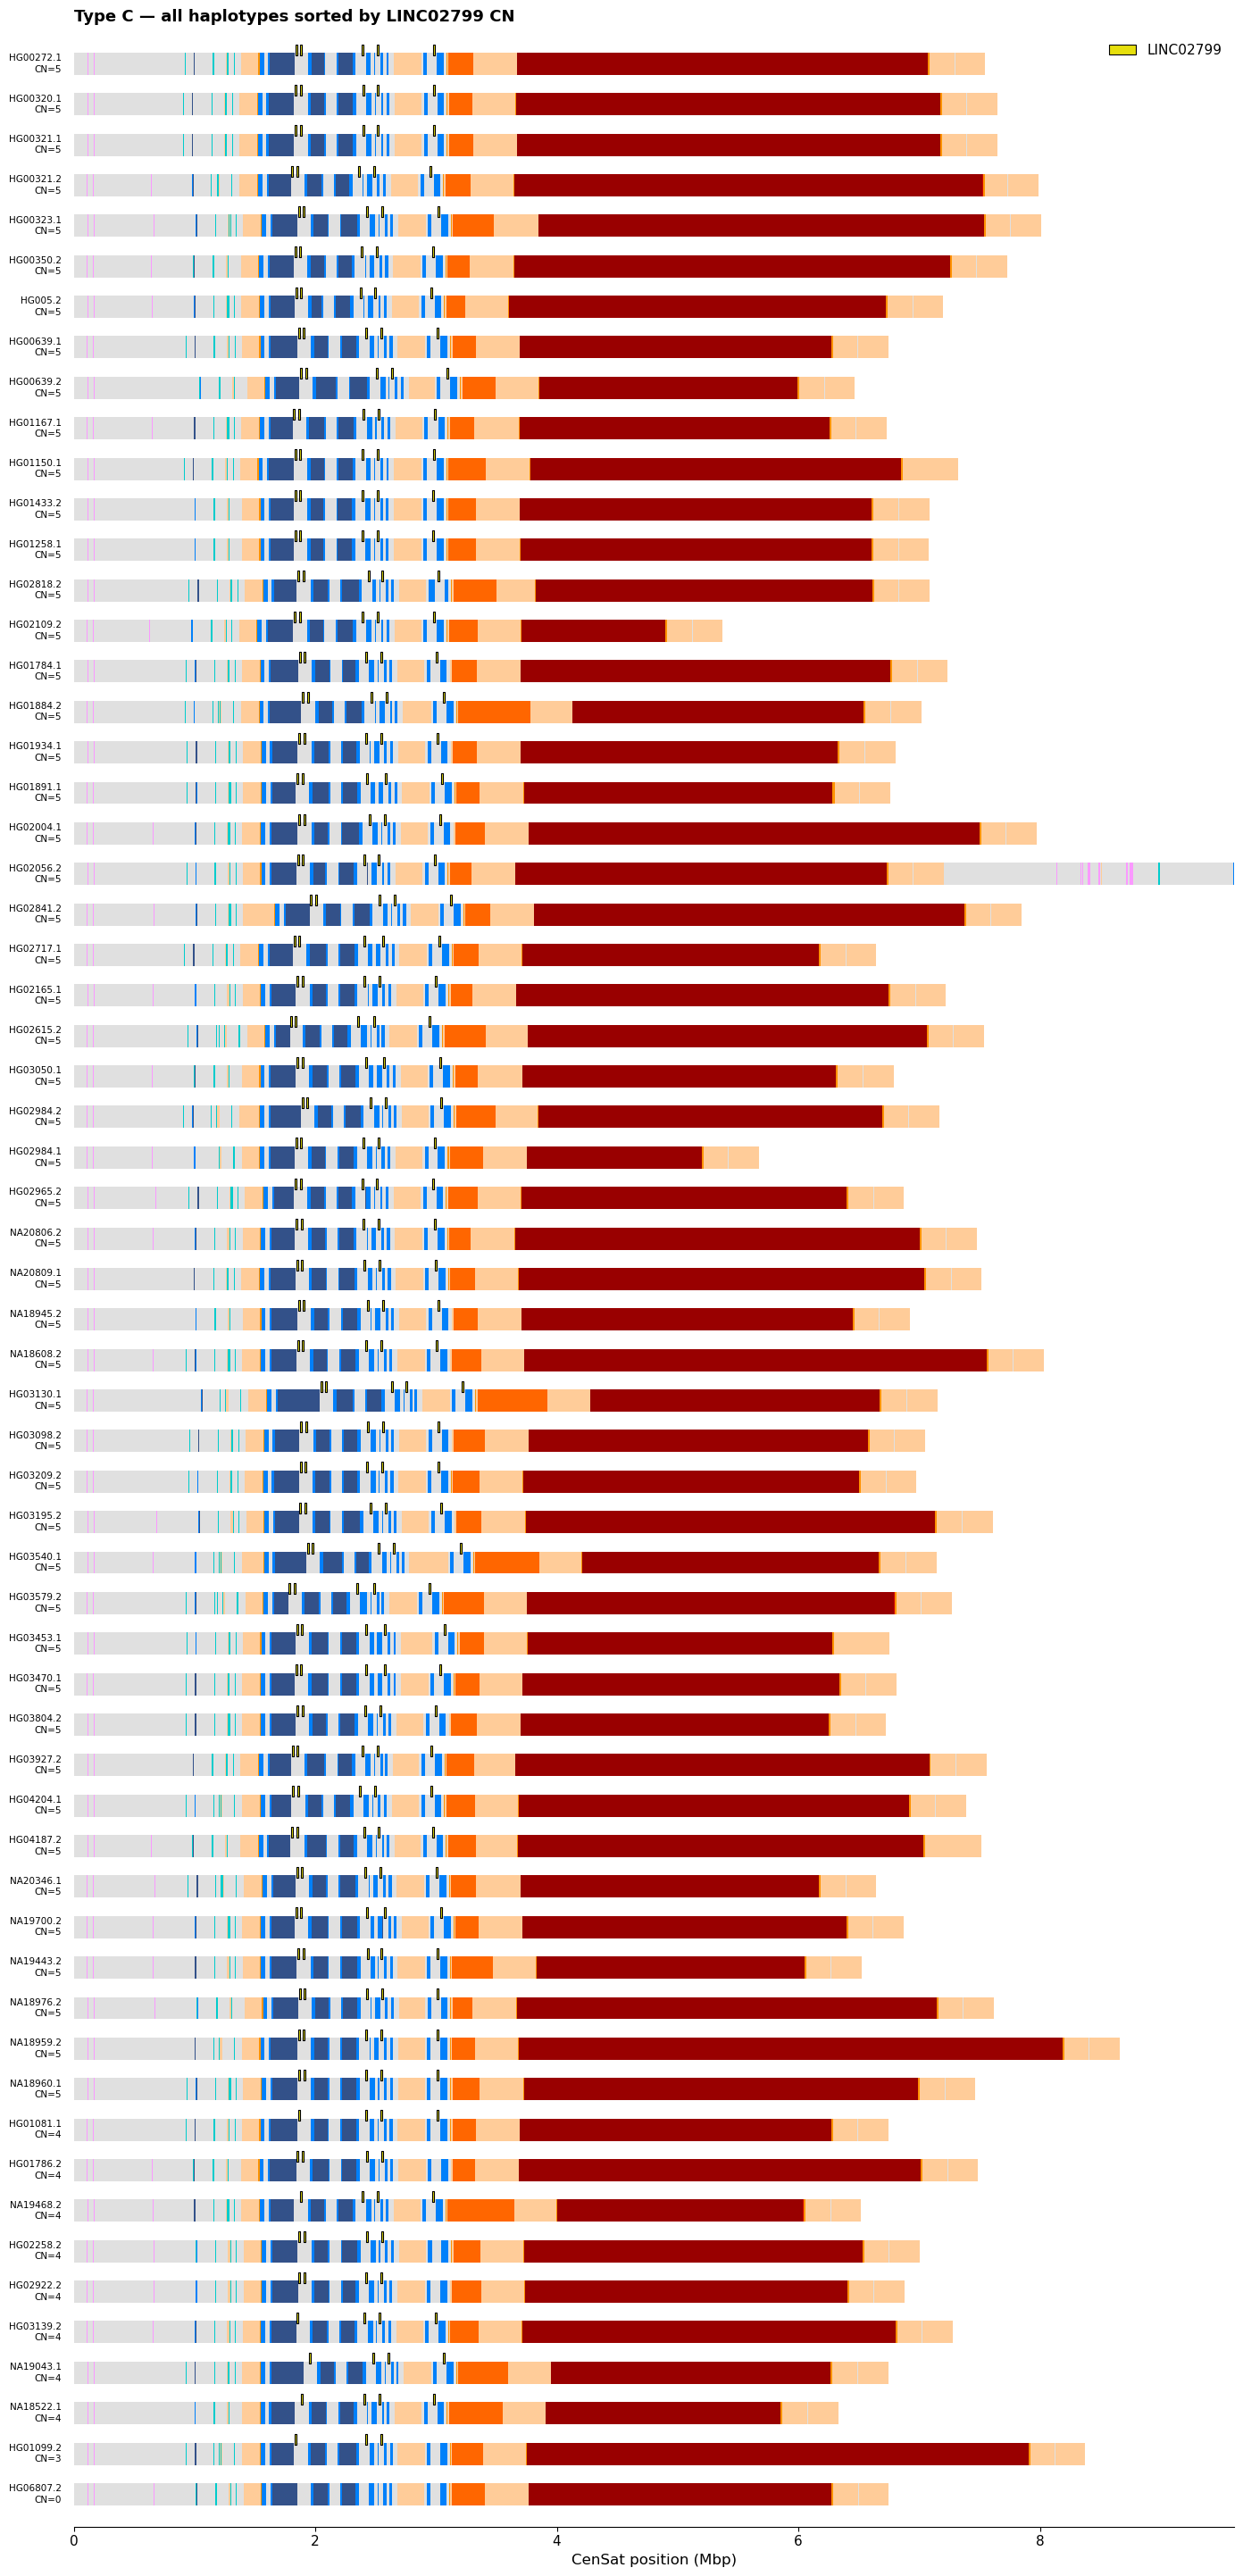

In [72]:
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

CSAT_H  = 0.55
GENE_H  = 0.15
GENE_FOCUS = "#e6df0d"

verts = np.array([[-0.1, -0.5], [0.1, -0.5], [0.1, 0.5], [-0.1, 0.5], [-0.1, -0.5]])
tall_marker = mpath.Path(verts)

# all Type C haplotypes sorted by CN
type_c_df = plot_df[plot_df['Manual_Typing'] == 'Type C'].copy()
type_c_df = type_c_df.sort_values('cn', ascending=False).reset_index(drop=True)

# filter to those with valid region + bed
valid_rows = []
for _, row in type_c_df.iterrows():
    parts = row['sample_hap'].rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    if region_idx.get((sid, hap)) is None: continue
    if bed_map.get((sid, hap)) is None: continue
    valid_rows.append(row)

type_c_df = pd.DataFrame(valid_rows).reset_index(drop=True)
n = len(type_c_df)

# max array size for Type C
max_size_mbp = 0
for _, row in type_c_df.iterrows():
    sid, hap = row['sample_hap'].rsplit('.', 1)
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

fig, ax = plt.subplots(figsize=(14, n * 0.45 + 1.5))

for yi, row in type_c_df.iterrows():
    sid, hap = row['sample_hap'].rsplit('.', 1)
    region = region_idx.get((sid, hap))
    rs = region['region_start']

    for seg in load_censat(sid, hap, region):
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                           (chr7_genes_df['haplotype'] == hap) &
                           (chr7_genes_df['gene_name'] == FOCUS_GENE)]
    for _, g in genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2, marker=tall_marker, s=80,
                   color=GENE_FOCUS, edgecolors='black', linewidths=0.8, zorder=5, clip_on=False)

    ax.text(-0.1, yi, f"{row['sample_hap']}\nCN={row['cn']}",
            ha='right', va='center', fontsize=7.5, linespacing=1.3)

ax.set_xlim(0, max_size_mbp)
ax.set_ylim(-0.8, n - 0.2)
ax.invert_yaxis()
ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=11)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_title("Type C — all haplotypes sorted by LINC02799 CN", fontsize=13,
             fontweight='bold', loc='left', pad=8)
ax.legend(handles=[mpatches.Patch(facecolor=GENE_FOCUS, edgecolor='black',
          linewidth=0.8, label=FOCUS_GENE)],
          loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


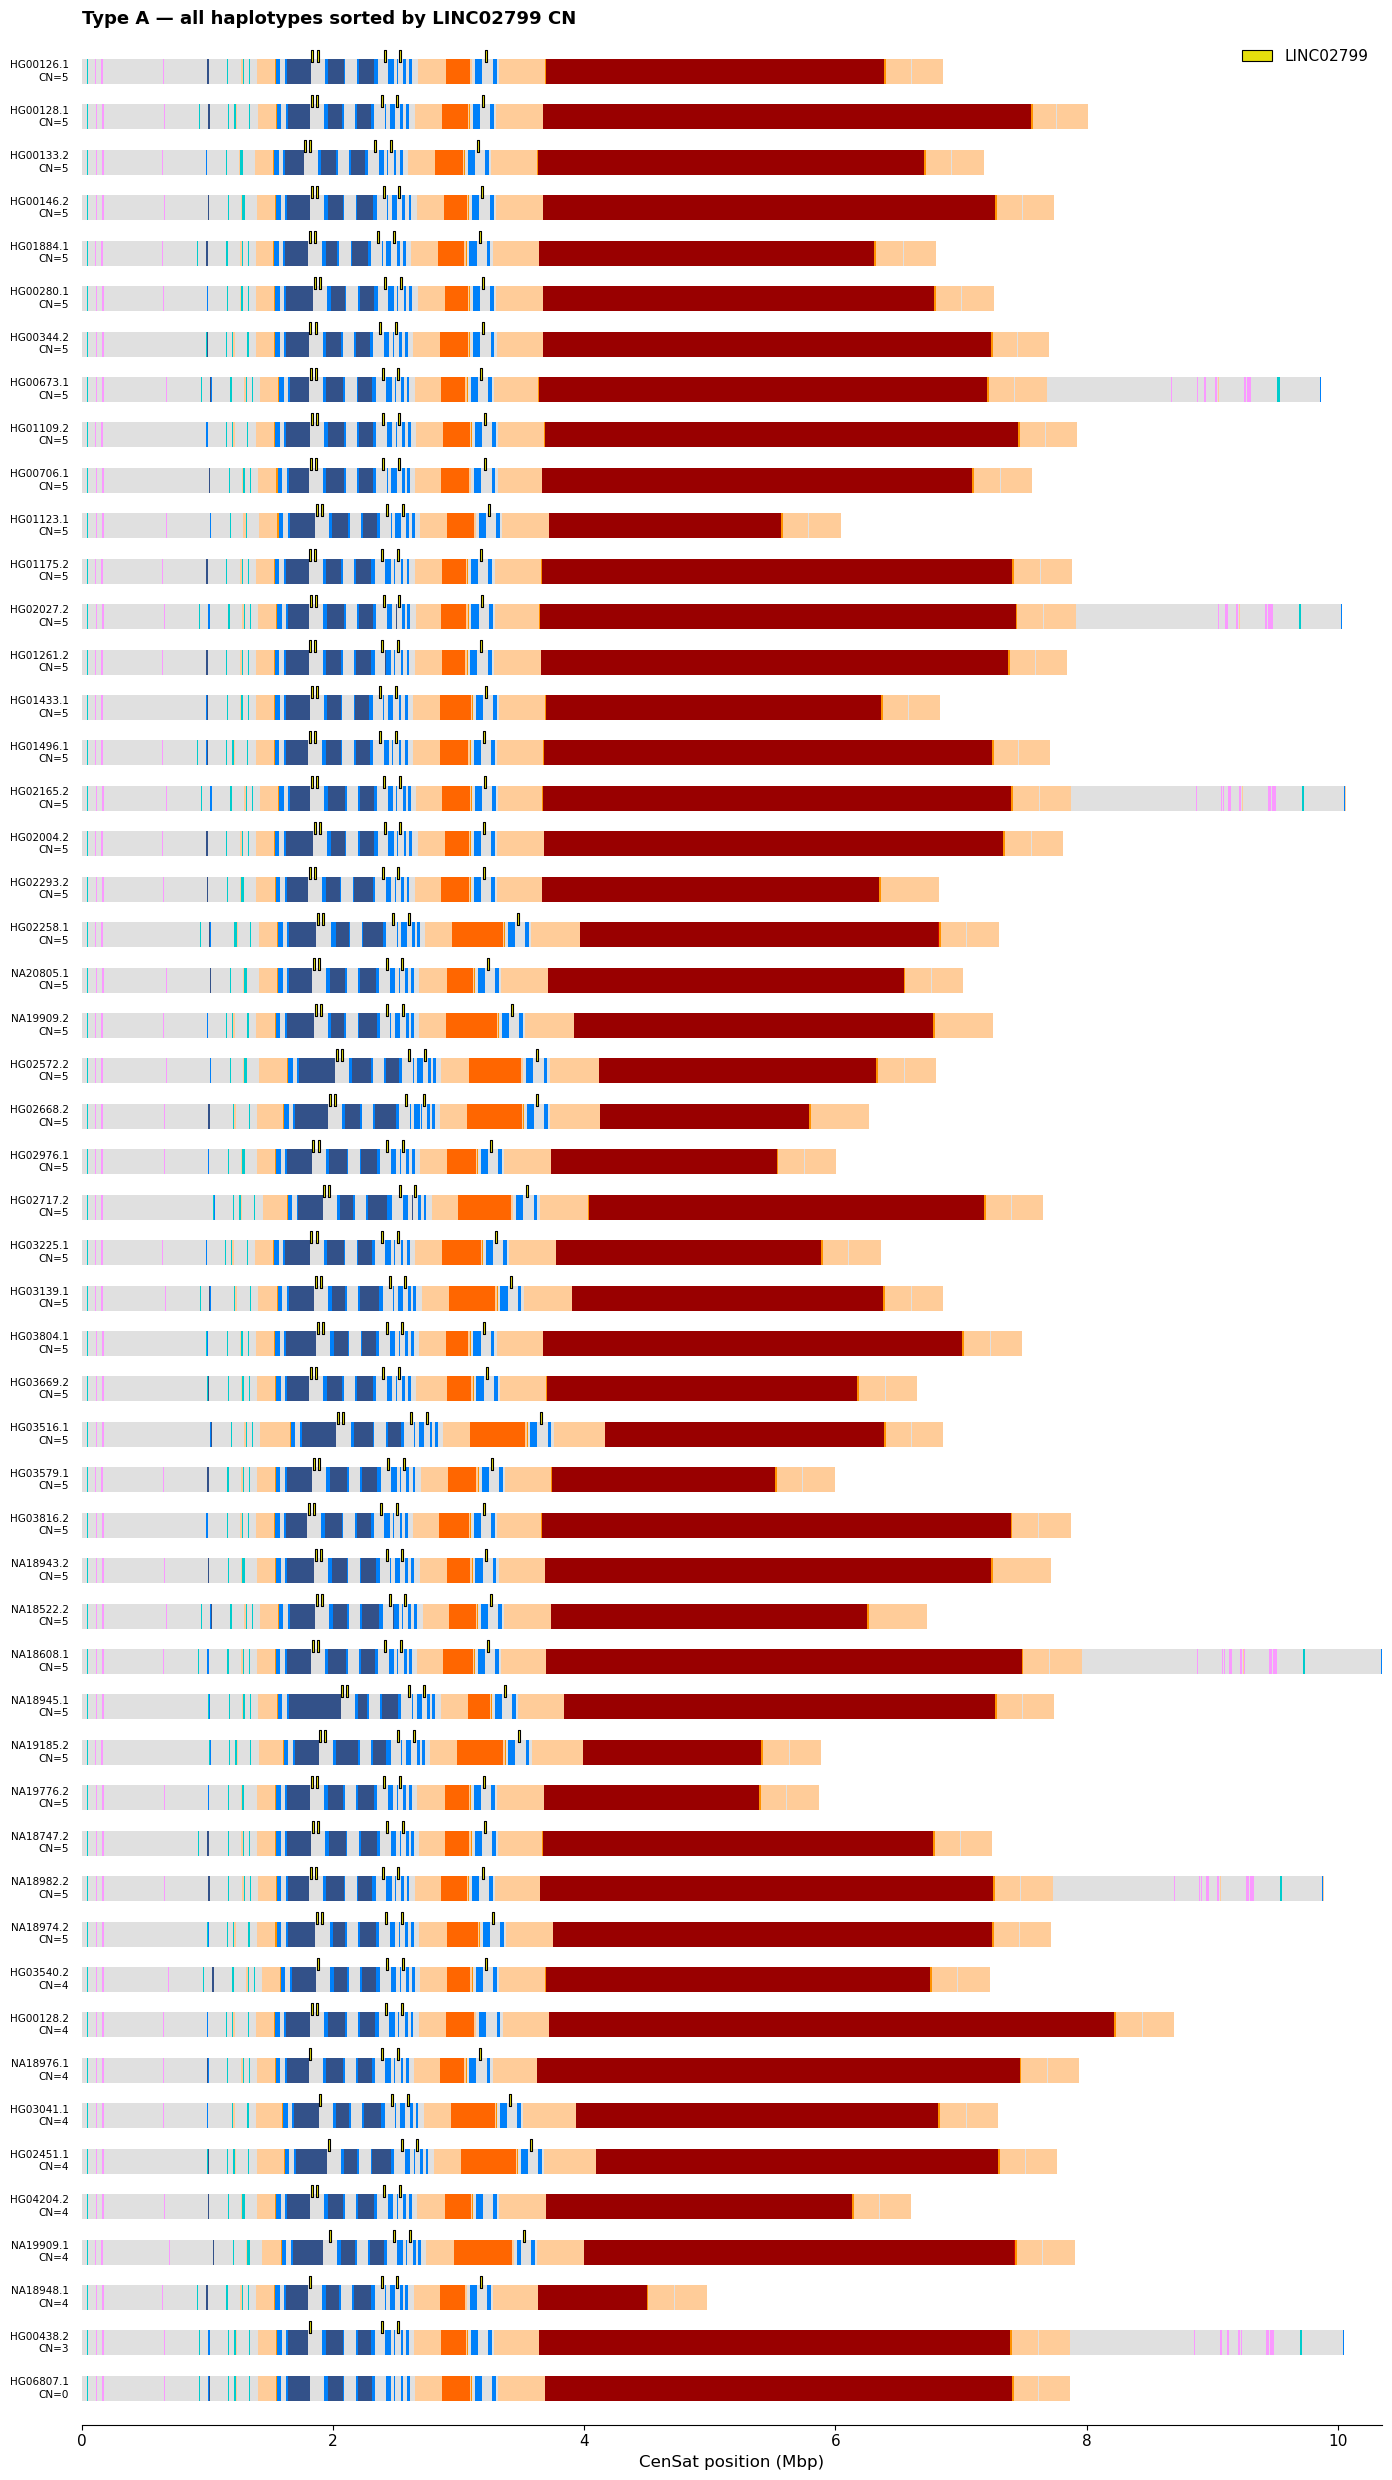

In [ ]:
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

CSAT_H  = 0.55
GENE_H  = 0.15
GENE_FOCUS = "#e6df0d"

verts = np.array([[-0.1, -0.5], [0.1, -0.5], [0.1, 0.5], [-0.1, 0.5], [-0.1, -0.5]])
tall_marker = mpath.Path(verts)

# all Type C haplotypes sorted by CN
type_c_df = plot_df[plot_df['Manual_Typing'] == 'Type A'].copy()
type_c_df = type_c_df.sort_values('cn', ascending=False).reset_index(drop=True)

# filter to those with valid region + bed
valid_rows = []
for _, row in type_c_df.iterrows():
    parts = row['sample_hap'].rsplit('.', 1)
    if len(parts) != 2: continue
    sid, hap = parts
    if region_idx.get((sid, hap)) is None: continue
    if bed_map.get((sid, hap)) is None: continue
    valid_rows.append(row)

type_c_df = pd.DataFrame(valid_rows).reset_index(drop=True)
n = len(type_c_df)

# max array size for Type C
max_size_mbp = 0
for _, row in type_c_df.iterrows():
    sid, hap = row['sample_hap'].rsplit('.', 1)
    region = region_idx.get((sid, hap))
    if region is None: continue
    max_size_mbp = max(max_size_mbp, (region['region_end'] - region['region_start']) / 1e6)

fig, ax = plt.subplots(figsize=(14, n * 0.45 + 1.5))

for yi, row in type_c_df.iterrows():
    sid, hap = row['sample_hap'].rsplit('.', 1)
    region = region_idx.get((sid, hap))
    rs = region['region_start']

    for seg in load_censat(sid, hap, region):
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], yi - CSAT_H/2), seg['end'] - seg['start'], CSAT_H,
            color=seg['color'], linewidth=0))

    genes = chr7_genes_df[(chr7_genes_df['sample_id'] == sid) &
                           (chr7_genes_df['haplotype'] == hap) &
                           (chr7_genes_df['gene_name'] == FOCUS_GENE)]
    for _, g in genes.iterrows():
        g_mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
        ax.scatter(g_mid, yi - CSAT_H/2 - GENE_H/2, marker=tall_marker, s=80,
                   color=GENE_FOCUS, edgecolors='black', linewidths=0.8, zorder=5, clip_on=False)

    ax.text(-0.1, yi, f"{row['sample_hap']}\nCN={row['cn']}",
            ha='right', va='center', fontsize=7.5, linespacing=1.3)

ax.set_xlim(0, max_size_mbp)
ax.set_ylim(-0.8, n - 0.2)
ax.invert_yaxis()
ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=11)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_title("Type A — all haplotypes sorted by LINC02799 CN", fontsize=13,
             fontweight='bold', loc='left', pad=8)
ax.legend(handles=[mpatches.Patch(facecolor=GENE_FOCUS, edgecolor='black',
          linewidth=0.8, label=FOCUS_GENE)],
          loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()

### filtering # of genes per haplotype further

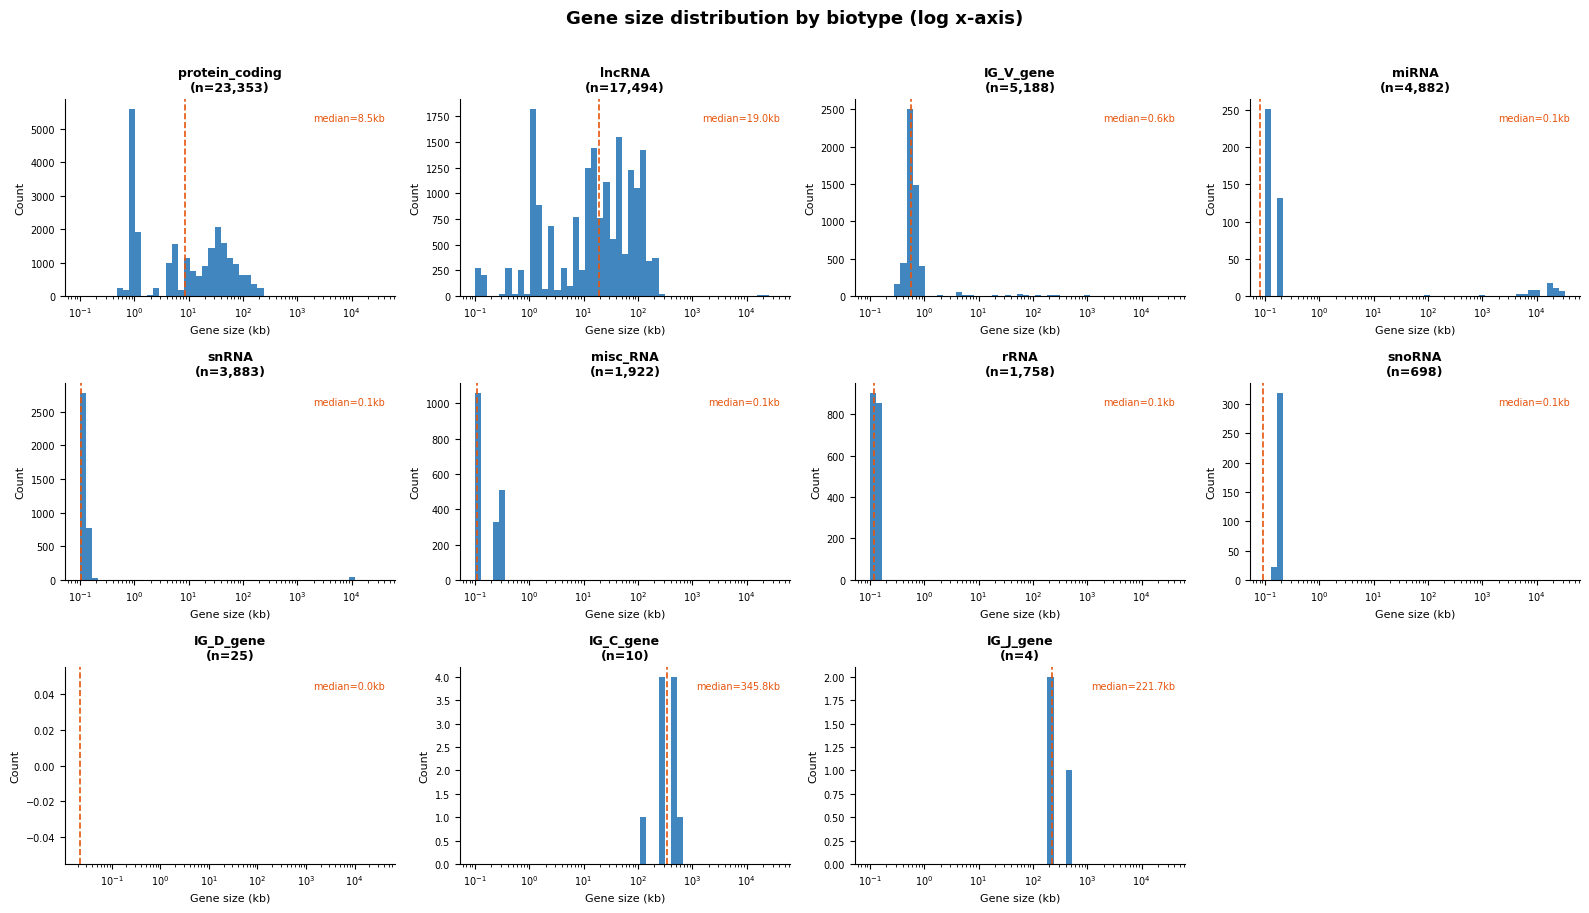

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

annot_filt["size_kb"] = (annot_filt["end"] - annot_filt["start"]) / 1e3

# get biotypes sorted by count descending
biotype_counts = annot_filt["gene_biotype"].value_counts()
biotypes = biotype_counts.index.tolist()

n = len(biotypes)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

bins = np.logspace(np.log10(0.1), np.log10(annot_filt["size_kb"].max() + 1), 50)

for i, btype in enumerate(biotypes):
    ax = axes[i]
    vals = annot_filt.loc[annot_filt["gene_biotype"] == btype, "size_kb"].dropna()
    ax.hist(vals, bins=bins, color="#2171b5", edgecolor="none", alpha=0.85)
    ax.set_xscale("log")
    ax.set_title(f"{btype}\n(n={len(vals):,})", fontsize=9, fontweight="bold")
    ax.set_xlabel("Gene size (kb)", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    med = vals.median()
    ax.axvline(med, color="#e6550d", lw=1.2, linestyle="--")
    ax.text(0.97, 0.93, f"median={med:.1f}kb", transform=ax.transAxes,
            ha="right", va="top", fontsize=7, color="#e6550d")

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Gene size distribution by biotype (log x-axis)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


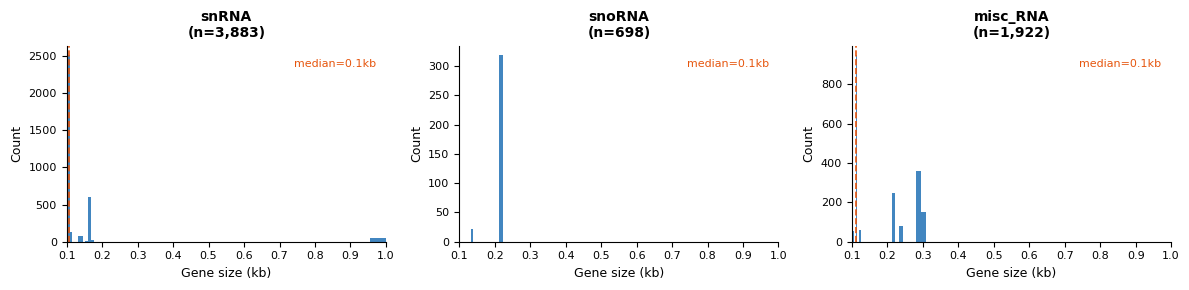

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

annot_filt["size_kb"] = (annot_filt["end"] - annot_filt["start"]) / 1e3

biotypes = ["snRNA", "snoRNA", "misc_RNA"]
bins = np.logspace(np.log10(0.1), np.log10(1), 50)


fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, btype in zip(axes, biotypes):
    vals = annot_filt.loc[annot_filt["gene_biotype"] == btype, "size_kb"].dropna()
    ax.hist(vals.clip(upper=1), bins=bins, color="#2171b5", edgecolor="none", alpha=0.85)
    ax.set_xlim(0.1, 1)
    ax.set_title(f"{btype}\n(n={len(vals):,})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Gene size (kb)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    med = vals.median()
    ax.axvline(med, color="#e6550d", lw=1.2, linestyle="--")
    ax.text(0.97, 0.93, f"median={med:.1f}kb", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#e6550d")

plt.tight_layout()
plt.show()

